# 🛰 Orbit Wars: Step-by-Step Rule-Based Agent Building

This notebook documents the process of learning Orbit Wars from scratch and building a solid (though not fully competitive) rule-based agent.

It is designed to be beginner-friendly, while also sharing practical ideas and experiments that may be useful for more advanced players.

---

#### Reusable Agent Dataset

The final agent and preset variants are also available as a reusable dataset.

It includes `funcs.py` and `presets.py`, allowing users to import preset agents or build custom rule-based agents with `make_ablation_agent`.

👉 [Orbit Wars Agents Dataset](https://www.kaggle.com/datasets/melccoro/orbit-wars-agents)

---

#### ⚠️ Disclaimer

Proper evaluation of the agent requires running a large number of simulations.  
However, this can significantly increase execution time during notebook publishing.

To keep execution time reasonable, **only a single game is executed in the code**,  
while results from **multiple runs are summarized in markdown**.


In [1]:
import os
import logging

os.environ["KAGGLE_ENVS_LOG_LEVEL"] = "ERROR"
logging.getLogger().setLevel(logging.ERROR)

import random
import numpy as np

random.seed(42)
np.random.seed(42)

from kaggle_environments import make
from kaggle_environments.envs.orbit_wars.orbit_wars import Planet
import matplotlib.pyplot as plt
import math
import pandas as pd
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 16.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_go
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_goofspiel
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_hearts
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_matching_pennies_3p
[kaggle_environments.envs.

---

## STEP 1 ― Nearest Planet Agent

We begin with a simple baseline agent that always attacks the nearest planet.

Although naive, it serves as a useful reference for comparing more advanced approaches.


### 1.1 ―  Helper Functions

To keep the agent logic clean and easy to understand,  
we define a few helper functions for common operations.

#### Functions

- **fleet_speed**: Calculates fleet travel speed based on ship count using a logarithmic scaling rule  
- **split_planets**: Separates planets into owned planets and potential target planets  
- **get_nearest_target**: Finds the closest target planet using Euclidean distance  
- **get_angle**: Computes the launch direction (angle) from source to target planet  

In [2]:
def fleet_speed(num_ships, max_speed=6.0):
    ratio = math.log(num_ships) / math.log(1000)
    ratio = max(0.0, ratio)
    return 1.0 + (max_speed - 1.0) * (ratio ** 1.5)

def split_planets(obs):
    player = obs["player"]
    planets = obs["planets"]

    my_planets = [p for p in planets if p[1] == player]
    targets = [p for p in planets if p[1] != player]

    return my_planets, targets

def get_nearest_target(mine, targets):
    return min(
        targets,
        key=lambda t: math.hypot(mine[2] - t[2], mine[3] - t[3])
    )

def get_angle(source, target):
    dx = target[2] - source[2]
    dy = target[3] - source[3]
    return math.atan2(dy, dx)

### 1.2 ―  Implementation

In [3]:
def nearest_agent(obs):
    moves = []

    my_planets, targets = split_planets(obs)

    if not my_planets or not targets:
        return moves

    for mine in my_planets:
        nearest = get_nearest_target(mine, targets)

        ships_needed = nearest[5] + 1

        if mine[5] >= ships_needed:
            angle = get_angle(mine, nearest)
            moves.append([mine[0], angle, ships_needed])

    return moves

### 1.3 ― Result Analysis Utilities

After running a match, we analyze the game using the helper functions to analyze **a single game in detail** (Hidden in cell below).

- **print_game_result**: Computes final scores (planets + fleets) and displays ranking and win/lose result  
- **plot_game_state**: Visualizes game progression over time, including planet counts, ship counts, and capture events  
    - capture tracking: Tracks how planets change ownership (neutral, enemy, or lost) at each step  
    - 2-player visualization: Shows planets, ships, and capture events in a single combined plot  
    - 4-player visualization: Separates capture events, planet counts, and ship counts into multiple plots for clarity

In [4]:
def print_game_result(env):
    final_obs = env.steps[-1][0].observation
    player = final_obs.player

    all_players = set()
    for step in env.steps:
        obs = step[0].observation
        for p in obs.planets:
            if p[1] != -1:
                all_players.add(p[1])
        for f in obs.fleets:
            if f[1] != -1:
                all_players.add(f[1])

    all_players = sorted(all_players)

    planets = [Planet(*p) for p in final_obs.planets]
    fleets = final_obs.fleets

    scores = {}

    for pid in all_players:
        planet_ships = sum(p.ships for p in planets if p.owner == pid)
        fleet_ships = sum(f[6] for f in fleets if f[1] == pid)
        scores[pid] = planet_ships + fleet_ships

    ranking = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    my_score = scores.get(player, 0)
    my_rank = [pid for pid, _ in ranking].index(player) + 1

    print("===== Game Result =====")
    print(f"My player ID: {player}")
    print(f"My score: {my_score}")
    print(f"My rank: {my_rank} / {len(all_players)}")

    print("Result:", "WIN" if my_rank == 1 else "LOSE")

    print("\nRanking:")
    for rank, (pid, score) in enumerate(ranking, start=1):
        marker = " <-- me" if pid == player else ""
        print(f"{rank}. Player {pid}: {score}{marker}")
        
def plot_game_state(env):
    steps = []

    my_neutral_capture_steps = []
    my_enemy_capture_steps = []
    enemy_neutral_capture_steps = []
    enemy_enemy_capture_steps = []
    lost_planet_steps = []

    prev_owners = None

    players = set()
    for step_idx in range(len(env.steps)):
        obs = env.steps[step_idx][0].observation
        for p in obs.planets:
            if p[1] != -1:
                players.add(p[1])

    players = sorted(players)
    is_multi = len(players) > 2

    for step_idx in range(1, len(env.steps)):
        obs = env.steps[step_idx][0].observation
        player = obs.player
        planets = [Planet(*p) for p in obs.planets]

        curr_owners = {p.id: p.owner for p in planets}

        my_neutral_captures = 0
        my_enemy_captures = 0
        enemy_neutral_captures = 0
        enemy_enemy_captures = 0
        lost_planets = 0

        if prev_owners is not None:
            for pid, curr_owner in curr_owners.items():
                prev_owner = prev_owners.get(pid)

                if prev_owner is None or prev_owner == curr_owner:
                    continue

                if curr_owner == player and prev_owner == -1:
                    my_neutral_captures += 1

                elif curr_owner == player and prev_owner not in (-1, player):
                    my_enemy_captures += 1

                elif prev_owner == player and curr_owner != player:
                    lost_planets += 1

                elif prev_owner == -1 and curr_owner not in (-1, player):
                    enemy_neutral_captures += 1

                elif (
                    prev_owner not in (-1, player)
                    and curr_owner not in (-1, player)
                    and prev_owner != curr_owner
                ):
                    enemy_enemy_captures += 1

        my_neutral_capture_steps.append(my_neutral_captures)
        my_enemy_capture_steps.append(my_enemy_captures)
        enemy_neutral_capture_steps.append(enemy_neutral_captures)
        enemy_enemy_capture_steps.append(enemy_enemy_captures)
        lost_planet_steps.append(lost_planets)

        prev_owners = curr_owners
        steps.append(step_idx)
        
    print_game_result(env)

    # =========================
    # 2-player plot
    # =========================
    if not is_multi:
        my_planets_list = []
        enemy_planets_list = []
        neutral_planets_list = []
        my_ships_list = []
        enemy_ships_list = []

        for step_idx in range(1, len(env.steps)):
            obs = env.steps[step_idx][0].observation
            player = obs.player
            planets = [Planet(*p) for p in obs.planets]

            my_planets = [p for p in planets if p.owner == player]
            enemy_planets = [p for p in planets if p.owner not in (-1, player)]
            neutral_planets = [p for p in planets if p.owner == -1]

            my_planets_list.append(len(my_planets))
            enemy_planets_list.append(len(enemy_planets))
            neutral_planets_list.append(len(neutral_planets))

            my_ships_list.append(sum(p.ships for p in my_planets))
            enemy_ships_list.append(sum(p.ships for p in enemy_planets))

        fig, ax1 = plt.subplots(figsize=(12, 5))

        line1, = ax1.plot(steps, my_planets_list, label="My planets")
        line2, = ax1.plot(steps, enemy_planets_list, label="Enemy planets")
        line3, = ax1.plot(steps, neutral_planets_list, label="Neutral planets")

        ax1.set_xlabel("Step")
        ax1.set_ylabel("Planet count")
        ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

        ax2 = ax1.twinx()
        line4, = ax2.plot(steps, my_ships_list, linestyle="--", label="My ships")
        line5, = ax2.plot(steps, enemy_ships_list, linestyle="--", label="Enemy ships")
        ax2.set_ylabel("Ships")

        ax3 = ax1.twinx()
        ax3.spines["right"].set_position(("outward", 60))

        bars = []
        bottom = [0] * len(steps)

        bar1 = ax3.bar(
            steps,
            my_neutral_capture_steps,
            bottom=bottom,
            alpha=0.35,
            width=1.0,
            label="My neutral captures",
            color="skyblue"
        )
        bars.append(bar1)
        bottom = [b + v for b, v in zip(bottom, my_neutral_capture_steps)]

        bar2 = ax3.bar(
            steps,
            my_enemy_capture_steps,
            bottom=bottom,
            alpha=0.35,
            width=1.0,
            label="My enemy captures",
            color="green"
        )
        bars.append(bar2)
        bottom = [b + v for b, v in zip(bottom, my_enemy_capture_steps)]

        bar3 = ax3.bar(
            steps,
            enemy_neutral_capture_steps,
            bottom=bottom,
            alpha=0.35,
            width=1.0,
            label="Enemy neutral captures",
            color="orange"
        )
        bars.append(bar3)
        bottom = [b + v for b, v in zip(bottom, enemy_neutral_capture_steps)]

        bar4 = ax3.bar(
            steps,
            lost_planet_steps,
            bottom=bottom,
            alpha=0.45,
            width=1.0,
            label="Lost planets",
            color="red"
        )
        bars.append(bar4)

        max_capture = max(
            [
                n + me + en + l
                for n, me, en, l in zip(
                    my_neutral_capture_steps,
                    my_enemy_capture_steps,
                    enemy_neutral_capture_steps,
                    lost_planet_steps
                )
            ],
            default=0
        )

        ax3.set_ylim(0, max_capture + 1)
        ax3.set_ylabel("Capture events")
        ax3.yaxis.set_major_locator(MaxNLocator(integer=True))

        lines = [line1, line2, line3, line4, line5] + bars
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc="upper left")

        plt.title("Game State and Capture Events Over Time")
        plt.show()

    # =========================
    # 4-player plots
    # =========================
    else:
        # 1. Capture Events
        fig, ax = plt.subplots(figsize=(12, 4))

        bottom = [0] * len(steps)

        ax.bar(
            steps,
            my_neutral_capture_steps,
            bottom=bottom,
            color="skyblue",
            alpha=0.4,
            width=1.0,
            label="My neutral captures"
        )
        bottom = [b + v for b, v in zip(bottom, my_neutral_capture_steps)]

        ax.bar(
            steps,
            my_enemy_capture_steps,
            bottom=bottom,
            color="green",
            alpha=0.4,
            width=1.0,
            label="My enemy captures"
        )
        bottom = [b + v for b, v in zip(bottom, my_enemy_capture_steps)]

        ax.bar(
            steps,
            enemy_neutral_capture_steps,
            bottom=bottom,
            color="orange",
            alpha=0.4,
            width=1.0,
            label="Enemy neutral captures"
        )
        bottom = [b + v for b, v in zip(bottom, enemy_neutral_capture_steps)]

        if any(v > 0 for v in enemy_enemy_capture_steps):
            ax.bar(
                steps,
                enemy_enemy_capture_steps,
                bottom=bottom,
                color="purple",
                alpha=0.4,
                width=1.0,
                label="Enemy enemy captures"
            )
            bottom = [b + v for b, v in zip(bottom, enemy_enemy_capture_steps)]

        ax.bar(
            steps,
            lost_planet_steps,
            bottom=bottom,
            color="red",
            alpha=0.5,
            width=1.0,
            label="Lost planets"
        )

        max_capture = max(
            [
                n + me + en + ee + l
                for n, me, en, ee, l in zip(
                    my_neutral_capture_steps,
                    my_enemy_capture_steps,
                    enemy_neutral_capture_steps,
                    enemy_enemy_capture_steps,
                    lost_planet_steps
                )
            ],
            default=0
        )

        ax.set_ylim(0, max_capture + 1)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))

        ax.set_title("Capture Events Over Time")
        ax.set_xlabel("Step")
        ax.set_ylabel("Capture events")
        ax.legend(loc="upper left")
        plt.show()

        # 2. Planet Count by Player + Neutral
        player_planets = {pid: [] for pid in players}
        neutral_planets_by_step = []

        for step_idx in range(1, len(env.steps)):
            obs = env.steps[step_idx][0].observation
            planets = [Planet(*p) for p in obs.planets]

            neutral_planets_by_step.append(
                len([p for p in planets if p.owner == -1])
            )

            for pid in players:
                owned = [p for p in planets if p.owner == pid]
                player_planets[pid].append(len(owned))

        fig, ax = plt.subplots(figsize=(12, 5))

        for pid in players:
            ax.plot(steps, player_planets[pid], label=f"Player {pid}")

        ax.plot(
            steps,
            neutral_planets_by_step,
            linestyle="--",
            label="Neutral"
        )

        ax.set_title("Planet Count by Player + Neutral")
        ax.set_xlabel("Step")
        ax.set_ylabel("Planet count")
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.legend()
        plt.show()

        # 3. Ship Count by Player
        player_ships = {pid: [] for pid in players}

        for step_idx in range(1, len(env.steps)):
            obs = env.steps[step_idx][0].observation
            planets = [Planet(*p) for p in obs.planets]

            for pid in players:
                owned = [p for p in planets if p.owner == pid]
                player_ships[pid].append(sum(p.ships for p in owned))

        fig, ax = plt.subplots(figsize=(12, 5))

        for pid in players:
            ax.plot(
                steps,
                player_ships[pid],
                linestyle="--",
                label=f"Player {pid}"
            )

        ax.set_title("Ship Count by Player")
        ax.set_xlabel("Step")
        ax.set_ylabel("Ships")
        ax.legend()
        
        plt.show()
    

### 1.4 ― Execute the Environment

#### 2-player


===== Game Result =====
My player ID: 0
My score: 2213
My rank: 1 / 2
Result: WIN

Ranking:
1. Player 0: 2213 <-- me
2. Player 1: 0


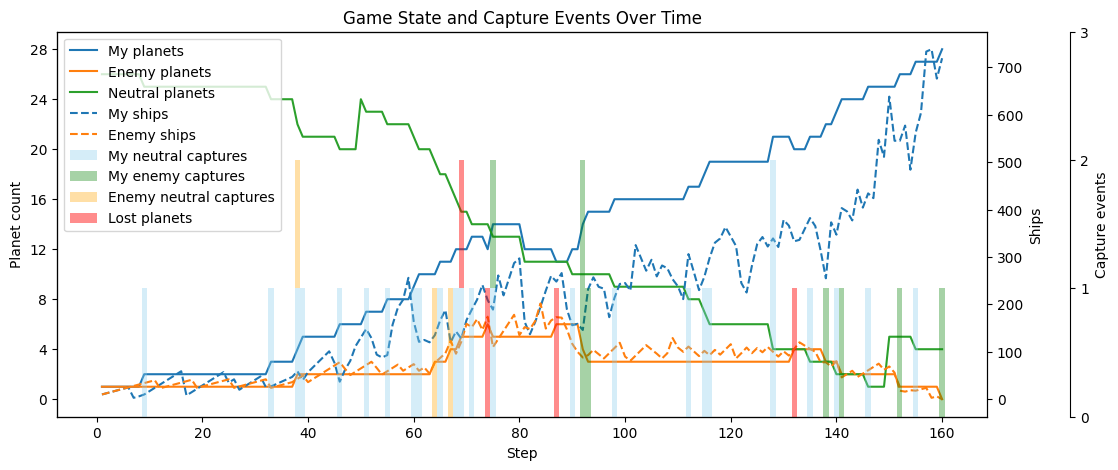

In [5]:
env = make("orbit_wars", debug=True, configuration={"seed": 42})
env.run([nearest_agent, "random"])
plot_game_state(env)

#### 4-player

===== Game Result =====
My player ID: 0
My score: 525
My rank: 1 / 4
Result: WIN

Ranking:
1. Player 0: 525 <-- me
2. Player 2: 323
3. Player 3: 262
4. Player 1: 255


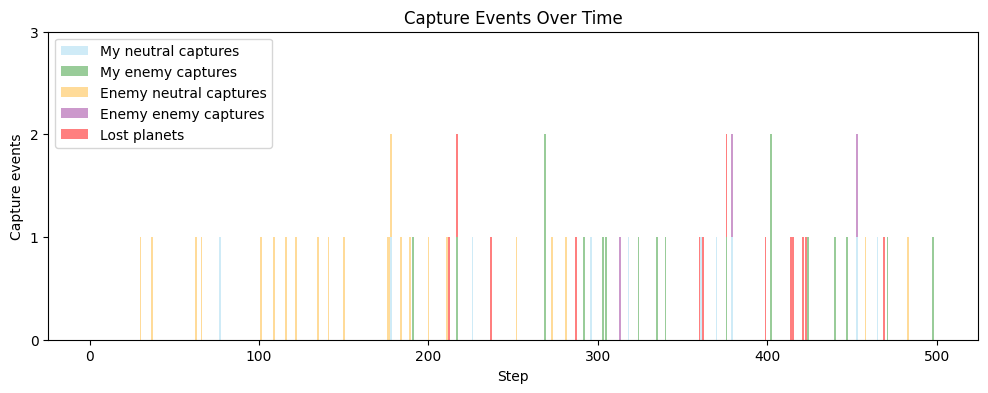

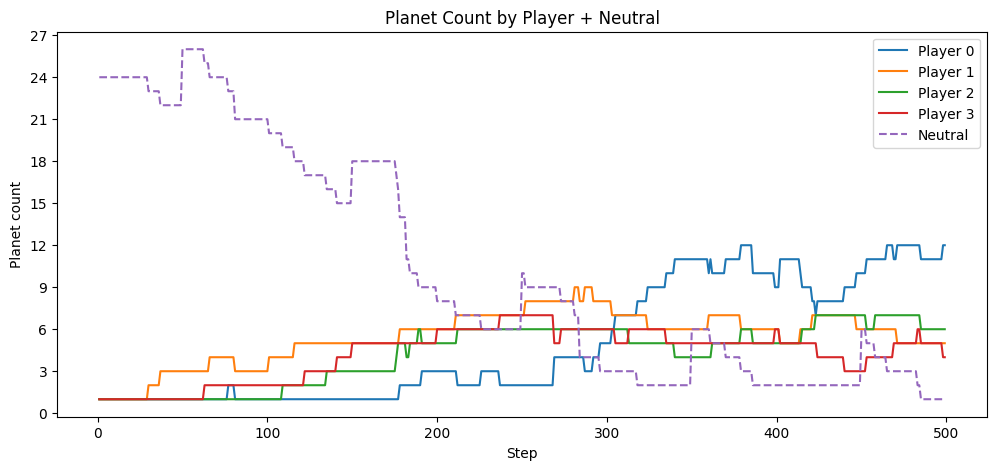

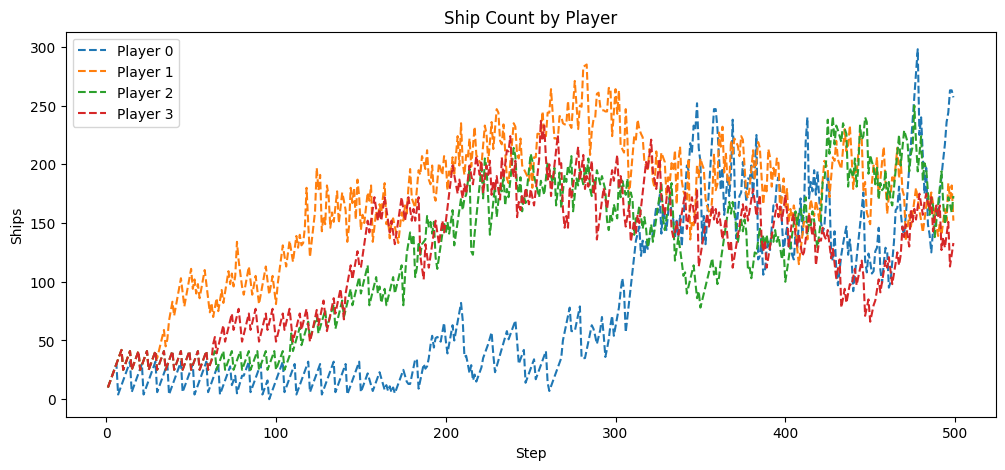

In [6]:
env = make("orbit_wars", debug=True, configuration={"seed": 42})
env.run([nearest_agent, "random","random","random"])
plot_game_state(env)

---

## STEP 2 ― In-Flight Fleets Agent

The nearest agent does not consider friendly fleets already heading toward a target.

To reduce redundant attacks, we should inspect `obs["fleets"]`   
and check whether our ships are already heading toward a target.

`obs["fleets"]` does not directly tell us the target planet.

Instead, we estimate the likely target by comparing:

- the fleet's current movement angle
- the angle from the fleet's current position to each planet

If the angle difference is small, the fleet is probably heading toward that planet.

The `use_capture_filter` option is included for later ablation experiments.  
In this step, it is set to `False` to keep the behavior simple.

#### Functions

- `get_reserved_targets`: Identify planets already targeted by in-flight fleets using trajectory alignment.  

In [7]:
def get_reserved_targets(
    obs,
    angle_threshold=0.1,
    use_capture_filter=False
):

    planets = obs["planets"]
    fleets = obs["fleets"]
    player = obs["player"]

    reserved_targets = set()

    # Extract only our fleets
    my_fleets = [f for f in fleets if f[1] == player]

    for f in my_fleets:
        fx, fy = f[2], f[3]      # fleet position
        angle = f[4]             # fleet travel direction

        best_planet = None
        best_angle_diff = float("inf")

        # Try to infer which planet this fleet is heading toward
        for p in planets:

            # Skip origin planet (fleet just launched from here)
            if p[0] == f[5]:
                continue

            dx = p[2] - fx
            dy = p[3] - fy

            # Angle from fleet to this planet
            target_angle = math.atan2(dy, dx)

            # Angle difference normalized to [-pi, pi] (wrap-around safe)
            diff = abs(math.atan2(
                math.sin(target_angle - angle),
                math.cos(target_angle - angle)
            ))

            # Keep the closest match in angle space
            if diff < best_angle_diff:
                best_angle_diff = diff
                best_planet = p

        # If no candidate found, skip
        if best_planet is None:
            continue

        # If angle mismatch is too large, ignore (not likely the target)
        if best_angle_diff >= angle_threshold:
            continue

        # Optional: ignore fleets that cannot actually capture the planet
        if use_capture_filter and f[6] <= best_planet[5]:
            continue

        # Mark this planet as already targeted
        reserved_targets.add(best_planet[0])

    return reserved_targets

In [8]:
def in_flight_agent(obs):
    moves = []

    my_planets, targets = split_planets(obs)
    
    # If nothing to act on, do nothing
    if not my_planets or not targets:
        return moves

    reserved_targets = get_reserved_targets(obs)

    for mine in my_planets:

        # Exclude targets that are already being attacked
        available_targets = [
            t for t in targets if t[0] not in reserved_targets
        ]

        # If no valid targets remain, skip this planet
        if not available_targets:
            continue

        nearest = get_nearest_target(mine, available_targets)

        ships_needed = nearest[5] + 1

        # Only launch if we have enough ships
        if mine[5] >= ships_needed:
            angle = get_angle(mine, nearest)
            # Launch fleet
            moves.append([mine[0], angle, ships_needed])
            reserved_targets.add(nearest[0])

    return moves

#### 2-player

===== Game Result =====
My player ID: 0
My score: 11375
My rank: 1 / 2
Result: WIN

Ranking:
1. Player 0: 11375 <-- me
2. Player 1: 0


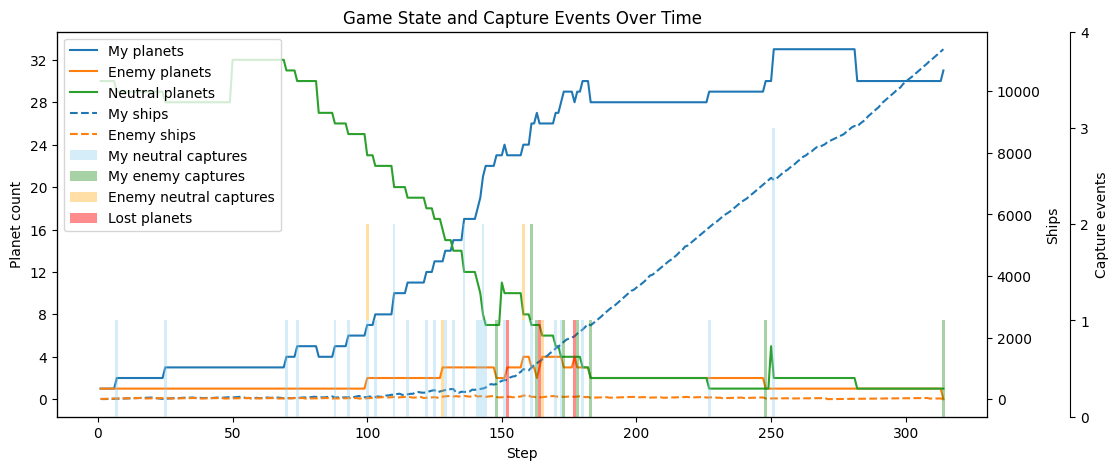

In [9]:
env = make("orbit_wars", debug=True, configuration={"seed": 42})
env.run([in_flight_agent, "random"])

plot_game_state(env)

#### 4-player

===== Game Result =====
My player ID: 0
My score: 14394
My rank: 1 / 4
Result: WIN

Ranking:
1. Player 0: 14394 <-- me
2. Player 1: 0
3. Player 2: 0
4. Player 3: 0


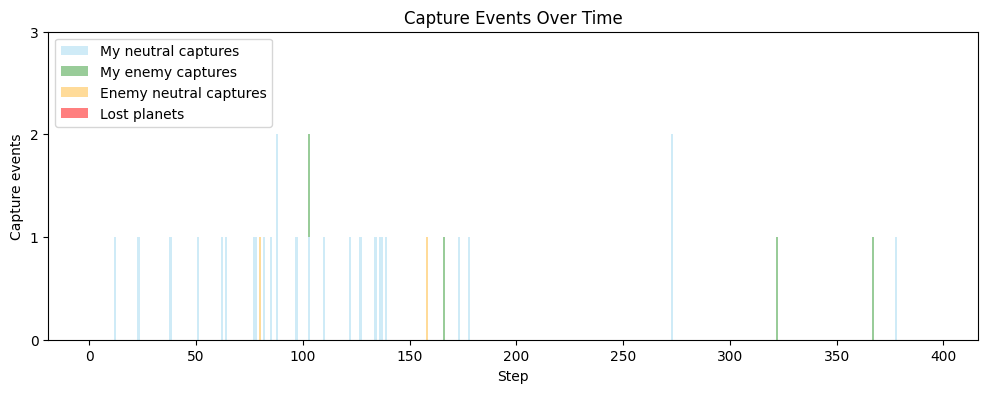

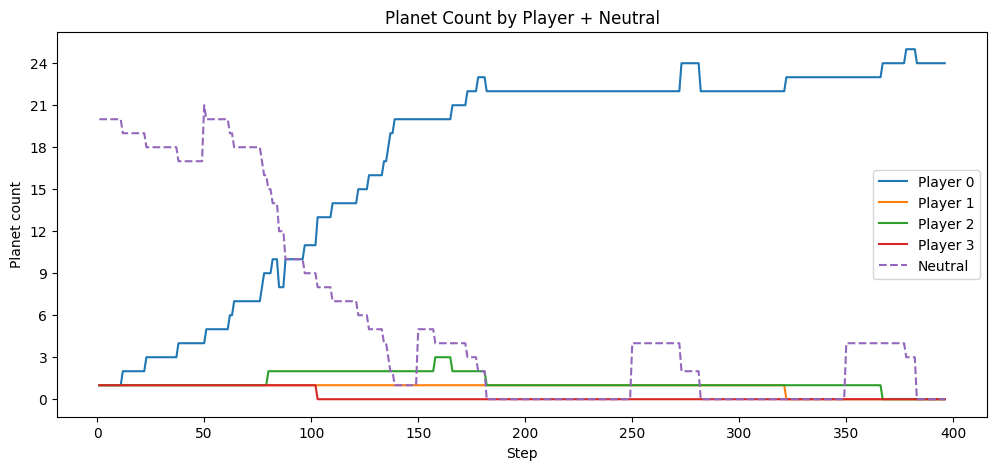

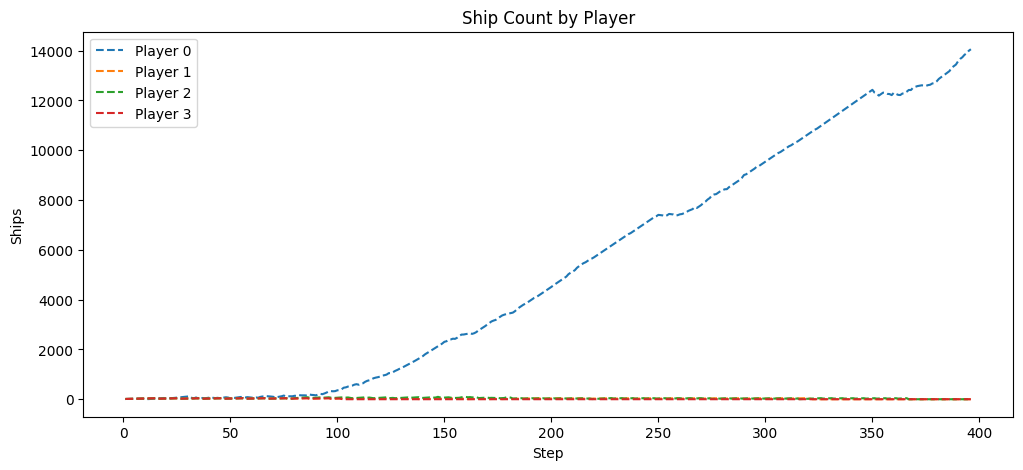

In [10]:
env = make("orbit_wars", debug=True, configuration={"seed": 42})
env.run([in_flight_agent, "random", "random", "random"])

plot_game_state(env)

---

## STEP 3 ― Evaluation

To evaluate the performance of our agents,   
we run **multiple matches with different random seeds**.

This allows us to obtain a more reliable estimate of performance,
instead of relying on the outcome of a single game.

As a rough guideline, around 100 games are needed to obtain a reasonably stable estimate of the win rate  
(e.g., within ±10% under a 90–95% confidence level).

If you want to see the calculation, open the hidden cell below.

### Statistical Details: Sample Size Estimation

Each game outcome can be viewed as a Bernoulli trial (win or loss).  
By repeating the game multiple times, the number of wins follows a binomial distribution.

$$
X \sim \mathrm{Binomial}(n, p)
$$

The observed win rate is given by:

$$
\hat{p} = \frac{X}{n}
$$

The standard error of the estimate is:

$$
\sqrt{\frac{p(1 - p)}{n}}
$$

Using the normal approximation, a 95% confidence interval for the win rate is:

$$
\hat{p} \pm 1.96 \cdot \sqrt{\frac{\hat{p}(1 - \hat{p})}{n}}
$$

To estimate the win rate within a desired error margin ($\pm \varepsilon$), we can rearrange the formula:

$$
n \approx p(1 - p) \left(\frac{1.96}{\varepsilon}\right)^2
$$

| Error (±ε) | Required Games (n) |
|-----------|-------------------|
| ±20%      | ~25               |
| ±15%      | ~43               |
| ±10%      | ~96               |
| ±5%       | ~385              |

- 10 games → quick experiments (high variance)
- 30–50 games → rough comparison
- 50–100 games → reliable evaluation
- 300+ games → strong statistical confidence

In multi-player settings, we simplify the outcome by focusing only on whether the agent wins (rank = 1).

Note that this ignores finer distinctions between ranks, so additional metrics such as average rank are also useful.

#### Helper Functions (Hidden in Cell Below)

- `total_ships`: Compute total ships (planets + fleets) for a player  
- `extract_game_timeseries`: Extract per-step game metrics for analysis  
- `plot_average_game_state`: Visualize average planet/ship trends over time  
- `summarize_results`: Summarize evaluation metrics (win rate, rank, margin)  
- `plot_average_capture_events`: Visualize capture dynamics over time
- `evaluate_agents`: Run randomized 2-player or 4-player matches, then collect final rankings, ship margins, and time-series metrics.

In [11]:
# Sum ships on owned planets and fleets
def total_ships(obs, player_id):

    planets = obs["planets"]
    fleets = obs["fleets"]

    planet_ships = sum(p[5] for p in planets if p[1] == player_id)
    fleet_ships = sum(f[6] for f in fleets if f[1] == player_id)

    return planet_ships + fleet_ships
    
# Extract per-step game metrics for analysis    
def extract_game_timeseries(env, my_position):
    rows = []
    prev_owners = None

    # Iterate through each game step
    for step_idx in range(1, len(env.steps)):
        obs = env.steps[step_idx][my_position].observation
        player = obs.player
        planets = obs.planets

        # Current owner of each planet
        curr_owners = {p[0]: p[1] for p in planets}

        # Capture event counters for this step
        my_neutral_captures = 0
        my_enemy_captures = 0
        enemy_neutral_captures = 0
        enemy_enemy_captures = 0
        lost_planets = 0

        # Compare current owners with previous step owners
        if prev_owners is not None:
            for planet_id, curr_owner in curr_owners.items():
                prev_owner = prev_owners.get(planet_id)

                # Skip if ownership did not change
                if prev_owner is None or prev_owner == curr_owner:
                    continue

                # I captured a neutral planet
                if curr_owner == player and prev_owner == -1:
                    my_neutral_captures += 1

                # I captured an enemy planet
                elif curr_owner == player and prev_owner not in (-1, player):
                    my_enemy_captures += 1

                # I lost one of my planets
                elif prev_owner == player and curr_owner != player:
                    lost_planets += 1

                # An opponent captured a neutral planet
                elif prev_owner == -1 and curr_owner not in (-1, player):
                    enemy_neutral_captures += 1

                # One opponent captured another opponent's planet
                elif (
                    prev_owner not in (-1, player)
                    and curr_owner not in (-1, player)
                    and prev_owner != curr_owner
                ):
                    enemy_enemy_captures += 1

        # Basic planet counts
        my_planets = [p for p in planets if p[1] == player]
        neutral_planets = [p for p in planets if p[1] == -1]

        ships_by_player = {}
        planet_count_by_player = {}

        # Count ships and planets for each non-neutral player
        for p in planets:
            pid = p[1]
            if pid == -1:
                continue

            ships_by_player[pid] = ships_by_player.get(pid, 0) + p[5]
            planet_count_by_player[pid] = planet_count_by_player.get(pid, 0) + 1

        # Compare against the strongest opponent, not the average opponent
        enemy_players = [pid for pid in ships_by_player if pid != player]

        if enemy_players:
            best_enemy_ships = max(ships_by_player[pid] for pid in enemy_players)
            best_enemy_planets = max(planet_count_by_player[pid] for pid in enemy_players)
        else:
            best_enemy_ships = 0
            best_enemy_planets = 0

        # Store metrics for this step
        rows.append({
            "step": step_idx,

            "my_planets": len(my_planets),
            "best_enemy_planets": best_enemy_planets,
            "neutral_planets": len(neutral_planets),

            "my_ships": sum(p[5] for p in my_planets),
            "best_enemy_ships": best_enemy_ships,

            "my_neutral_captures": my_neutral_captures,
            "my_enemy_captures": my_enemy_captures,
            "enemy_neutral_captures": enemy_neutral_captures,
            "enemy_enemy_captures": enemy_enemy_captures,
            "lost_planets": lost_planets,
        })

        # Save current ownership for next-step comparison
        prev_owners = curr_owners

    return rows
    
# Plot average planets and ships over time (win vs loss)
def plot_average_game_state(timeseries_df):
    for result_label, flag in [("Winning Games", True), ("Losing Games", False)]:
        df_part = timeseries_df[timeseries_df["my_won"] == flag]

        if len(df_part) == 0:
            continue

        avg_df = df_part.groupby("step", as_index=False).mean(numeric_only=True)

        fig, ax1 = plt.subplots(figsize=(12, 5))

        ax1.plot(avg_df["step"], avg_df["my_planets"], label="My planets")
        ax1.plot(avg_df["step"], avg_df["best_enemy_planets"], label="Best opponent")
        ax1.plot(avg_df["step"], avg_df["neutral_planets"], label="Neutral")

        ax1.set_xlabel("Step")
        ax1.set_ylabel("Planet count")

        ax2 = ax1.twinx()
        ax2.plot(avg_df["step"], avg_df["my_ships"], linestyle="--", label="My ships")
        ax2.plot(avg_df["step"], avg_df["best_enemy_ships"], linestyle="--", label="Best opponent ships")

        ax2.set_ylabel("Ships")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

        plt.title(f"Average Game State — {result_label} (Best Opponent)")
        plt.grid(True)
        plt.show()

# Print summary statistics and optionally plot ship margins
def summarize_results(results, plot=True):
    df = pd.DataFrame(results)

    n_games = len(df)

    wins = df["my_won"].sum()
    draws = (df["winner"] == -1).sum()
    losses = n_games - wins - draws

    print("games:", n_games)
    print("wins:", wins)
    print("losses:", losses)
    print("draws:", draws)
    print("win rate:", wins / n_games)
    print("avg rank:", df["my_rank"].mean())
    print("avg total ships:", df["my_total_ships"].mean())
    print("avg best other ships:", df["best_other_ships"].mean())
    print("avg ship margin vs best other:", df["ship_margin_vs_best_other"].mean())
    print("avg final turns:", df["final_turns"].mean())

    if plot:
        plt.figure(figsize=(8, 4))
        plt.bar(range(n_games), df["ship_margin_vs_best_other"])
        plt.axhline(0, linestyle="--")
        plt.xlabel("Game")
        plt.ylabel("Ship margin")
        plt.title("Ship Margin vs Best Opponent")
        plt.grid(True)
        plt.show()

    return df

# Visualize capture events over time (stacked bar)
def plot_average_capture_events(timeseries_df, step_range=None):
    df = timeseries_df.copy()

    if step_range is not None:
        start, end = step_range
        df = df[(df["step"] >= start) & (df["step"] <= end)]

    for result_label, flag in [("Winning Games", True), ("Losing Games", False)]:
        df_part = df[df["my_won"] == flag]

        if len(df_part) == 0:
            print(f"No {result_label.lower()} found.")
            continue

        avg_df = (
            df_part
            .groupby("step", as_index=False)
            .mean(numeric_only=True)
        )

        fig, ax = plt.subplots(figsize=(12, 4))

        bottom = np.zeros(len(avg_df))

        cols = [
            ("my_neutral_captures", "My neutral captures"),
            ("my_enemy_captures", "My enemy captures"),
            ("enemy_neutral_captures", "Enemy neutral captures"),
            ("enemy_enemy_captures", "Enemy enemy captures"),
            ("lost_planets", "Lost planets"),
        ]

        for col, label in cols:
            ax.bar(
                avg_df["step"],
                avg_df[col],
                bottom=bottom,
                alpha=0.4,
                width=1.0,
                label=label
            )
            bottom += avg_df[col].values

        ax.set_title(f"Average Capture Events — {result_label}")
        ax.set_xlabel("Step")
        ax.set_ylabel("Average capture events")
        ax.legend(loc="upper left")
        plt.show()

def evaluate_agents(agents, my_agent, seeds=range(20)):
    results = []
    timeseries_rows = []

    n_players = len(agents)

    if n_players not in [2, 4]:
        raise ValueError("Number of agents must be 2 or 4")

    for seed in seeds:
        lineup = list(agents)
        random.Random(seed).shuffle(lineup)

        my_position = lineup.index(my_agent)

        env = make(
            "orbit_wars",
            debug=False,
            configuration={"seed": seed}
        )
        env.run(lineup)

        final_states = env.steps[-1]
        final_turns = len(env.steps)

        total_ships_list = []

        for player_id in range(n_players):
            obs = final_states[player_id].observation
            total_ships_list.append(total_ships(obs, player_id))

        max_ships = max(total_ships_list)
        winners = [
            player_id
            for player_id, ships in enumerate(total_ships_list)
            if ships == max_ships
        ]

        winner = winners[0] if len(winners) == 1 else -1

        my_total = total_ships_list[my_position]
        best_other = max(
            ships
            for player_id, ships in enumerate(total_ships_list)
            if player_id != my_position
        )

        sorted_ships = sorted(total_ships_list, reverse=True)
        my_rank = sorted_ships.index(my_total) + 1
        my_won = winner == my_position

        result = {
            "seed": seed,
            "my_position": my_position,
            "my_won": my_won,
            "my_rank": my_rank,
            "winner": winner,
            "my_total_ships": my_total,
            "best_other_ships": best_other,
            "ship_margin_vs_best_other": my_total - best_other,
            "final_turns": final_turns,
        }

        for player_id, ships in enumerate(total_ships_list):
            result[f"total_ships_{player_id}"] = ships

        results.append(result)

        game_ts = extract_game_timeseries(env, my_position)

        for row in game_ts:
            row["seed"] = seed
            row["my_won"] = my_won
            row["my_rank"] = my_rank

        timeseries_rows.extend(game_ts)

    return pd.DataFrame(results), pd.DataFrame(timeseries_rows)
    

games: 20
wins: 19
losses: 1
draws: 0
win rate: 0.95
avg rank: 1.05
avg total ships: 14176.85
avg best other ships: 80.65
avg ship margin vs best other: 14096.2
avg final turns: 382.2


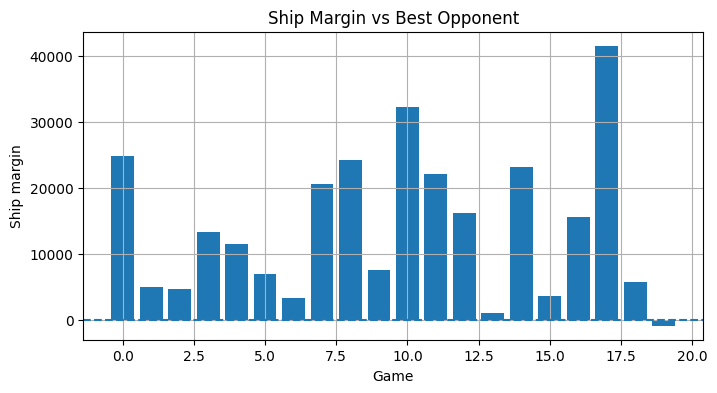

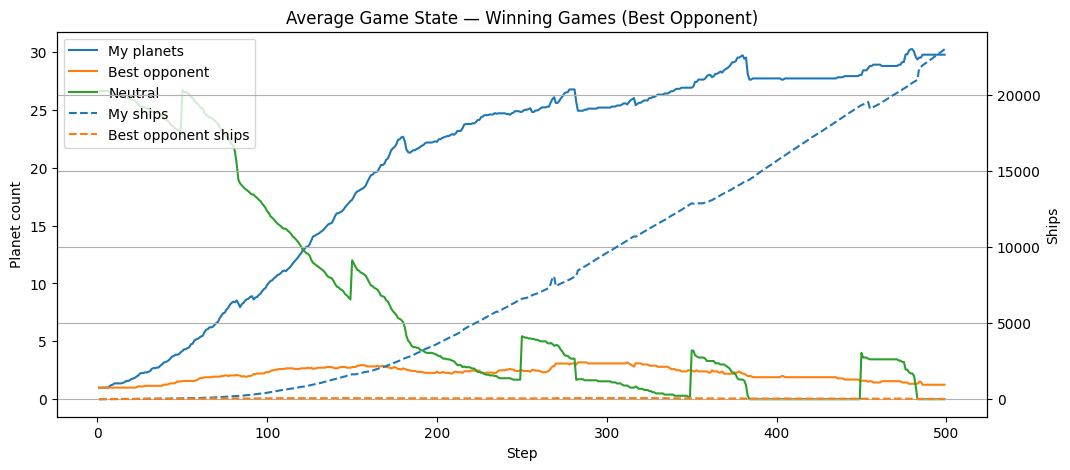

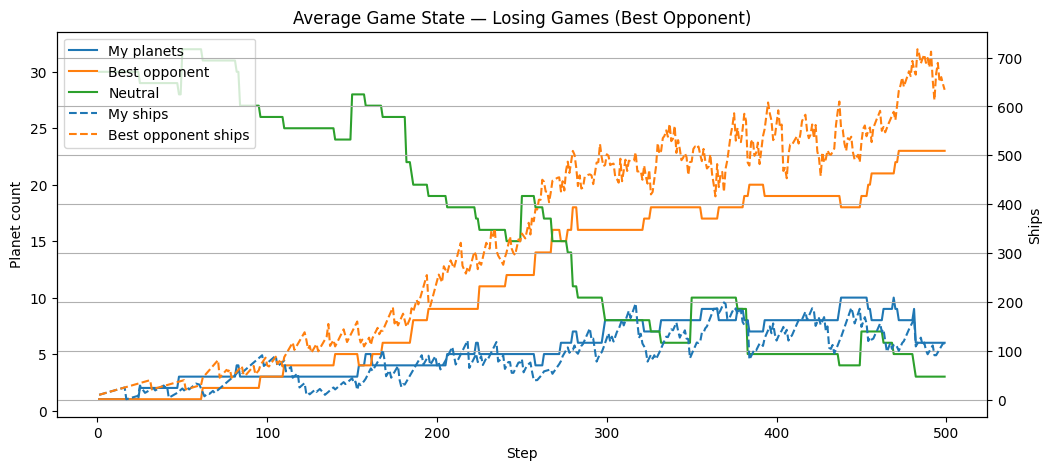

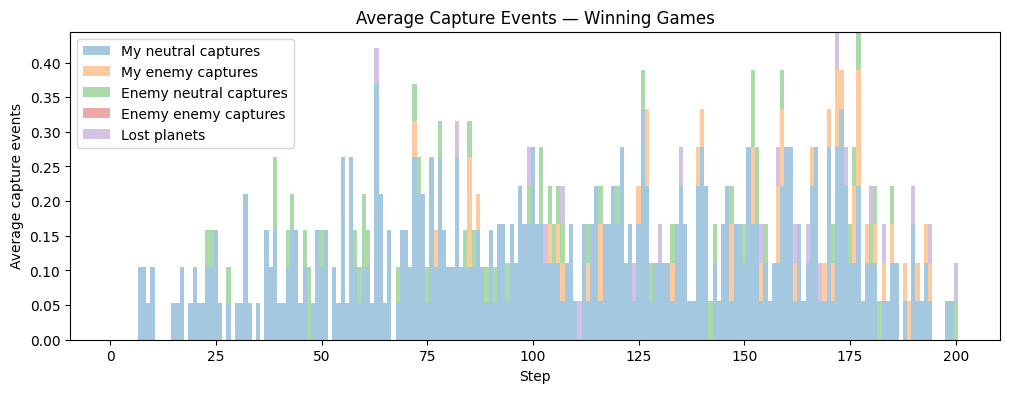

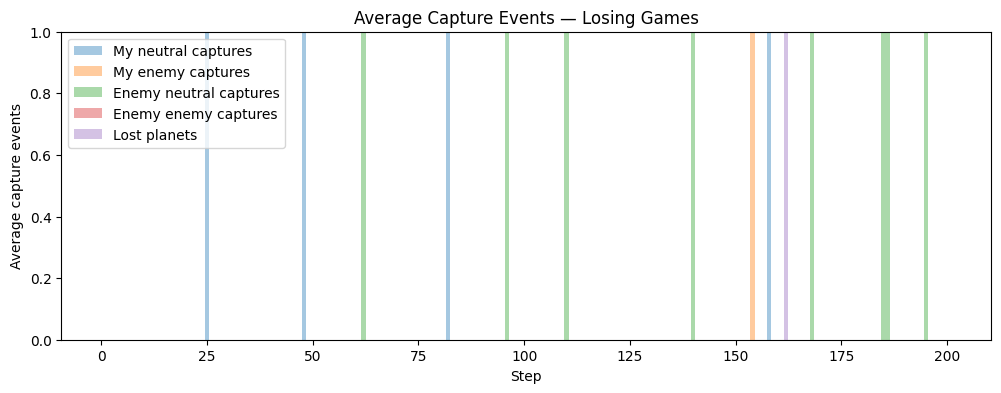

In [12]:
results_2p, ts_2p = evaluate_agents(
    agents=[in_flight_agent, "random"],
    my_agent=in_flight_agent,
    seeds=range(20)
)

df_2p = summarize_results(results_2p)
plot_average_game_state(ts_2p)
plot_average_capture_events(ts_2p, step_range=(0, 200))

games: 20
wins: 15
losses: 5
draws: 0
win rate: 0.75
avg rank: 1.65
avg total ships: 10724.25
avg best other ships: 397.2
avg ship margin vs best other: 10327.05
avg final turns: 410.05

=== Best Games ===


,seed,my_position,my_won,my_rank,winner,my_total_ships,best_other_ships,ship_margin_vs_best_other,final_turns,total_ships_0,total_ships_1,total_ships_2,total_ships_3
2,2,3,True,1,3,21842,0,21842,392,0,0,0,21842
4,4,1,True,1,1,21767,41,21726,500,0,21767,0,41
17,17,0,True,1,0,19965,0,19965,405,19965,0,0,0
18,18,2,True,1,2,17989,0,17989,389,0,0,17989,0
3,3,1,True,1,1,16660,0,16660,339,0,16660,0,0



=== Worst Games ===


,seed,my_position,my_won,my_rank,winner,my_total_ships,best_other_ships,ship_margin_vs_best_other,final_turns,total_ships_0,total_ships_1,total_ships_2,total_ships_3
5,5,0,False,2,3,0,2221,-2221,433,0,0,0,2221
10,10,3,False,4,1,0,2115,-2115,500,56,2115,166,0
13,13,1,False,4,2,0,1539,-1539,500,81,0,1539,108
7,7,2,False,4,0,0,986,-986,500,986,737,0,23
16,16,0,False,4,1,0,924,-924,500,0,924,328,260


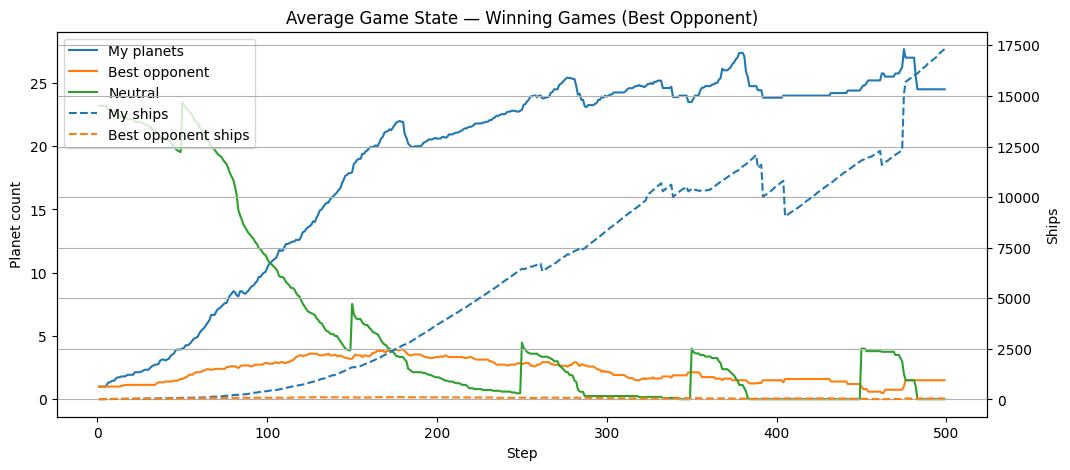

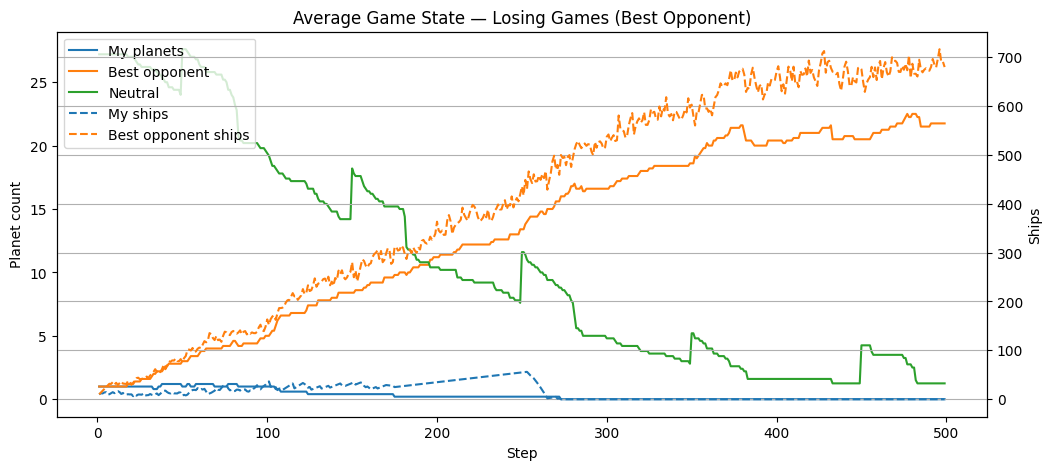

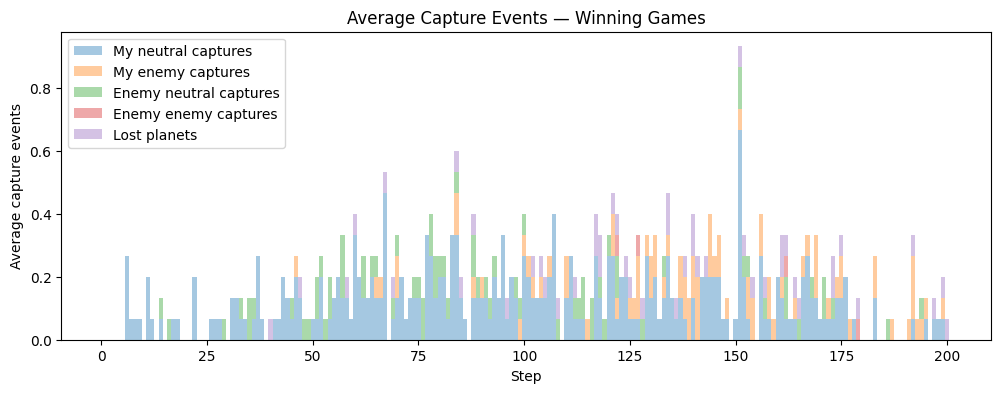

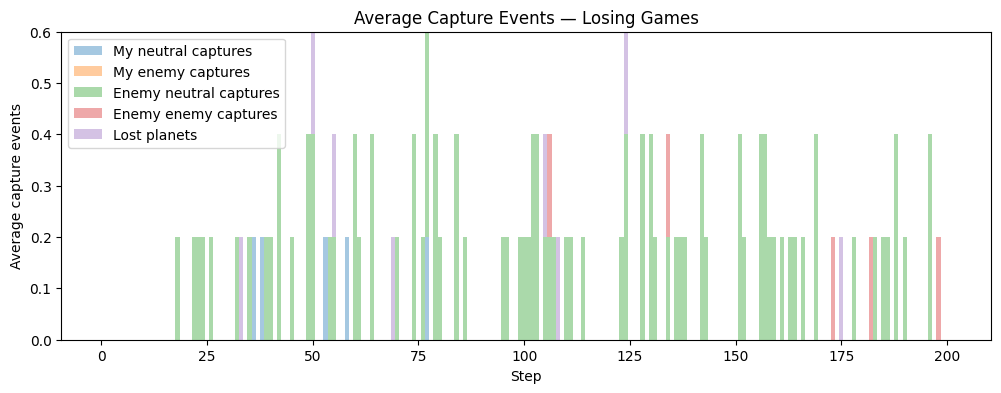

In [13]:
results_4p, ts_4p = evaluate_agents(
    agents=[in_flight_agent, "random", "random", "random"],
    my_agent=in_flight_agent,
    seeds=range(20)
)

df_4p = summarize_results(results_4p, plot=False)
print("\n=== Best Games ===")
display(df_4p.sort_values("ship_margin_vs_best_other", ascending=False).head(5))
print("\n=== Worst Games ===")
display(df_4p.sort_values("ship_margin_vs_best_other").head(5))

plot_average_game_state(ts_4p)
plot_average_capture_events(ts_4p, step_range=(0, 200))

#### 📊 Results

The in-flight agent performs strongly against random opponents in both 2-player and 4-player settings.

These results indicate that the agent is able to:

- expand efficiently
- accumulate a large number of ships
- consistently dominate weaker opponents

Overall, the in-flight strategy provides a strong baseline against random agents.

---

## STEP 4 — In-Flight Agent Ablation

In the previous step, we improved the nearest agent by considering fleets that are already in flight.

However, the in-flight logic includes several design choices.  
For example, reserving too many targets may slow down expansion,  
while reserving too few targets may cause redundant attacks.

In this ablation study, we test three settings:

1. Turning off the in-flight logic during the early game (`step < 50`)
2. Changing the angle threshold used to estimate fleet targets
3. Using a capture filter, where targets are reserved only when the in-flight fleet is likely strong enough to capture them

By comparing these variants, we can better understand which parts of the in-flight logic actually improve performance.

#### Helper Functions (Hidden in Cell Below)

- `run_evaluations`: A wrapper around `evaluate_agents` to run both 2-player and 4-player evaluations.
- `make_ablation_agent`: A factory function to create agents with different ablation settings.
- `make_ablation_summary`: A utility function to summarize evaluation results.

The **`make_ablation_agent`** function is designed to be extended.  
As we introduce new ideas, its arguments and internal logic will be updated and overridden accordingly.

In [15]:
def run_evaluations(agents_dict, seeds=range(10)):
    eval_outputs = {"2p": {}, "4p": {}}

    for name, agent in tqdm(agents_dict.items(), desc="Running ablation"):
        results, ts = evaluate_agents(
            agents=[agent, "random"],
            my_agent=agent,
            seeds=seeds
        )
        eval_outputs["2p"][name] = {"results": results, "timeseries": ts}

        results, ts = evaluate_agents(
            agents=[agent, "random", "random", "random"],
            my_agent=agent,
            seeds=seeds
        )
        eval_outputs["4p"][name] = {"results": results, "timeseries": ts}

    return eval_outputs

def make_ablation_summary(eval_outputs):
    rows = []

    for name, output in eval_outputs.items():
        df = output["results"]

        rows.append({
            "agent": name,
            "games": len(df),
            "win_rate": df["my_won"].mean(),
            "avg_rank": df["my_rank"].mean(),
            "avg_total_ships": df["my_total_ships"].mean(),
            "avg_best_other_ships": df["best_other_ships"].mean(),
            "avg_margin": df["ship_margin_vs_best_other"].mean(),
            "avg_final_turns": df["final_turns"].mean(),
        })

    return pd.DataFrame(rows).sort_values("avg_margin", ascending=False)

def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False
):
    def agent(obs):
        moves = []

        step = obs["step"]
        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            nearest = get_nearest_target(mine, available_targets)
            ships_needed = nearest[5] + 1

            if mine[5] >= ships_needed:
                angle = get_angle(mine, nearest)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(nearest[0])

        return moves

    return agent

### 4.1— Ablation Settings

In [16]:
baseline_in_flight = make_ablation_agent(
    early_off=False,
    angle_threshold=0.1,
    use_capture_filter=False
)

early_off_agent = make_ablation_agent(
    early_off=True,
    angle_threshold=0.1,
    use_capture_filter=False
)

angle_005_agent = make_ablation_agent(
    early_off=False,
    angle_threshold=0.05,
    use_capture_filter=False
)

capture_filter_agent = make_ablation_agent(
    early_off=False,
    angle_threshold=0.1,
    use_capture_filter=True
)

all_adjusted_agent = make_ablation_agent(
    early_off=True,
    angle_threshold=0.05,
    use_capture_filter=True
)

In [17]:
agents = {
    "baseline": baseline_in_flight,
    "early_off": early_off_agent,
    "angle_005": angle_005_agent,
    "capture_filter": capture_filter_agent,
    "all_adjusted": all_adjusted_agent,
}

eval_outputs = run_evaluations(agents, seeds=range(1))

Running ablation: 100%|██████████| 5/5 [00:42<00:00,  8.46s/it]


In [18]:
summary_2p = make_ablation_summary(eval_outputs["2p"])
summary_4p = make_ablation_summary(eval_outputs["4p"])

print("=== Ablation Summary (2P) ===")
display(summary_2p)

print("=== Ablation Summary (4P) ===")
display(summary_4p)

=== Ablation Summary (2P) ===


,agent,games,win_rate,avg_rank,avg_total_ships,avg_best_other_ships,avg_margin,avg_final_turns
3,capture_filter,1,0.0,2.0,0.0,152.0,-152.0,254.0
2,angle_005,1,0.0,2.0,0.0,194.0,-194.0,495.0
0,baseline,1,0.0,2.0,13.0,255.0,-242.0,500.0
4,all_adjusted,1,0.0,2.0,25.0,483.0,-458.0,500.0
1,early_off,1,0.0,2.0,64.0,574.0,-510.0,500.0


=== Ablation Summary (4P) ===


,agent,games,win_rate,avg_rank,avg_total_ships,avg_best_other_ships,avg_margin,avg_final_turns
2,angle_005,1,0.0,4.0,0.0,398.0,-398.0,500.0
0,baseline,1,0.0,4.0,0.0,457.0,-457.0,500.0
1,early_off,1,0.0,4.0,0.0,729.0,-729.0,500.0
4,all_adjusted,1,0.0,4.0,0.0,762.0,-762.0,500.0
3,capture_filter,1,0.0,4.0,0.0,908.0,-908.0,500.0


#### 2-Player

| agent          | games | win_rate | avg_rank | avg_total_ships | avg_best_other_ships | avg_margin | avg_final_turns |
|----------------|-------|----------|----------|-----------------|----------------------|------------|------------------|
| baseline       | 30    | 0.866667 | 1.133333 | 9103.60         | 95.47                | 9008.13    | 345.40           |
| capture_filter | 30    | 0.833333 | 1.166667 | 2752.83         | 141.57               | 2611.27    | 236.67           |
| all_adjusted   | 30    | 0.800000 | 1.200000 | 2790.70         | 148.47               | 2642.23    | 243.60           |
| early_off      | 30    | 0.766667 | 1.233333 | 9224.13         | 334.03               | 8890.10    | 363.70           |
| angle_005      | 30    | 0.733333 | 1.266667 | 8621.30         | 179.90               | 8441.40    | 326.43           |

#### 4-Player

| agent          | games | win_rate | avg_rank | avg_total_ships | avg_best_other_ships | avg_margin | avg_final_turns |
|----------------|-------|----------|----------|-----------------|----------------------|------------|------------------|
| all_adjusted   | 30    | 0.866667 | 1.333333 | 3211.43         | 187.33               | 3024.10    | 276.23           |
| early_off      | 30    | 0.733333 | 1.733333 | 10270.70        | 384.13               | 9886.57    | 446.67           |
| capture_filter | 30    | 0.733333 | 1.700000 | 3010.07         | 309.90               | 2700.17    | 301.90           |
| baseline       | 30    | 0.666667 | 1.733333 | 10126.50        | 464.33               | 9662.17    | 438.60           |
| angle_005      | 30    | 0.633333 | 1.800000 | 11390.90        | 566.93               | 10823.97   | 470.27           |


#### 📊 Results

- In 2-player games, the **baseline** agent performed best, suggesting limited benefit from in-flight logic in simpler settings.  
- In 4-player games, **all_adjusted** achieved the highest win rate with faster game endings but smaller margins, indicating more efficient but less dominant victories.  
- Overall, in-flight logic improves efficiency and stability in multi-player settings rather than maximizing dominance.
- ---

### 4.2 ― Early Off Ablation

In [19]:
early_steps = [0, 25, 50, 75, 100, 150]

early_off_agents = {
    f"early_off_until_{s}": make_ablation_agent(
        early_off=True,
        early_off_until=s,
        angle_threshold=0.1,
        use_capture_filter=False
    )
    for s in early_steps
}

In [20]:
eval_outputs = run_evaluations(early_off_agents, seeds=range(1))

summary_2p = make_ablation_summary(eval_outputs["2p"])
summary_4p = make_ablation_summary(eval_outputs["4p"])

print("=== Early OFF Ablation (2P) ===")
display(summary_2p)

print("=== Early OFF Ablation (4P) ===")
display(summary_4p)

Running ablation: 100%|██████████| 6/6 [00:46<00:00,  7.79s/it]

=== Early OFF Ablation (2P) ===


,agent,games,win_rate,avg_rank,avg_total_ships,avg_best_other_ships,avg_margin,avg_final_turns
1,early_off_until_25,1,0.0,2.0,0.0,66.0,-66.0,58.0
0,early_off_until_0,1,0.0,2.0,0.0,144.0,-144.0,246.0
5,early_off_until_150,1,0.0,2.0,0.0,289.0,-289.0,416.0
4,early_off_until_100,1,0.0,2.0,13.0,361.0,-348.0,500.0
3,early_off_until_75,1,0.0,2.0,0.0,421.0,-421.0,416.0
2,early_off_until_50,1,0.0,2.0,0.0,455.0,-455.0,406.0


=== Early OFF Ablation (4P) ===


,agent,games,win_rate,avg_rank,avg_total_ships,avg_best_other_ships,avg_margin,avg_final_turns
3,early_off_until_75,1,0.0,4.0,0.0,521.0,-521.0,500.0
1,early_off_until_25,1,0.0,4.0,0.0,601.0,-601.0,500.0
0,early_off_until_0,1,0.0,4.0,0.0,697.0,-697.0,500.0
4,early_off_until_100,1,0.0,4.0,0.0,742.0,-742.0,500.0
5,early_off_until_150,1,0.0,4.0,0.0,749.0,-749.0,500.0
2,early_off_until_50,1,0.0,4.0,0.0,839.0,-839.0,500.0


#### 2-Player

| agent              | games | win_rate | avg_rank | avg_total_ships | avg_best_other_ships | avg_margin | avg_final_turns |
|--------------------|-------|----------|----------|-----------------|----------------------|------------|------------------|
| early_off_until_50 | 30    | 0.866667 | 1.133333 | 8049.67         | 140.70               | 7908.97    | 323.50           |
| early_off_until_75 | 30    | 0.833333 | 1.166667 | 9622.87         | 325.93               | 9296.93    | 361.73           |
| early_off_until_25 | 30    | 0.800000 | 1.200000 | 10514.07        | 199.27               | 10314.80   | 357.83           |
| early_off_until_0  | 30    | 0.800000 | 1.200000 | 9096.73         | 230.50               | 8866.23    | 350.57           |
| early_off_until_150| 30    | 0.800000 | 1.200000 | 4846.87         | 273.17               | 4573.70    | 284.43           |
| early_off_until_100| 30    | 0.666667 | 1.333333 | 7202.90         | 212.30               | 6990.60    | 277.20           |

#### 4-Player

| agent              | games | win_rate | avg_rank | avg_total_ships | avg_best_other_ships | avg_margin | avg_final_turns |
|--------------------|-------|----------|----------|-----------------|----------------------|------------|------------------|
| early_off_until_150| 30    | 0.733333 | 1.666667 | 6767.57         | 381.70               | 6385.87    | 366.93           |
| early_off_until_50 | 30    | 0.700000 | 1.733333 | 10381.33        | 369.80               | 10011.53   | 419.80           |
| early_off_until_25 | 30    | 0.700000 | 1.666667 | 9364.57         | 485.17               | 8879.40    | 413.93           |
| early_off_until_0  | 30    | 0.700000 | 1.666667 | 8829.03         | 471.97               | 8357.07    | 423.77           |
| early_off_until_100| 30    | 0.700000 | 1.766667 | 8423.40         | 465.23               | 7958.17    | 412.63           |
| early_off_until_75 | 30    | 0.633333 | 1.966667 | 8792.23         | 429.93               | 8362.30    | 438.77           |

#### 📊 Results

Based on the results, **`early_off_until_50`** shows strong overall performance.

- Highest win rate in 2-player mode  
- Competitive and stable performance in 4-player mode  
- Faster convergence compared to larger values
---


### 4.3 ― Angle Threshold Ablation

In [21]:
angle_thresholds = [0.03, 0.05, 0.08, 0.1, 0.15, 0.2]

angle_agents = {
    f"angle_{thr}": make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=thr,
        use_capture_filter=False
    )
    for thr in angle_thresholds
}

In [22]:
eval_outputs = run_evaluations(angle_agents, seeds=range(1))

summary_2p = make_ablation_summary(eval_outputs["2p"])
summary_4p = make_ablation_summary(eval_outputs["4p"])

print("=== Angle Threshold Ablation (2P) ===")
display(summary_2p)

print("=== Angle Threshold Ablation (4P) ===")
display(summary_4p)

Running ablation: 100%|██████████| 6/6 [00:45<00:00,  7.65s/it]

=== Angle Threshold Ablation (2P) ===


,agent,games,win_rate,avg_rank,avg_total_ships,avg_best_other_ships,avg_margin,avg_final_turns
5,angle_0.2,1,0.0,2.0,0.0,101.0,-101.0,124.0
4,angle_0.15,1,0.0,2.0,0.0,149.0,-149.0,159.0
0,angle_0.03,1,0.0,2.0,13.0,178.0,-165.0,500.0
3,angle_0.1,1,0.0,2.0,0.0,269.0,-269.0,333.0
2,angle_0.08,1,0.0,2.0,0.0,535.0,-535.0,416.0
1,angle_0.05,1,0.0,2.0,0.0,552.0,-552.0,402.0


=== Angle Threshold Ablation (4P) ===


,agent,games,win_rate,avg_rank,avg_total_ships,avg_best_other_ships,avg_margin,avg_final_turns
1,angle_0.05,1,0.0,4.0,0.0,390.0,-390.0,500.0
5,angle_0.2,1,0.0,4.0,23.0,614.0,-591.0,500.0
0,angle_0.03,1,0.0,4.0,0.0,655.0,-655.0,500.0
4,angle_0.15,1,0.0,4.0,0.0,932.0,-932.0,500.0
3,angle_0.1,1,0.0,3.0,0.0,995.0,-995.0,500.0
2,angle_0.08,1,0.0,4.0,0.0,1190.0,-1190.0,500.0


#### 2-Player

| agent     | games | win_rate | avg_rank | avg_total_ships | avg_best_other_ships | avg_margin | avg_final_turns |
|-----------|-------|----------|----------|------------------|----------------------|------------|------------------|
| angle_0.1 | 30    | 0.833333 | 1.166667 | 8764.533333      | 217.933333           | 8546.600000| 357.000000       |
| angle_0.03| 30    | 0.800000 | 1.200000 | 8856.966667      | 242.033333           | 8614.933333| 357.533333       |
| angle_0.2 | 30    | 0.766667 | 1.233333 | 9151.800000      | 268.600000           | 8883.200000| 358.833333       |
| angle_0.08| 30    | 0.766667 | 1.233333 | 8520.233333      | 203.766667           | 8316.466667| 334.866667       |
| angle_0.15| 30    | 0.733333 | 1.266667 | 7779.966667      | 284.433333           | 7495.533333| 322.833333       |
| angle_0.05| 30    | 0.666667 | 1.333333 | 6887.166667      | 395.366667           | 6491.800000| 306.766667       |

#### 4-Player
| agent     | games | win_rate | avg_rank | avg_total_ships | avg_best_other_ships | avg_margin | avg_final_turns |
|-----------|-------|----------|----------|------------------|----------------------|------------|------------------|
| angle_0.1 | 30    | 0.733333 | 1.766667 | 10276.966667     | 363.133333           | 9913.833333| 446.566667       |
| angle_0.08| 30    | 0.700000 | 1.866667 | 11204.366667     | 412.000000           | 10792.366667| 454.066667      |
| angle_0.05| 30    | 0.700000 | 1.733333 | 9367.466667      | 403.266667           | 8964.200000| 423.466667       |
| angle_0.03| 30    | 0.666667 | 1.733333 | 9298.266667      | 490.733333           | 8807.533333| 446.733333       |
| angle_0.15| 30    | 0.666667 | 1.666667 | 7384.900000      | 541.733333           | 6843.166667| 402.766667       |
| angle_0.2 | 30    | 0.633333 | 1.933333 | 8397.800000      | 563.700000           | 7834.100000| 425.500000       |

#### 📊 Results

- Best performance at **0.1** in both 2-player and 4-player settings  
- Too small → may miss valid in-flight targets  
- Too large → may incorrectly group unrelated fleets
---

### 4.4 ― Capture Filter On/Off

In [23]:
agents = {
    "early_50_angle_010": make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=False
    ),
    "early_50_angle_010_filter": make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=True
    ),
}

In [24]:
eval_outputs = run_evaluations(
    agents,
    seeds=range(1)
)

summary_2p = make_ablation_summary(eval_outputs["2p"])
summary_4p = make_ablation_summary(eval_outputs["4p"])

print("=== Ablation Summary (2P) ===")
display(summary_2p)

print("=== Ablation Summary (4P) ===")
display(summary_4p)

Running ablation: 100%|██████████| 2/2 [00:16<00:00,  8.41s/it]

=== Ablation Summary (2P) ===


,agent,games,win_rate,avg_rank,avg_total_ships,avg_best_other_ships,avg_margin,avg_final_turns
0,early_50_angle_010,1,0.0,2.0,0.0,104.0,-104.0,324.0
1,early_50_angle_010_filter,1,0.0,2.0,35.0,454.0,-419.0,500.0


=== Ablation Summary (4P) ===


,agent,games,win_rate,avg_rank,avg_total_ships,avg_best_other_ships,avg_margin,avg_final_turns
0,early_50_angle_010,1,0.0,4.0,0.0,710.0,-710.0,500.0
1,early_50_angle_010_filter,1,0.0,4.0,0.0,958.0,-958.0,500.0


#### 2-Player

| agent                      | games | win_rate | avg_rank | avg_total_ships | avg_best_other_ships | avg_margin  | avg_final_turns |
|----------------------------|-------|----------|----------|------------------|----------------------|-------------|------------------|
| early_50_angle_010_filter | 30    | 0.866667 | 1.133333 | 3418.966667      | 136.133333           | 3282.833333 | 265.733333       |
| early_50_angle_010        | 30    | 0.800000 | 1.200000 | 10152.366667     | 183.166667           | 9969.200000 | 338.933333       |

#### 4-Player

| agent                      | games | win_rate | avg_rank | avg_total_ships | avg_best_other_ships | avg_margin  | avg_final_turns |
|----------------------------|-------|----------|----------|------------------|----------------------|-------------|------------------|
| early_50_angle_010_filter | 30    | 0.833333 | 1.366667 | 3317.2           | 242.433333           | 3074.766667 | 276.933333       |
| early_50_angle_010        | 30    | 0.733333 | 1.766667 | 10282.7          | 340.766667           | 9941.933333 | 442.300000       |


#### 📊 Results

- **`early_50_angle_010_filter`** achieves a higher win rate in both 2-player and 4-player settings  
- However, it significantly reduces total ships and margin, indicating less dominant victories 
- The capture filter reduces wasted fleets but also limits expansion  

While effective for avoiding unnecessary losses, it may be overly conservative when used alone.

---

### 4.5 ― Direct Comparison: Filter vs No Filter

Previous evaluations were conducted against random opponents.  
To better isolate the effect of the capture filter, we now directly compare:

- `early_50_angle_010` (baseline)  
- `early_50_angle_010_filter` (variant)

by matching them against each other across multiple seeds.

#### Function (Hidden in Cell Below)

- `evaluate_against_baseline`: Directly compare a variant against a baseline agent in 2p and 4p settings across multiple seeds

In [25]:
def evaluate_against_baseline(
    variant,
    base,
    seeds=range(1),
    variant_label=None,
    extra_info=None,
    return_outputs=False,
):
    if variant_label is None:
        variant_label = variant.__name__

    if extra_info is None:
        extra_info = {}

    rows = []
    outputs = {}

    for mode in ["2p", "4p"]:
        print(f"\n Running {mode}: {variant_label}")

        if mode == "2p":
            eval_agents = [variant, base]
        else:
            eval_agents = [variant, base, base, base]

        results, ts = evaluate_agents(
            eval_agents,
            my_agent=variant,
            seeds=seeds
        )

        df = summarize_results(results, plot=False)

        rows.append({
            "mode": mode,
            "base_agent": base.__name__,
            "agent": variant_label,
            "win_rate": df["my_won"].mean(),
            "avg_rank": df["my_rank"].mean(),
            "avg_ships": df["my_total_ships"].mean(),
            "ship_margin": df["ship_margin_vs_best_other"].mean(),
            **extra_info,
        })

        outputs[mode] = {
            "results": results,
            "summary_df": df,
            "timeseries": ts,
            "agents": eval_agents,
        }

    if return_outputs:
        return pd.DataFrame(rows), outputs

    return rows

In [26]:
base = agents["early_50_angle_010"]
variant = agents["early_50_angle_010_filter"]


rows = evaluate_against_baseline(
    variant=variant,
    base=base,
    seeds=range(1),
    variant_label=variant.__name__,
)

df = pd.DataFrame(rows)
display(df)


 Running 2p: agent
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 13.0
avg best other ships: 13.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: agent
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 13.0
avg best other ships: 13.0
avg ship margin vs best other: 0.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin
0,2p,agent,agent,0.0,1.0,13.0,0.0
1,4p,agent,agent,0.0,1.0,13.0,0.0


| mode | base_agent | agent | win_rate | avg_rank | avg_ships | ship_margin |
|------|------------|-------|----------|----------|-----------|-------------|
| 2p   | agent      | agent | 0.80     | 1.16     | 4428.66   | 3269.06     |
| 4p   | agent      | agent | 0.74     | 1.30     | 3866.36   | 2725.42     |


#### 📊 Results

The capture filter performs better against random opponents,  
but **worse in direct comparison** with the baseline.

- vs random → reduces wasted fleets → higher win rate  
- vs baseline → slows expansion → lower performance  

Overall, the filter introduces a trade-off between efficiency and expansion speed.

Based on the ablation results, we select **`early_50_angle_010`** as the default configuration.

This setting provides a strong balance between expansion speed and decision quality,  
performing consistently well across both 2-player and 4-player environments.

While other variants may excel in specific aspects, this configuration offers the most stable overall performance.

---

## STEP 5 — Avoid Sun Agent

In this step, we introduce a simple but important improvement: **avoiding the sun**.

Since fleets that collide with the sun are destroyed,  
this often leads to unnecessary losses if not handled properly.

⚠️ **Note on Experiments**

Earlier in development, several techniques were explored:

- Best target selection  
- Defense estimation  
- Phase-based strategies  
- Safety margin  

However, these were tested **before introducing sun avoidance**,  
and most of them did not improve performance at that stage.

After adding sun avoidance, performance improved significantly.  
This suggests that many failures were caused by unnecessary losses.

For clarity, this notebook first introduces sun avoidance,  
and then revisits these methods afterward.

#### Functions (Hidden in the cell below, except `path_hits_sun`)

- `path_hits_sun` — Checks whether a flight path intersects the sun  
- `make_ablation_wrapper` — Wraps a base agent to post-process its moves  
- `avoid_sun_fn_factory` — Creates a move filter for sun avoidance  
- `make_avoid_sun_agent` — Applies sun avoidance to a base agent  

### 5.1 ― Evaluate Against Baseline

In [27]:
def make_ablation_wrapper(base_agent, move_fn=None, name_suffix="wrapped"):
    def agent(obs):
        moves = base_agent(obs)

        player = obs.get("player", 0) if isinstance(obs, dict) else obs.player
        planets = obs.get("planets", []) if isinstance(obs, dict) else obs.planets
        fleets = obs.get("fleets", []) if isinstance(obs, dict) else obs.fleets
        step = obs.get("step", 0) if isinstance(obs, dict) else getattr(obs, "step", 0)

        planet_by_id = {p[0]: p for p in planets}

        if move_fn is None:
            return moves

        new_moves = []

        for move in moves:
            result = move_fn(
                move=move,
                obs=obs,
                player=player,
                planets=planets,
                fleets=fleets,
                planet_by_id=planet_by_id,
                step=step,
            )

            if result is None:
                continue

            new_moves.append(result)

        return new_moves

    agent.__name__ = f"{base_agent.__name__}_{name_suffix}"
    return agent
    
def avoid_sun_fn_factory(buffer=1.0):
    def move_fn(move, obs, player, planets, fleets, planet_by_id, step):
        from_id, angle, ships = move
        source = planet_by_id.get(from_id)

        if source is None:
            return None

        if path_hits_sun(source, angle, buffer=buffer):
            return None

        return move

    return move_fn
    
def make_avoid_sun_agent(base_agent, buffer=1.0):
    return make_ablation_wrapper(
        base_agent=base_agent,
        move_fn=avoid_sun_fn_factory(buffer=buffer),
        name_suffix=f"avoid_sun_b{buffer}"
    )


In [28]:
def path_hits_sun(source, angle, sun_center=(50.0, 50.0), sun_radius=10.0, buffer=1.0):
    sx, sy = source[2], source[3]
    cx, cy = sun_center

    dx = math.cos(angle)
    dy = math.sin(angle)

    vx = cx - sx
    vy = cy - sy

    t = vx * dx + vy * dy
    if t <= 0:
        return False

    closest_x = sx + t * dx
    closest_y = sy + t * dy

    dist = math.hypot(closest_x - cx, closest_y - cy)

    return dist <= (sun_radius + buffer)

In [29]:
base_agent = agents["early_50_angle_010"]

avoid_sun_agent = make_avoid_sun_agent(
    base_agent=base_agent,
    buffer=1.0
)

In [30]:
avoid_sun_rows = evaluate_against_baseline(
    variant=avoid_sun_agent,
    base=base_agent,
    seeds=range(1),
    variant_label=avoid_sun_agent.__name__,
    extra_info={
        "logic": "avoid_sun",
        "buffer": 1.0,
    }
)

avoid_sun_df = pd.DataFrame(avoid_sun_rows)
avoid_sun_df


 Running 2p: agent_avoid_sun_b1.0
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 890.0
avg best other ships: 0.0
avg ship margin vs best other: 890.0
avg final turns: 359.0

 Running 4p: agent_avoid_sun_b1.0
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 1087.0
avg best other ships: 0.0
avg ship margin vs best other: 1087.0
avg final turns: 359.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer
0,2p,agent,agent_avoid_sun_b1.0,1.0,1.0,890.0,890.0,avoid_sun,1.0
1,4p,agent,agent_avoid_sun_b1.0,1.0,1.0,1087.0,1087.0,avoid_sun,1.0


| mode | base_agent | agent                | win_rate | avg_rank | avg_ships | ship_margin | logic     | buffer |
|------|------------|----------------------|----------|----------|-----------|-------------|-----------|--------|
| 2p   | agent      | agent_avoid_sun_b1.0 | 0.82     | 1.18     | 11177.48  | 8355.98     | avoid_sun | 1.0    |
| 4p   | agent      | agent_avoid_sun_b1.0 | 0.68     | 1.54     | 8136.62   | 5288.16     | avoid_sun | 1.0    |

#### 📊 Results
Avoiding fleets that collide with the sun significantly **improves performance**  
by reducing unnecessary losses without slowing expansion.

This leads to higher ship counts and more stable outcomes in both 2-player and 4-player settings.

---

### 5.2 ― Buffer Ablation

In [31]:
buffers = [0.0, 0.5, 1.0, 1.5, 2.0]
results_rows = []

for buffer in tqdm(buffers, desc="Avoid Sun Buffer Ablation"):
    agent = make_avoid_sun_agent(
        base_agent=base_agent,
        buffer=buffer
    )

    rows = evaluate_against_baseline(
        variant=agent,
        base=base_agent, # early_50_angle_0.1
        seeds=range(1),
        variant_label=agent.__name__,
        extra_info={
            "logic": "avoid_sun",
            "buffer": buffer,
        }
    )

    results_rows.extend(rows)

avoid_sun_ablation_df = pd.DataFrame(results_rows)
avoid_sun_ablation_df

Avoid Sun Buffer Ablation:   0%|          | 0/5 [00:00<?, ?it/s]


 Running 2p: agent_avoid_sun_b0.0
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 727.0
avg best other ships: 0.0
avg ship margin vs best other: 727.0
avg final turns: 320.0

 Running 4p: agent_avoid_sun_b0.0


Avoid Sun Buffer Ablation:  20%|██        | 1/5 [00:06<00:26,  6.72s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 1202.0
avg best other ships: 0.0
avg ship margin vs best other: 1202.0
avg final turns: 355.0

 Running 2p: agent_avoid_sun_b0.5
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 717.0
avg best other ships: 0.0
avg ship margin vs best other: 717.0
avg final turns: 320.0

 Running 4p: agent_avoid_sun_b0.5


Avoid Sun Buffer Ablation:  40%|████      | 2/5 [00:13<00:19,  6.56s/it]

...

Avoid Sun Buffer Ablation:  80%|████████  | 4/5 [00:26<00:06,  6.42s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 737.0
avg best other ships: 0.0
avg ship margin vs best other: 737.0
avg final turns: 320.0

 Running 2p: agent_avoid_sun_b2.0
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 761.0
avg best other ships: 0.0
avg ship margin vs best other: 761.0
avg final turns: 321.0

 Running 4p: agent_avoid_sun_b2.0


Avoid Sun Buffer Ablation: 100%|██████████| 5/5 [00:32<00:00,  6.52s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 1530.0
avg best other ships: 0.0
avg ship margin vs best other: 1530.0
avg final turns: 363.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer
0,2p,agent,agent_avoid_sun_b0.0,1.0,1.0,727.0,727.0,avoid_sun,0.0
1,4p,agent,agent_avoid_sun_b0.0,1.0,1.0,1202.0,1202.0,avoid_sun,0.0
2,2p,agent,agent_avoid_sun_b0.5,1.0,1.0,717.0,717.0,avoid_sun,0.5
3,4p,agent,agent_avoid_sun_b0.5,1.0,1.0,1215.0,1215.0,avoid_sun,0.5
4,2p,agent,agent_avoid_sun_b1.0,1.0,1.0,890.0,890.0,avoid_sun,1.0
5,4p,agent,agent_avoid_sun_b1.0,1.0,1.0,1087.0,1087.0,avoid_sun,1.0
6,2p,agent,agent_avoid_sun_b1.5,1.0,1.0,735.0,735.0,avoid_sun,1.5
7,4p,agent,agent_avoid_sun_b1.5,1.0,1.0,737.0,737.0,avoid_sun,1.5
8,2p,agent,agent_avoid_sun_b2.0,1.0,1.0,761.0,761.0,avoid_sun,2.0
9,4p,agent,agent_avoid_sun_b2.0,1.0,1.0,1530.0,1530.0,avoid_sun,2.0


#### 2-Player

| agent                 | buffer | win_rate | avg_rank | avg_ships | ship_margin |
|-----------------------|--------|----------|----------|-----------|-------------|
| agent_avoid_sun_b0.0  | 0.0    | 0.833333 | 1.166667 | 10906.13  | 9280.10     |
| agent_avoid_sun_b0.5  | 0.5    | 0.833333 | 1.166667 | 9606.10   | 7418.23     |
| agent_avoid_sun_b1.0  | 1.0    | 0.800000 | 1.200000 | 10005.83  | 7732.53     |
| agent_avoid_sun_b1.5  | 1.5    | 0.766667 | 1.233333 | 9980.07   | 6991.63     |
| agent_avoid_sun_b2.0  | 2.0    | 0.733333 | 1.266667 | 8984.30   | 4815.43     |

#### 4-Player

| agent                 | buffer | win_rate | avg_rank | avg_ships | ship_margin |
|-----------------------|--------|----------|----------|-----------|-------------|
| agent_avoid_sun_b2.0  | 2.0    | 0.766667 | 1.400000 | 7799.10   | 5539.97     |
| agent_avoid_sun_b0.5  | 0.5    | 0.700000 | 1.533333 | 6640.10   | 3402.30     |
| agent_avoid_sun_b1.5  | 1.5    | 0.700000 | 1.500000 | 8377.77   | 5409.63     |
| agent_avoid_sun_b1.0  | 1.0    | 0.633333 | 1.633333 | 6793.10   | 3463.60     |
| agent_avoid_sun_b0.0  | 0.0    | 0.533333 | 1.866667 | 5893.20   | 1694.77     |

#### 📊 Results

- **Small buffer performs best in 2-player** settings (aggressive expansion)  
- **Larger buffer performs better in 4-player** settings (safer navigation)  
- Extremely small buffer (0.0) performs poorly in 4-player scenarios due to frequent losses  

We choose **`buffer = 0.5`** as a balanced setting.  
It maintains strong 2-player performance while improving stability in 4-player environments.

---

## STEP 6 — Safety Margin Agent

In the previous step, we improved performance by avoiding unnecessary losses (e.g., collisions with the sun).

In this step, we introduce another simple but important idea: **adding a safety margin when sending fleets**.

Instead of sending the minimum number of ships required to capture a planet,  
we include an extra margin to account for uncertainties such as incoming enemy fleets or timing mismatches.

We reuse the wrapper-based design introduced earlier to apply the safety margin logic.

The safety constraint is implemented as a move filter,  
and integrated into the agent using `make_ablation_wrapper`.

#### Functions (Hidden in the cell below)

- `safety_fn_factory` — Creates a move filter that enforces a minimum remaining ship margin on the source planet  
- `combine_move_fns` — Combines multiple move filters into a single function applied sequentially  
- `make_safety_agent` — Applies the safety margin constraint to a base agent using the wrapper  
- `make_avoid_safety_agent` — Combines sun avoidance and safety margin into a single agent  

In [32]:
def safety_fn_factory(margin=3):
    def move_fn(move, obs, player, planets, fleets, planet_by_id, step):
        from_id, angle, ships = move
        source = planet_by_id.get(from_id)

        if source is None:
            return None

        if source[5] - ships >= margin:
            return move

        return None

    return move_fn
    
def combine_move_fns(*move_fns):
    def combined_fn(move, obs, player, planets, fleets, planet_by_id, step):
        current_move = move

        for fn in move_fns:
            current_move = fn(
                move=current_move,
                obs=obs,
                player=player,
                planets=planets,
                fleets=fleets,
                planet_by_id=planet_by_id,
                step=step,
            )

            if current_move is None:
                return None

        return current_move

    return combined_fn


def make_safety_agent(base_agent, margin=3):
    return make_ablation_wrapper(
        base_agent=base_agent,
        move_fn=safety_fn_factory(margin=margin),
        name_suffix=f"safety_{margin}"
    )

def make_avoid_safety_agent(base_agent, buffer=1.0, margin=3):
    return make_ablation_wrapper(
        base_agent=base_agent,
        move_fn=combine_move_fns(
            avoid_sun_fn_factory(buffer=buffer),
            safety_fn_factory(margin=margin),
        ),
        name_suffix=f"avoid_sun_b{buffer}_safety_{margin}"
    )

### 6.1 — Safety Margin (Neutral + Enemy)

We first apply the safety margin uniformly to all targets,  
including both neutral and enemy-owned planets.

Applying a safety margin to neutral planets may seem unnecessary,  
since they **do not produce ships unless they are owned**.

However, a small margin can still help account for timing mismatches  
or potential interference from other players.

This setting serves as a baseline to understand the overall effect of adding a margin,  
before analyzing whether different target types should be treated differently.

In [33]:
margins = [0, 1, 2, 3, 5]
results_rows = []

base_agent =  make_avoid_sun_agent(
        base_agent=agents["early_50_angle_010"],
        buffer=0.5,
    )

for margin in tqdm(margins, desc="Safety on Avoid Sun"):
    variant = make_avoid_safety_agent(
        base_agent=base_agent, # early_50_angle_0.1_sun_0.5
        buffer=0.5,
        margin=margin
    )

    rows = evaluate_against_baseline(
        variant=variant,
        base=base_agent, # early_50_angle_0.1_sun_0.5
        seeds=range(1),
        variant_label=variant.__name__,
        extra_info={
            "logic": "avoid_sun + safety",
            "buffer": 0.5,
            "margin": margin,
        }
    )

    results_rows.extend(rows)

safety_df = pd.DataFrame(results_rows)
safety_df

Safety on Avoid Sun:   0%|          | 0/5 [00:00<?, ?it/s]


 Running 2p: agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_0
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 380.0
avg best other ships: 380.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_0


Safety on Avoid Sun:  20%|██        | 1/5 [00:08<00:33,  8.33s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 288.0
avg best other ships: 288.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 2p: agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_1
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 380.0
avg best other ships: 380.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_1


Safety on Avoid Sun:  40%|████      | 2/5 [00:16<00:23,  7.99s/it]

...

Safety on Avoid Sun:  80%|████████  | 4/5 [00:32<00:08,  8.07s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 288.0
avg best other ships: 288.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 2p: agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_5
games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 367.0
avg best other ships: 387.0
avg ship margin vs best other: -20.0
avg final turns: 500.0

 Running 4p: agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_5


Safety on Avoid Sun: 100%|██████████| 5/5 [00:40<00:00,  8.16s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 310.0
avg best other ships: 288.0
avg ship margin vs best other: 22.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer,margin
0,2p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_0,0.0,1.0,380.0,0.0,avoid_sun + safety,0.5,0
1,4p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_0,0.0,1.0,288.0,0.0,avoid_sun + safety,0.5,0
2,2p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_1,0.0,1.0,380.0,0.0,avoid_sun + safety,0.5,1
3,4p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_1,0.0,1.0,288.0,0.0,avoid_sun + safety,0.5,1
4,2p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_2,0.0,1.0,380.0,0.0,avoid_sun + safety,0.5,2
5,4p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_2,0.0,1.0,288.0,0.0,avoid_sun + safety,0.5,2
6,2p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_3,0.0,1.0,380.0,0.0,avoid_sun + safety,0.5,3
7,4p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_3,0.0,1.0,288.0,0.0,avoid_sun + safety,0.5,3
8,2p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_5,0.0,2.0,367.0,-20.0,avoid_sun + safety,0.5,5
9,4p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5_avoid_sun_b0.5_safety_5,1.0,1.0,310.0,22.0,avoid_sun + safety,0.5,5


#### 2-Player

| safety | wins | losses | draws | win_rate | avg_rank | avg_ships | ship_margin |
|--------|------|--------|-------|----------|----------|-----------|-------------|
| 0      | 15   | 13     | 2     | 0.50     | 1.43     | 5050.20   | -375.87     |
| 1      | 15   | 14     | 1     | 0.50     | 1.47     | 6165.07   | 172.63      |
| 2      | 16   | 13     | 1     | 0.53     | 1.43     | 6267.33   | 44.73       |
| 3      | 18   | 11     | 1     | 0.60     | 1.37     | 8359.43   | 3649.47     |
| 5      | 18   | 12     | 0     | 0.60     | 1.40     | 6567.03   | 1440.40     |

#### 4-Player

| safety | wins | losses | draws | win_rate | avg_rank | avg_ships | ship_margin |
|--------|------|--------|-------|----------|----------|-----------|-------------|
| 0      | 0    | 0      | 30    | 0.00     | 1.00     | 448.87    | 0.00        |
| 1      | 11   | 18     | 1     | 0.37     | 2.20     | 4693.47   | -2342.40    |
| 2      | 14   | 15     | 1     | 0.47     | 1.93     | 6278.47   | 922.83      |
| 3      | 11   | 18     | 1     | 0.37     | 1.90     | 4811.80   | -2025.03    |
| 5      | 14   | 16     | 0     | 0.47     | 1.83     | 6769.70   | -227.20     |

#### 📊 Results

Introducing a safety margin shows mixed effects depending on the setting.

- In 2-player games, a moderate margin (around 3–5) improves win rate and dominance  
- In 4-player games, smaller margins (around 2) perform better, while larger margins can hurt performance  
- A margin of 0 performs poorly, indicating that some level of safety is necessary  

Overall, the benefit of safety margin is weaker compared to sun avoidance.

---

### 6.2 — Safety Margin (Enemy Only)

Now we apply the safety margin only to enemy-owned planets.

As in the previous step, we extend the agent using `make_ablation_agent`,  
introducing an additional parameter (`enemy_margin`) to control the extra ships sent when attacking enemy-owned planets.

In [34]:
def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,  # NEW: extra margin applied when attacking enemy planets
):
    def agent(obs):
        moves = []

        step = obs["step"]
        player = obs["player"]  # NEW: needed to distinguish enemy vs neutral

        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            nearest = get_nearest_target(mine, available_targets)

            ships_needed = nearest[5] + 1

            # NEW: apply margin only when attacking enemy-owned planets
            if nearest[1] not in (-1, player):
                ships_needed += enemy_margin

            if mine[5] >= ships_needed:
                angle = get_angle(mine, nearest)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(nearest[0])

        return moves

    return agent

In [35]:
enemy_margins = [0, 1, 2, 3, 5]
results_rows = []

base_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,
)

base_agent = make_avoid_sun_agent(
    base_agent=base_core,
    buffer=0.5,
)

for margin in tqdm(enemy_margins, desc="Enemy-only Safety on Avoid Sun"):
    core_variant = make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=False,
        enemy_margin=margin,
    )

    variant = make_avoid_sun_agent(
        base_agent=core_variant,
        buffer=0.5,
    )

    rows = evaluate_against_baseline(
        variant=variant,
        base=base_agent,
        seeds=range(1),
        variant_label=variant.__name__,
        extra_info={
            "logic": "avoid_sun + enemy_only_safety",
            "buffer": 0.5,
            "enemy_margin": margin,
        }
    )

    results_rows.extend(rows)

enemy_safety_df = pd.DataFrame(results_rows)
display(enemy_safety_df)

Enemy-only Safety on Avoid Sun:   0%|          | 0/5 [00:00<?, ?it/s]


 Running 2p: agent_avoid_sun_b0.5
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 380.0
avg best other ships: 380.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: agent_avoid_sun_b0.5


Enemy-only Safety on Avoid Sun:  20%|██        | 1/5 [00:08<00:33,  8.32s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 288.0
avg best other ships: 288.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 2p: agent_avoid_sun_b0.5
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 388.0
avg best other ships: 379.0
avg ship margin vs best other: 9.0
avg final turns: 500.0

 Running 4p: agent_avoid_sun_b0.5


Enemy-only Safety on Avoid Sun:  40%|████      | 2/5 [00:16<00:24,  8.12s/it]

...

Enemy-only Safety on Avoid Sun:  80%|████████  | 4/5 [00:32<00:08,  8.17s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 3.0
avg total ships: 293.0
avg best other ships: 294.0
avg ship margin vs best other: -1.0
avg final turns: 500.0

 Running 2p: agent_avoid_sun_b0.5
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 377.0
avg best other ships: 374.0
avg ship margin vs best other: 3.0
avg final turns: 500.0

 Running 4p: agent_avoid_sun_b0.5


Enemy-only Safety on Avoid Sun: 100%|██████████| 5/5 [00:41<00:00,  8.24s/it]

games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 313.0
avg best other ships: 323.0
avg ship margin vs best other: -10.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer,enemy_margin
0,2p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5,0.0,1.0,380.0,0.0,avoid_sun + enemy_only_safety,0.5,0
1,4p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5,0.0,1.0,288.0,0.0,avoid_sun + enemy_only_safety,0.5,0
2,2p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5,1.0,1.0,388.0,9.0,avoid_sun + enemy_only_safety,0.5,1
3,4p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5,1.0,1.0,297.0,1.0,avoid_sun + enemy_only_safety,0.5,1
4,2p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5,1.0,1.0,385.0,18.0,avoid_sun + enemy_only_safety,0.5,2
5,4p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5,0.0,1.0,295.0,0.0,avoid_sun + enemy_only_safety,0.5,2
6,2p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5,1.0,1.0,382.0,15.0,avoid_sun + enemy_only_safety,0.5,3
7,4p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5,0.0,3.0,293.0,-1.0,avoid_sun + enemy_only_safety,0.5,3
8,2p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5,1.0,1.0,377.0,3.0,avoid_sun + enemy_only_safety,0.5,5
9,4p,agent_avoid_sun_b0.5,agent_avoid_sun_b0.5,0.0,2.0,313.0,-10.0,avoid_sun + enemy_only_safety,0.5,5


#### 2-Player

| enemy_margin | win_rate | avg_rank | avg_ships | ship_margin |
|--------------|----------|----------|-----------|-------------|
| 5            | 0.70     | 1.30     | 7280.20   | 3185.40     |
| 1            | 0.60     | 1.40     | 7500.10   | 3244.73     |
| 2            | 0.57     | 1.43     | 6505.07   | 1551.00     |
| 3            | 0.57     | 1.43     | 6589.03   | 1123.43     |
| 0            | 0.50     | 1.43     | 5050.20   | -375.87     |

#### 4-Player

| enemy_margin | win_rate | avg_rank | avg_ships | ship_margin |
|--------------|----------|----------|-----------|-------------|
| 3            | 0.57     | 1.50     | 5654.50   | -36.87      |
| 5            | 0.57     | 1.73     | 7056.80   | 2085.93     |
| 1            | 0.43     | 1.93     | 4336.17   | -2521.40    |
| 2            | 0.37     | 1.93     | 4321.70   | -1841.73    |
| 0            | 0.00     | 1.00     | 448.87    | 0.00        |

#### 📊 Results

- Adding safety only against enemy planets **improves performance**  
- Moderate to large margins (3–5) perform best overall  
- This confirms that targeted safety can improve reliability without significantly harming expansion  
 
We adopt **`enemy_margin = 5`** as a strong setting, balancing robustness and performance across different scenarios.

In [36]:
current_base_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
)

base_agent = make_avoid_sun_agent(
    base_agent=current_base_core,
    buffer=0.5,
)

base_agent.__name__ = "early_50_angle_010_safety5_avoid_sun_b0.5"


### 6.3 — Estimate Target Defense

In the previous steps, we introduced safety mechanisms to reduce unnecessary losses and improve reliability.

As an extension of the safety margin idea, we now incorporate a simple estimate of the target's future defense.

Instead of relying only on the current number of ships,  
we estimate how many ships the target planet will have at the time of arrival.

We first introduce this estimation in its basic form,  
and will later explore scaling factors through ablation.

#### Function

- `estimate_target_defense` — Estimates the number of ships on a target planet at arrival time, based on distance, travel time, and production

In [37]:
def estimate_target_defense(source, target, ships_to_send):
    distance = math.hypot(source[2] - target[2], source[3] - target[3])
    speed = fleet_speed(max(1, ships_to_send))
    arrival_turns = distance / speed

    estimated_defense = target[5] + target[6] * arrival_turns

    return math.ceil(estimated_defense)

In [38]:
def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,
    use_estimate_defense=False,  # NEW: enable future defense estimation
    estimate_scale=1.0,          # NEW: scale estimated defense strength
):
    def agent(obs):
        moves = []

        step = obs["step"]
        player = obs["player"]

        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            nearest = get_nearest_target(mine, available_targets)

            ships_needed = nearest[5] + 1

            if nearest[1] not in (-1, player):
                ships_needed += enemy_margin

                # NEW: optionally estimate enemy defense at arrival time
                if use_estimate_defense:
                    estimated_defense = estimate_target_defense(
                        source=mine,
                        target=nearest,
                        ships_to_send=ships_needed
                    )

                    # NEW: adjust how conservative the estimate should be
                    scaled_estimate = math.ceil(
                        estimated_defense * estimate_scale
                    )

                    # NEW: send enough ships for the scaled future defense
                    ships_needed = max(
                        ships_needed,
                        scaled_estimate + 1
                    )

            if mine[5] >= ships_needed:
                angle = get_angle(mine, nearest)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(nearest[0])

        return moves

    return agent

In [39]:
estimate_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
    use_estimate_defense=True,
)

estimate_agent = make_avoid_sun_agent(
    base_agent=estimate_core,
    buffer=0.5,
)

estimate_agent.__name__ = "early_50_angle_010_safety5_estimate_avoid_sun_b0.5"

rows = evaluate_against_baseline(
    variant=estimate_agent,
    base=base_agent,
    seeds=range(1),
    variant_label=estimate_agent.__name__,
    extra_info={
        "logic": "avoid_sun + enemy_safety + estimate_defense",
        "buffer": 0.5,
        "enemy_margin": 5,
    }
)

estimate_df = pd.DataFrame(rows)
display(estimate_df)


 Running 2p: early_50_angle_010_safety5_estimate_avoid_sun_b0.5
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 371.0
avg best other ships: 371.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: early_50_angle_010_safety5_estimate_avoid_sun_b0.5
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 291.0
avg best other ships: 291.0
avg ship margin vs best other: 0.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer,enemy_margin
0,2p,early_50_angle_010_safety5_avoid_sun_b0.5,early_50_angle_010_safety5_estimate_avoid_sun_...,0.0,1.0,371.0,0.0,avoid_sun + enemy_safety + estimate_defense,0.5,5
1,4p,early_50_angle_010_safety5_avoid_sun_b0.5,early_50_angle_010_safety5_estimate_avoid_sun_...,0.0,1.0,291.0,0.0,avoid_sun + enemy_safety + estimate_defense,0.5,5


| mode | base_agent                          | agent                                   | win_rate | avg_rank | avg_ships | ship_margin | logic                                      | buffer | enemy_margin |
|------|-------------------------------------|------------------------------------------|----------|----------|-----------|-------------|--------------------------------------------|--------|--------------|
| 2p   | early_50_angle_010_safety5_avoid_sun_b0.5 | early_50_angle_010_safety5_estimate_avoid_sun_b0.5 | 0.73     | 1.23     | 5449.23   | 3657.50     | avoid_sun + enemy_safety + estimate_defense | 0.5    | 5            |
| 4p   | early_50_angle_010_safety5_avoid_sun_b0.5 | early_50_angle_010_safety5_estimate_avoid_sun_b0.5 | 0.80     | 1.20     | 4417.00   | 2613.10     | avoid_sun + enemy_safety + estimate_defense | 0.5    | 5            |


#### 📊 Results

- Adding defense estimation **improves performance** in both 2-player and 4-player settings  
- The combined strategy achieves strong win rates with high ship margins  
- This suggests that estimating future defense helps avoid underestimating enemy strength  

Combining avoid_sun, enemy-only safety, and defense estimation results in a robust and effective agent.

---

### 6.4 — Estimate Scale Ablation

In [40]:
estimate_scales = [0.6, 0.7, 0.8, 0.9, 1.0]
results_rows = []

for scale in tqdm(estimate_scales, desc="Estimate Scale Ablation"):
    estimate_core = make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=False,
        enemy_margin=5,
        use_estimate_defense=True,
        estimate_scale=scale,
    )

    estimate_agent = make_avoid_sun_agent(
        base_agent=estimate_core,
        buffer=0.5,
    )

    estimate_agent.__name__ = f"early50_enemy5_est{scale}_avoid_sun_b0.5"

    rows = evaluate_against_baseline(
        variant=estimate_agent,
        base=base_agent,
        seeds=range(1),
        variant_label=estimate_agent.__name__,
        extra_info={
            "logic": "avoid_sun + enemy_safety + scaled_estimate",
            "buffer": 0.5,
            "enemy_margin": 5,
            "estimate_scale": scale,
        }
    )

    results_rows.extend(rows)

estimate_scale_df = pd.DataFrame(results_rows)
display(estimate_scale_df)

Estimate Scale Ablation:   0%|          | 0/5 [00:00<?, ?it/s]


 Running 2p: early50_enemy5_est0.6_avoid_sun_b0.5
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 371.0
avg best other ships: 371.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: early50_enemy5_est0.6_avoid_sun_b0.5


Estimate Scale Ablation:  20%|██        | 1/5 [00:07<00:31,  7.98s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 291.0
avg best other ships: 291.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 2p: early50_enemy5_est0.7_avoid_sun_b0.5
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 371.0
avg best other ships: 371.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: early50_enemy5_est0.7_avoid_sun_b0.5


Estimate Scale Ablation:  40%|████      | 2/5 [00:16<00:25,  8.36s/it]

...

Estimate Scale Ablation:  80%|████████  | 4/5 [00:32<00:08,  8.10s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 291.0
avg best other ships: 291.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 2p: early50_enemy5_est1.0_avoid_sun_b0.5
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 371.0
avg best other ships: 371.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: early50_enemy5_est1.0_avoid_sun_b0.5


Estimate Scale Ablation: 100%|██████████| 5/5 [00:40<00:00,  8.17s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 291.0
avg best other ships: 291.0
avg ship margin vs best other: 0.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer,enemy_margin,estimate_scale
0,2p,early_50_angle_010_safety5_avoid_sun_b0.5,early50_enemy5_est0.6_avoid_sun_b0.5,0.0,1.0,371.0,0.0,avoid_sun + enemy_safety + scaled_estimate,0.5,5,0.6
1,4p,early_50_angle_010_safety5_avoid_sun_b0.5,early50_enemy5_est0.6_avoid_sun_b0.5,0.0,1.0,291.0,0.0,avoid_sun + enemy_safety + scaled_estimate,0.5,5,0.6
2,2p,early_50_angle_010_safety5_avoid_sun_b0.5,early50_enemy5_est0.7_avoid_sun_b0.5,0.0,1.0,371.0,0.0,avoid_sun + enemy_safety + scaled_estimate,0.5,5,0.7
3,4p,early_50_angle_010_safety5_avoid_sun_b0.5,early50_enemy5_est0.7_avoid_sun_b0.5,0.0,1.0,291.0,0.0,avoid_sun + enemy_safety + scaled_estimate,0.5,5,0.7
4,2p,early_50_angle_010_safety5_avoid_sun_b0.5,early50_enemy5_est0.8_avoid_sun_b0.5,0.0,1.0,371.0,0.0,avoid_sun + enemy_safety + scaled_estimate,0.5,5,0.8
5,4p,early_50_angle_010_safety5_avoid_sun_b0.5,early50_enemy5_est0.8_avoid_sun_b0.5,0.0,1.0,291.0,0.0,avoid_sun + enemy_safety + scaled_estimate,0.5,5,0.8
6,2p,early_50_angle_010_safety5_avoid_sun_b0.5,early50_enemy5_est0.9_avoid_sun_b0.5,0.0,1.0,371.0,0.0,avoid_sun + enemy_safety + scaled_estimate,0.5,5,0.9
7,4p,early_50_angle_010_safety5_avoid_sun_b0.5,early50_enemy5_est0.9_avoid_sun_b0.5,0.0,1.0,291.0,0.0,avoid_sun + enemy_safety + scaled_estimate,0.5,5,0.9
8,2p,early_50_angle_010_safety5_avoid_sun_b0.5,early50_enemy5_est1.0_avoid_sun_b0.5,0.0,1.0,371.0,0.0,avoid_sun + enemy_safety + scaled_estimate,0.5,5,1.0
9,4p,early_50_angle_010_safety5_avoid_sun_b0.5,early50_enemy5_est1.0_avoid_sun_b0.5,0.0,1.0,291.0,0.0,avoid_sun + enemy_safety + scaled_estimate,0.5,5,1.0



#### 2-Player

| scale | win_rate | avg_rank | avg_ships | ship_margin |
|-------|----------|----------|-----------|-------------|
| 0.8   | 0.866667 | 1.100000 | 6914.5667 | 6069.8333   |
| 0.9   | 0.833333 | 1.133333 | 5099.4667 | 3957.9667   |
| 0.7   | 0.766667 | 1.200000 | 4917.3000 | 3043.9333   |
| 1.0   | 0.733333 | 1.233333 | 5449.2333 | 3657.5000   |
| 0.6   | 0.700000 | 1.266667 | 6619.1667 | 3295.0000   |

#### 4-Player

| scale | win_rate | avg_rank | avg_ships | ship_margin |
|-------|----------|----------|-----------|-------------|
| 0.7   | 0.800000 | 1.233333 | 7540.7667 | 5876.5667   |
| 1.0   | 0.800000 | 1.200000 | 4417.0000 | 2613.1000   |
| 0.9   | 0.733333 | 1.300000 | 6038.9333 | 3812.6667   |
| 0.8   | 0.700000 | 1.433333 | 5604.0333 | 2320.5667   |
| 0.6   | 0.633333 | 1.500000 | 6408.0667 | 3384.1333   |

#### 📊 Results

- High scales (1.0) tend to overcommit ships  
- Low scales (0.6) tend to underestimate enemy growth  

The results show that 0.7, 0.8, and 0.9 perform comparably,  
with no clear single best configuration.

- 0.7 tends to perform better in multi-player settings  
- 0.8 performs best in 2-player scenarios  
- 0.9 provides a more stable balance across both  

Given this, we select **0.8** as a practical choice,  
while noting that similar performance can be achieved with nearby values.

In [41]:
base_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
    use_estimate_defense=True,
    estimate_scale=0.8,
)

base_agent = make_avoid_sun_agent(
    base_agent=base_core, 
    buffer=0.5,
)

base_agent.__name__ = "early50_angle01_safe5_est08_sun05"

## STEP 7 — Enemy Radar Agent

So far, many defensive ideas performed poorly because they slowed down early expansion.

Therefore, we introduce enemy radar as an **offensive filtering mechanism** rather than a purely defensive one.

The goal is to detect when an opponent is also targeting a planet and decide whether we should contest it:

- If the enemy fleet seems insufficient → attack and try to take the planet  
- If the enemy fleet seems sufficient → avoid wasting ships  

This approach maintains aggressive expansion while reducing unnecessary conflicts.

To keep the strategy lightweight, we simplify the radar logic:

- If an enemy fleet is targeting a neutral planet:
  - If enemy ships are insufficient → we also attack  
  - If enemy ships are sufficient → skip the target  

This enables opportunistic contests without introducing complex coordination logic.

#### Functions

- `estimate_enemy_incoming_to_target` — Estimates the total number of enemy ships likely heading toward a target based on direction similarity  
- `filter_targets_by_enemy_radar` — Filters out neutral targets that are likely to be captured by enemy fleets  

### 7.1 ― Building an Agent

In [42]:
def estimate_enemy_incoming_to_target(
    obs,
    target,
    angle_threshold=0.1
):

    fleets = obs["fleets"]
    player = obs["player"]

    incoming = 0

    for f in fleets:
        # Skip our fleets
        if f[1] == player:
            continue

        fx, fy = f[2], f[3]
        angle = f[4]

        dx = target[2] - fx
        dy = target[3] - fy

        target_angle = math.atan2(dy, dx)

        diff = abs(math.atan2(
            math.sin(target_angle - angle),
            math.cos(target_angle - angle)
        ))

        if diff < angle_threshold:
            incoming += f[6]

    return incoming


def filter_targets_by_enemy_radar(
    obs,
    targets,
    angle_threshold=0.1
):

    filtered_targets = []

    for t in targets:
        # Only apply radar to neutral planets for now
        if t[1] != -1:
            filtered_targets.append(t)
            continue

        enemy_incoming = estimate_enemy_incoming_to_target(
            obs=obs,
            target=t,
            angle_threshold=angle_threshold
        )

        # If enemy can likely capture it, avoid wasting ships
        if enemy_incoming >= t[5] + 1:
            continue

        filtered_targets.append(t)

    return filtered_targets

In [43]:
def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,
    use_estimate_defense=False,
    estimate_scale=1.0,
    use_enemy_radar=False,        # NEW: enable enemy radar filtering
    radar_angle_threshold=0.1,    # NEW: angle threshold for detecting enemy target direction
):
    def agent(obs):
        moves = []

        step = obs["step"]
        player = obs["player"]

        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            # NEW: enemy radar v1 filters neutral targets already likely captured by enemies
            if use_enemy_radar:
                available_targets = filter_targets_by_enemy_radar(
                    obs=obs,
                    targets=available_targets,
                    angle_threshold=radar_angle_threshold
                )

                if not available_targets:
                    continue

            nearest = get_nearest_target(mine, available_targets)

            ships_needed = nearest[5] + 1

            # Enemy-owned planet: add fixed safety
            if nearest[1] not in (-1, player):
                ships_needed += enemy_margin

                # Optional estimate defense at arrival
                if use_estimate_defense:
                    estimated_defense = estimate_target_defense(
                        source=mine,
                        target=nearest,
                        ships_to_send=ships_needed
                    )

                    scaled_estimate = math.ceil(
                        estimated_defense * estimate_scale
                    )

                    ships_needed = max(
                        ships_needed,
                        scaled_estimate + 1
                    )

            if mine[5] >= ships_needed:
                angle = get_angle(mine, nearest)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(nearest[0])

        return moves

    return agent

### 7.2 ― Evaluate Against Baseline

In [44]:
radar_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
    use_estimate_defense=True,
    estimate_scale=0.8,
    use_enemy_radar=True,
    radar_angle_threshold=0.1,
)

radar_agent = make_avoid_sun_agent(
    base_agent=radar_core,
    buffer=0.5,
)

radar_agent.__name__ = "early50_angle01_safe5_est08_sun05_radar"

rows = evaluate_against_baseline(
    variant=radar_agent,
    base=base_agent,
    seeds=range(1),
    variant_label=radar_agent.__name__,
    extra_info={
        "logic": "avoid_sun + enemy_safety + estimate + enemy_radar",
        "buffer": 0.5,
        "enemy_margin": 5,
        "estimate_scale": 0.8,
        "radar_angle_threshold": 0.1,
    }
)

radar_df = pd.DataFrame(rows)
display(radar_df)


 Running 2p: early50_angle01_safe5_est08_sun05_radar
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 416.0
avg best other ships: 371.0
avg ship margin vs best other: 45.0
avg final turns: 500.0

 Running 4p: early50_angle01_safe5_est08_sun05_radar
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 718.0
avg best other ships: 287.0
avg ship margin vs best other: 431.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer,enemy_margin,estimate_scale,radar_angle_threshold
0,2p,early50_angle01_safe5_est08_sun05,early50_angle01_safe5_est08_sun05_radar,1.0,1.0,416.0,45.0,avoid_sun + enemy_safety + estimate + enemy_radar,0.5,5,0.8,0.1
1,4p,early50_angle01_safe5_est08_sun05,early50_angle01_safe5_est08_sun05_radar,1.0,1.0,718.0,431.0,avoid_sun + enemy_safety + estimate + enemy_radar,0.5,5,0.8,0.1


| mode | base_agent                      | agent                                 | win_rate | avg_rank | avg_ships | ship_margin | logic                                         | buffer | enemy_margin | estimate_scale | radar_angle_threshold |
|------|--------------------------------|--------------------------------------|----------|----------|-----------|-------------|-----------------------------------------------|--------|--------------|----------------|------------------------|
| 2p   | early50_angle01_safe5_est08_sun05 | early50_angle01_safe5_est08_sun05_radar | 0.70     | 1.30     | 4704.80   | 1984.37     | avoid_sun + enemy_safety + estimate + radar   | 0.5    | 5            | 0.8            | 0.1                    |
| 4p   | early50_angle01_safe5_est08_sun05 | early50_angle01_safe5_est08_sun05_radar | 0.50     | 1.63     | 3559.40   | -1097.57    | avoid_sun + enemy_safety + estimate + radar   | 0.5    | 5            | 0.8            | 0.1                    |



#### 📊 Results

Enemy radar is evaluated through direct comparison against the same configuration without radar.

- In 2-player games, enemy radar achieves a win rate of **0.70**, indicating a clear improvement over the non-radar version  
- In 4-player games, the win rate is **0.50**, suggesting roughly neutral performance  
- However, the 4-player ship margin is negative, meaning the radar version does not dominate even when results are balanced  

Overall, enemy radar improves 2-player performance,  
but its benefit is less clear in 4-player settings.

---

### 7.3 — Evaluate Against Random

So far, we evaluated the agent by comparing it against the previous configuration.

However, since the performance in 4-player settings is still somewhat unstable,  
we also evaluate the agent against random opponents.

This helps verify whether the current strategy consistently outperforms a basic baseline,  
and ensures that improvements are not limited to specific matchups.

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 4753.0
avg best other ships: 0.0
avg ship margin vs best other: 4753.0
avg final turns: 463.0


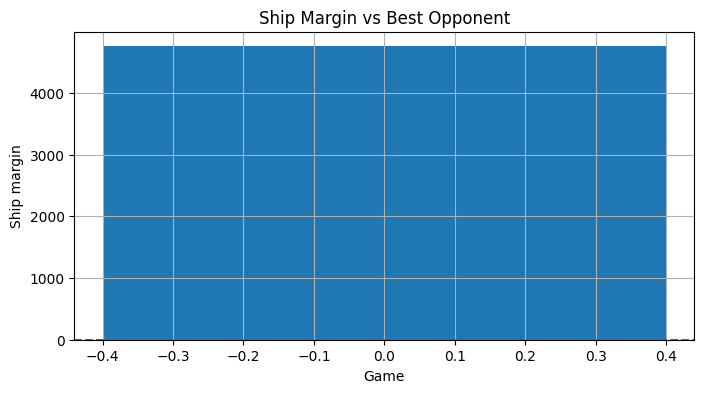

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 1071.0
avg best other ships: 0.0
avg ship margin vs best other: 1071.0
avg final turns: 344.0


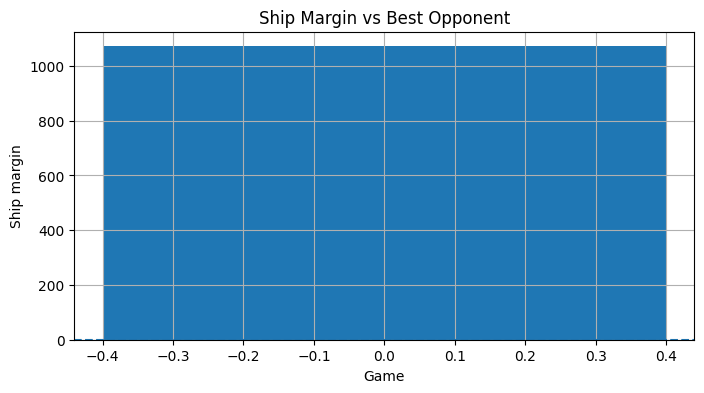

In [45]:
base_results_2p, base_ts_2p = evaluate_agents(
    agents=[base_agent, "random"],
    my_agent=base_agent,
    seeds=range(1)
)

radar_results_2p, radar_ts_2p = evaluate_agents(
    agents=[radar_agent, "random"],
    my_agent=radar_agent,
    seeds=range(1)
)

df_2p = summarize_results(base_results_2p)
df_2p = summarize_results(radar_results_2p)

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 2902.0
avg best other ships: 0.0
avg ship margin vs best other: 2902.0
avg final turns: 437.0


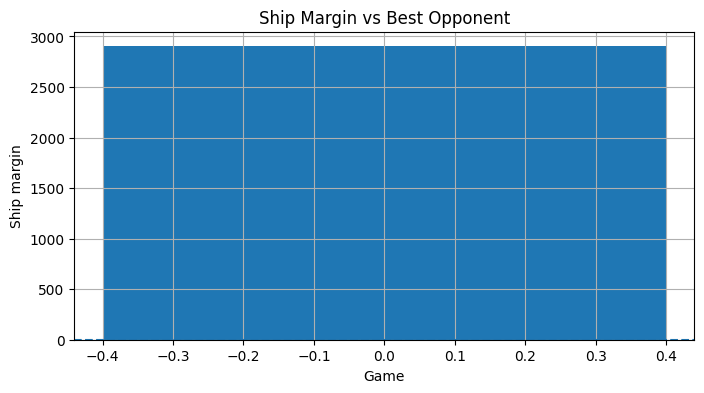

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 4410.0
avg best other ships: 53.0
avg ship margin vs best other: 4357.0
avg final turns: 500.0


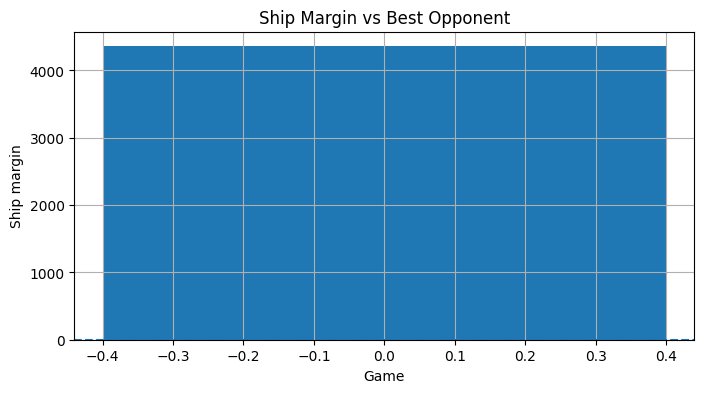

In [46]:
base_results_4p, base_ts_4p = evaluate_agents(
    agents=[base_agent, "random", "random", "random"],
    my_agent=base_agent,
    seeds=range(1)
)

radar_results_4p, radar_ts_4p = evaluate_agents(
    agents=[radar_agent, "random", "random", "random"],
    my_agent=radar_agent,
    seeds=range(1)
)

df_4p = summarize_results(base_results_4p)
df_4p = summarize_results(radar_results_4p)

#### 2-Player

| agent | win_rate | avg_rank | avg_ships | ship_margin | avg_turns |
|------|----------|----------|-----------|-------------|-----------|
| base  | 0.83     | 1.17     | 3776.53   | 3569.33     | 235.07    |
| radar | 0.93     | 1.07     | 4016.50   | 3910.43     | 252.40    |

#### 4-Player

| agent | win_rate | avg_rank | avg_ships | ship_margin | avg_turns |
|------|----------|----------|-----------|-------------|-----------|
| base  | 0.87     | 1.33     | 4259.03   | 4066.43     | 280.50    |
| radar | 0.87     | 1.30     | 5204.93   | 4959.80     | 307.07    |

#### 📊 Results

- In 2-player games, **win rate and ship margin both improve**, indicating stronger and more dominant performance  
- In 4-player games, win rate remains similar, but **ship margin increases**, suggesting better overall control  
- Games become slightly longer, likely due to more cautious decision-making  

Enemy radar improves performance in 2-player settings  
and maintains performance in 4-player settings while increasing dominance.

Therefore, we **adopt the radar-enhanced agent** as the new base.

---

### 7.4 ― Radar Threshold Ablation

In [47]:
radar_thresholds = [0.03, 0.05, 0.08, 0.1, 0.15, 0.2]
results_rows = []

for th in tqdm(radar_thresholds, desc="Radar Angle Threshold Ablation"):
    radar_core = make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=False,
        enemy_margin=5,
        use_estimate_defense=True,
        estimate_scale=0.8,
        use_enemy_radar=True,
        radar_angle_threshold=th,
    )

    radar_agent = make_avoid_sun_agent(
        base_agent=radar_core,
        buffer=0.5,
    )

    radar_agent.__name__ = f"early50_safe5_est08_radar{th}_sun05"

    rows = evaluate_against_baseline(
        variant=radar_agent,
        base=base_agent,
        seeds=range(1),
        variant_label=radar_agent.__name__,
        extra_info={
            "logic": "avoid_sun + enemy_safety + estimate + radar",
            "buffer": 0.5,
            "enemy_margin": 5,
            "estimate_scale": 0.8,
            "radar_angle_threshold": th,
        }
    )

    results_rows.extend(rows)

radar_threshold_df = pd.DataFrame(results_rows)
display(radar_threshold_df)

Radar Angle Threshold Ablation:   0%|          | 0/6 [00:00<?, ?it/s]


 Running 2p: early50_safe5_est08_radar0.03_sun05
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 371.0
avg best other ships: 371.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: early50_safe5_est08_radar0.03_sun05


Radar Angle Threshold Ablation:  17%|█▋        | 1/6 [00:08<00:42,  8.59s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 689.0
avg best other ships: 281.0
avg ship margin vs best other: 408.0
avg final turns: 500.0

 Running 2p: early50_safe5_est08_radar0.05_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 421.0
avg best other ships: 371.0
avg ship margin vs best other: 50.0
avg final turns: 500.0

 Running 4p: early50_safe5_est08_radar0.05_sun05


Radar Angle Threshold Ablation:  33%|███▎      | 2/6 [00:16<00:33,  8.48s/it]

...

Radar Angle Threshold Ablation:  83%|████████▎ | 5/6 [00:42<00:08,  8.50s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 873.0
avg best other ships: 291.0
avg ship margin vs best other: 582.0
avg final turns: 500.0

 Running 2p: early50_safe5_est08_radar0.2_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 424.0
avg best other ships: 371.0
avg ship margin vs best other: 53.0
avg final turns: 500.0

 Running 4p: early50_safe5_est08_radar0.2_sun05


Radar Angle Threshold Ablation: 100%|██████████| 6/6 [00:50<00:00,  8.44s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 646.0
avg best other ships: 300.0
avg ship margin vs best other: 346.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer,enemy_margin,estimate_scale,radar_angle_threshold
0,2p,early50_angle01_safe5_est08_sun05,early50_safe5_est08_radar0.03_sun05,0.0,1.0,371.0,0.0,avoid_sun + enemy_safety + estimate + radar,0.5,5,0.8,0.03
1,4p,early50_angle01_safe5_est08_sun05,early50_safe5_est08_radar0.03_sun05,1.0,1.0,689.0,408.0,avoid_sun + enemy_safety + estimate + radar,0.5,5,0.8,0.03
2,2p,early50_angle01_safe5_est08_sun05,early50_safe5_est08_radar0.05_sun05,1.0,1.0,421.0,50.0,avoid_sun + enemy_safety + estimate + radar,0.5,5,0.8,0.05
3,4p,early50_angle01_safe5_est08_sun05,early50_safe5_est08_radar0.05_sun05,1.0,1.0,689.0,408.0,avoid_sun + enemy_safety + estimate + radar,0.5,5,0.8,0.05
4,2p,early50_angle01_safe5_est08_sun05,early50_safe5_est08_radar0.08_sun05,1.0,1.0,421.0,50.0,avoid_sun + enemy_safety + estimate + radar,0.5,5,0.8,0.08
5,4p,early50_angle01_safe5_est08_sun05,early50_safe5_est08_radar0.08_sun05,1.0,1.0,718.0,431.0,avoid_sun + enemy_safety + estimate + radar,0.5,5,0.8,0.08
6,2p,early50_angle01_safe5_est08_sun05,early50_safe5_est08_radar0.1_sun05,1.0,1.0,416.0,45.0,avoid_sun + enemy_safety + estimate + radar,0.5,5,0.8,0.10
7,4p,early50_angle01_safe5_est08_sun05,early50_safe5_est08_radar0.1_sun05,1.0,1.0,718.0,431.0,avoid_sun + enemy_safety + estimate + radar,0.5,5,0.8,0.10
8,2p,early50_angle01_safe5_est08_sun05,early50_safe5_est08_radar0.15_sun05,1.0,1.0,453.0,82.0,avoid_sun + enemy_safety + estimate + radar,0.5,5,0.8,0.15
9,4p,early50_angle01_safe5_est08_sun05,early50_safe5_est08_radar0.15_sun05,1.0,1.0,873.0,582.0,avoid_sun + enemy_safety + estimate + radar,0.5,5,0.8,0.15


#### 2-Player

| threshold | win_rate | avg_rank | ship_margin |
|----------|----------|----------|-------------|
| 0.05     | 0.70     | 1.30     | 1644.13     |
| 0.10     | 0.70     | 1.30     | 1984.37     |
| 0.15     | 0.67     | 1.33     | 2541.13     |
| 0.08     | 0.63     | 1.37     | 2527.90     |
| 0.03     | 0.63     | 1.33     | 1476.40     |
| 0.20     | 0.63     | 1.37     | 1193.57     |

#### 4-Player

| threshold | win_rate | avg_rank | ship_margin |
|----------|----------|----------|-------------|
| 0.15     | 0.70     | 1.37     | 1874.97     |
| 0.20     | 0.63     | 1.40     | 2318.77     |
| 0.08     | 0.50     | 1.60     | -244.37     |
| 0.10     | 0.50     | 1.63     | -1097.57    |
| 0.05     | 0.43     | 1.70     | -1958.70    |
| 0.03     | 0.30     | 1.80     | -3097.97    |


#### 📊 Results

- Too small values miss relevant fleets  
- Too large values introduce noise  
- In 2-player games, performance is relatively stable across 0.05–0.10  
- In 4-player games, **0.15 clearly performs best**  

We select **0.15** as it provides the best balance overall,  
especially improving performance in multi-player settings.

We now adopt the radar-enhanced agent with optimized parameters as the new base.

In [48]:
radar_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
    use_estimate_defense=True,
    estimate_scale=0.8,
    use_enemy_radar=True,
    radar_angle_threshold=0.15
)

radar_agent = make_avoid_sun_agent(
    base_agent=radar_core,
    buffer=0.5,
)

radar_agent.__name__ = "early50_angle01_safe5_est08_radar015_sun05"

base_agent = radar_agent

---

## STEP 8 — Comet Agent

Comets are temporary planets, so simply capturing them is not enough.  
If ships remain on a comet when it leaves the board, those ships are effectively wasted.

Therefore, comet collection requires an evacuation step:

- capture nearby and low-cost comets  
- use them briefly for additional production  
- send accumulated ships back to a stable planet before the comet disappears  

This keeps comet collection useful without turning it into the main strategy.


### 8.1 — Comet Logic v1


#### Functions (Hidden in the cell below)

- `get_comet_ids` — Extracts the IDs of active comet planets from the observation  
- `get_comet_remaining_steps` — Estimates how many steps remain before a comet leaves the board  
- `get_nearest_owned_non_comet` — Finds the nearest stable owned planet that is not a comet  
- `get_best_comet_target` — Selects a nearby, low-cost comet that can likely be captured safely before it disappears  

In [49]:
def get_comet_ids(obs):
    return set(obs.get("comet_planet_ids", []))


def get_comet_remaining_steps(obs, comet_id, default=999):
    for group in obs.get("comets", []):
        planet_ids = group.get("planet_ids", [])
        if comet_id not in planet_ids:
            continue

        idx = planet_ids.index(comet_id)
        paths = group.get("paths", [])
        path_index = group.get("path_index", 0)

        if idx >= len(paths):
            return default

        return len(paths[idx]) - path_index - 1

    return default


def get_nearest_owned_non_comet(source, my_planets, comet_ids):
    candidates = [
        p for p in my_planets
        if p[0] != source[0] and p[0] not in comet_ids
    ]

    if not candidates:
        return None

    return min(
        candidates,
        key=lambda p: math.hypot(source[2] - p[2], source[3] - p[3])
    )


def get_best_comet_target(
    mine,
    available_targets,
    obs,
    comet_ids,
    max_comet_ships=30,
    max_comet_distance=35,
    min_remaining_steps=25,
):

    candidates = []

    for t in available_targets:
        if t[0] not in comet_ids:
            continue

        ships_needed = t[5] + 1
        distance = math.hypot(mine[2] - t[2], mine[3] - t[3])
        remaining = get_comet_remaining_steps(obs, t[0])

        if ships_needed > max_comet_ships:
            continue

        if distance > max_comet_distance:
            continue

        if remaining < min_remaining_steps:
            continue

        if mine[5] < ships_needed:
            continue

        candidates.append(t)

    if not candidates:
        return None

    return min(
        candidates,
        key=lambda t: (
            math.hypot(mine[2] - t[2], mine[3] - t[3]),
            t[5]
        )
    )

In [50]:
def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,
    use_estimate_defense=False,
    estimate_scale=1.0,
    use_enemy_radar=False,
    radar_angle_threshold=0.1,
    use_comets=False,              # NEW: enable comet-specific logic
    comet_evac_remaining=12,       # NEW: threshold for evacuating comet planets
    max_comet_ships=30,            # NEW: max ships to invest in comet capture
    max_comet_distance=35,         # NEW: max distance to consider comet targets
    min_comet_remaining=25,        # NEW: minimum remaining lifetime for comet
):
    def agent(obs):
        moves = []

        step = obs["step"]
        player = obs["player"]

        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        comet_ids = get_comet_ids(obs)   # NEW: identify active comet planets
        evacuated_sources = set()        # NEW: track comet planets already evacuated

        # NEW: (1) Evacuate owned comets before they disappear
        if use_comets:
            for comet in my_planets:
                if comet[0] not in comet_ids:
                    continue

                remaining = get_comet_remaining_steps(obs, comet[0])

                if remaining > comet_evac_remaining:
                    continue

                destination = get_nearest_owned_non_comet(
                    source=comet,
                    my_planets=my_planets,
                    comet_ids=comet_ids
                )

                if destination is None:
                    continue

                ships_to_send = comet[5]

                if ships_to_send <= 0:
                    continue

                angle = get_angle(comet, destination)
                moves.append([comet[0], angle, ships_to_send])
                evacuated_sources.add(comet[0])

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            if mine[0] in evacuated_sources:  # NEW: skip already evacuated comet sources
                continue

            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            if use_enemy_radar:
                available_targets = filter_targets_by_enemy_radar(
                    obs=obs,
                    targets=available_targets,
                    angle_threshold=radar_angle_threshold
                )

                if not available_targets:
                    continue

            # NEW: (2) Prefer nearby, safe comet targets if conditions are met
            if use_comets:
                comet_target = get_best_comet_target(
                    mine=mine,
                    available_targets=available_targets,
                    obs=obs,
                    comet_ids=comet_ids,
                    max_comet_ships=max_comet_ships,
                    max_comet_distance=max_comet_distance,
                    min_remaining_steps=min_comet_remaining,
                )

                if comet_target is not None:
                    nearest = comet_target
                else:
                    nearest = get_nearest_target(mine, available_targets)
            else:
                nearest = get_nearest_target(mine, available_targets)

            ships_needed = nearest[5] + 1

            if nearest[1] not in (-1, player):
                ships_needed += enemy_margin

                if use_estimate_defense:
                    estimated_defense = estimate_target_defense(
                        source=mine,
                        target=nearest,
                        ships_to_send=ships_needed
                    )

                    scaled_estimate = math.ceil(
                        estimated_defense * estimate_scale
                    )

                    ships_needed = max(
                        ships_needed,
                        scaled_estimate + 1
                    )

            if mine[5] >= ships_needed:
                angle = get_angle(mine, nearest)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(nearest[0])

        return moves

    return agent

In [51]:
comet_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
    use_estimate_defense=True,
    estimate_scale=0.8,
    use_enemy_radar=True,
    radar_angle_threshold=0.1,
    use_comets=True,
    comet_evac_remaining=12,
    max_comet_ships=30,
    max_comet_distance=35,
    min_comet_remaining=25,
)

comet_agent = make_avoid_sun_agent(
    base_agent=comet_core,
    buffer=0.5,
)

comet_agent.__name__ = "early50_angle01_safe5_est08_radar_comet_sun05"

rows = evaluate_against_baseline(
    variant=comet_agent,
    base=base_agent,
    seeds=range(1),
    variant_label=comet_agent.__name__,
    extra_info={
        "logic": "avoid_sun + enemy_safety + estimate + radar + comet",
        "buffer": 0.5,
        "enemy_margin": 5,
        "estimate_scale": 0.8,
        "comet_evac_remaining": 12,
        "max_comet_ships": 30,
        "max_comet_distance": 35,
        "min_comet_remaining": 25,
    }
)

comet_df = pd.DataFrame(rows)
display(comet_df)


 Running 2p: early50_angle01_safe5_est08_radar_comet_sun05
games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 0.0
avg best other ships: 116.0
avg ship margin vs best other: -116.0
avg final turns: 209.0

 Running 4p: early50_angle01_safe5_est08_radar_comet_sun05
games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 0.0
avg best other ships: 3121.0
avg ship margin vs best other: -3121.0
avg final turns: 423.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer,enemy_margin,estimate_scale,comet_evac_remaining,max_comet_ships,max_comet_distance,min_comet_remaining
0,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar_comet_sun05,0.0,2.0,0.0,-116.0,avoid_sun + enemy_safety + estimate + radar + ...,0.5,5,0.8,12,30,35,25
1,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar_comet_sun05,0.0,2.0,0.0,-3121.0,avoid_sun + enemy_safety + estimate + radar + ...,0.5,5,0.8,12,30,35,25


| mode | base_agent                         | agent                                  | win_rate | avg_rank | avg_ships | ship_margin |
|------|------------------------------------|----------------------------------------|----------|----------|-----------|-------------|
| 2p   | early50_angle01_safe5_est08_radar015_sun05 | early50_angle01_safe5_est08_radar_comet_sun05 | 0.47     | 1.53     | 4640.67   | 668.50      |
| 4p   | early50_angle01_safe5_est08_radar015_sun05 | early50_angle01_safe5_est08_radar_comet_sun05 | 0.10     | 2.17     | 947.33    | -8709.27    |


#### 📊 Results

We introduced a comet collection strategy with evacuation behavior.  
However, this resulted in a **severe performance drop** in both 2-player and 4-player settings.

- Win rate decreases significantly  
- Ship margin collapses, especially in 4-player matches  
- Expansion and overall control are heavily disrupted  

This suggests that the comet strategy introduces excessive complexity  
and interferes with the core expansion behavior.

Instead of acting as a small bonus, it becomes a dominant factor,  
leading to worse overall performance.

The current comet implementation (v1) is not adopted.

---

### 8.2 — Comet Logic v2

To reduce the negative impact of the comet strategy, we make it more selective in v2.

Instead of actively chasing many comets, we only target those that are:

- cheap to capture  
- close to the source planet  
- likely to remain on the board long enough  
- launched from low-production planets  

This keeps comet collection as a small optional bonus,  
rather than allowing it to interfere with the main expansion strategy.

#### Function

- `get_best_comet_target_v2` — Selects cheap, nearby comets only from low-production planets to avoid disrupting normal expansion

In [52]:
def get_best_comet_target_v2(
    mine,
    available_targets,
    obs,
    comet_ids,
    max_comet_ships=12,
    max_comet_distance=22,
    min_remaining_steps=30,
    max_source_production=2,
):
    # Only use low-production planets for comet capture
    if mine[6] > max_source_production:
        return None

    candidates = []

    for t in available_targets:
        if t[0] not in comet_ids:
            continue

        ships_needed = t[5] + 1
        distance = math.hypot(mine[2] - t[2], mine[3] - t[3])
        remaining = get_comet_remaining_steps(obs, t[0])

        if ships_needed > max_comet_ships:
            continue
        if distance > max_comet_distance:
            continue
        if remaining < min_remaining_steps:
            continue
        if mine[5] < ships_needed:
            continue

        candidates.append(t)

    if not candidates:
        return None

    return min(
        candidates,
        key=lambda t: (
            math.hypot(mine[2] - t[2], mine[3] - t[3]),
            t[5],
        )
    )

In [53]:
def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,
    use_estimate_defense=False,
    estimate_scale=1.0,
    use_enemy_radar=False,
    radar_angle_threshold=0.1,
    use_comets_v2=False,      # NEW: enable more selective comet logic v2
    comet_evac_remaining=8,   # NEW: evacuate comets only near expiration
    # DELETED: max_comet_ships / max_comet_distance / min_comet_remaining
    #          are now handled inside get_best_comet_target_v2
):
    def agent(obs):
        moves = []

        step = obs["step"]
        player = obs["player"]

        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        comet_ids = get_comet_ids(obs)
        evacuated_sources = set()

        # NEW: v2 evacuates owned comets only when they are close to expiration
        if use_comets_v2:
            for comet in my_planets:
                if comet[0] not in comet_ids:
                    continue

                remaining = get_comet_remaining_steps(obs, comet[0])

                if remaining > comet_evac_remaining:
                    continue

                destination = get_nearest_owned_non_comet(
                    source=comet,
                    my_planets=my_planets,
                    comet_ids=comet_ids
                )

                if destination is None:
                    continue

                ships_to_send = comet[5]

                if ships_to_send <= 0:
                    continue

                angle = get_angle(comet, destination)
                moves.append([comet[0], angle, ships_to_send])
                evacuated_sources.add(comet[0])

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            if mine[0] in evacuated_sources:
                continue

            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            if use_enemy_radar:
                available_targets = filter_targets_by_enemy_radar(
                    obs=obs,
                    targets=available_targets,
                    angle_threshold=radar_angle_threshold
                )

                if not available_targets:
                    continue

            # NEW: v2 prioritizes normal targets first
            # DELETED: v1 directly preferred comet targets when available
            if use_comets_v2:
                normal_targets = [
                    t for t in available_targets
                    if t[0] not in comet_ids
                ]

                if normal_targets:
                    nearest = get_nearest_target(mine, normal_targets)
                else:
                    # NEW: comets are used only as fallback targets
                    nearest = get_best_comet_target_v2(
                        mine=mine,
                        available_targets=available_targets,
                        obs=obs,
                        comet_ids=comet_ids,
                    )

                    if nearest is None:
                        continue
            else:
                nearest = get_nearest_target(mine, available_targets)

            ships_needed = nearest[5] + 1

            if nearest[1] not in (-1, player):
                ships_needed += enemy_margin

                if use_estimate_defense:
                    estimated_defense = estimate_target_defense(
                        source=mine,
                        target=nearest,
                        ships_to_send=ships_needed
                    )

                    scaled_estimate = math.ceil(
                        estimated_defense * estimate_scale
                    )

                    ships_needed = max(
                        ships_needed,
                        scaled_estimate + 1
                    )

            if mine[5] >= ships_needed:
                angle = get_angle(mine, nearest)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(nearest[0])

        return moves

    return agent

In [54]:
comet_v2_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
    use_estimate_defense=True,
    estimate_scale=0.8,
    use_enemy_radar=True,
    radar_angle_threshold=0.15,
    use_comets_v2=True,
    comet_evac_remaining=8,
)

comet_v2_agent = make_avoid_sun_agent(
    base_agent=comet_v2_core,
    buffer=0.5,
)

comet_v2_agent.__name__ = "early50_angle01_safe5_est08_radar015_cometV2_sun05"

rows = evaluate_against_baseline(
    variant=comet_v2_agent,
    base=base_agent,
    seeds=range(1),
    variant_label=comet_v2_agent.__name__,
    extra_info={
        "logic": "avoid_sun + enemy_safety + estimate + radar + comet_v2",
        "buffer": 0.5,
        "enemy_margin": 5,
        "estimate_scale": 0.8,
        "radar_angle_threshold": 0.15,
        "comet_evac_remaining": 8,
    }
)

comet_v2_df = pd.DataFrame(rows)
display(comet_v2_df)


 Running 2p: early50_angle01_safe5_est08_radar015_cometV2_sun05
games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 46.0
avg best other ships: 4018.0
avg ship margin vs best other: -3972.0
avg final turns: 500.0

 Running 4p: early50_angle01_safe5_est08_radar015_cometV2_sun05
games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 3.0
avg total ships: 52.0
avg best other ships: 5147.0
avg ship margin vs best other: -5095.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer,enemy_margin,estimate_scale,radar_angle_threshold,comet_evac_remaining
0,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_cometV2_s...,0.0,2.0,46.0,-3972.0,avoid_sun + enemy_safety + estimate + radar + ...,0.5,5,0.8,0.15,8
1,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_cometV2_s...,0.0,3.0,52.0,-5095.0,avoid_sun + enemy_safety + estimate + radar + ...,0.5,5,0.8,0.15,8


| mode | base_agent                                 | agent                                      | win_rate | avg_rank | avg_ships | ship_margin | buffer | enemy_margin | estimate_scale | radar_angle_threshold | comet_evac_remaining |
|------|--------------------------------------------|--------------------------------------------|----------|----------|-----------|-------------|--------|--------------|----------------|------------------------|----------------------|
| 2p   | early50_angle01_safe5_est08_radar015_sun05 | early50_angle01_safe5_est08_radar015_cometV2_sun05 | 0.70     | 1.30     | 5965.33   | 3570.17     | 0.5    | 5            | 0.8            | 0.15                   | 8                    |
| 4p   | early50_angle01_safe5_est08_radar015_sun05 | early50_angle01_safe5_est08_radar015_cometV2_sun05 | 0.57     | 1.63     | 8528.70   | 4281.30     | 0.5    | 5            | 0.8            | 0.15                   | 8                    |



#### 📊 Results

Compared to the previous comet implementation (v1), performance improves significantly.

- In 2-player games, win rate increases from **0.47 → 0.70**, with a large recovery in ship margin  
- In 4-player games, win rate improves from **0.10 → 0.57**, and ship margin shifts from strongly negative to positive  

This shows that the v1 strategy severely disrupted expansion,  
while v2 successfully limits comet interaction to a supportive role.

Comet Logic v2 avoids the failures of v1 and provides a small but meaningful improvement,  
especially in multi-player settings.

---

### 8.3 ― Evaluate Against Random

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 978.0
avg best other ships: 0.0
avg ship margin vs best other: 978.0
avg final turns: 355.0


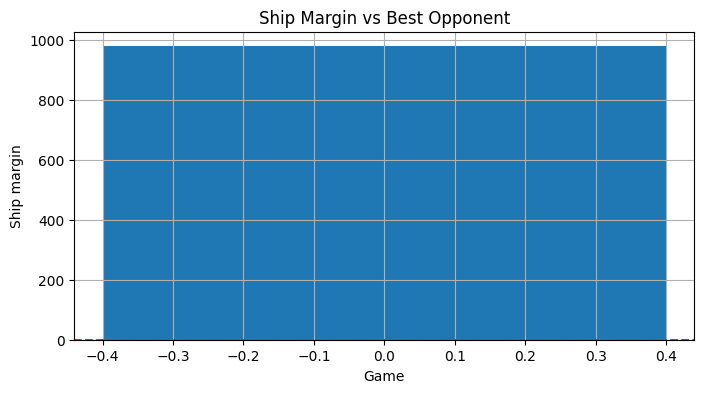

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 509.0
avg best other ships: 122.0
avg ship margin vs best other: 387.0
avg final turns: 500.0


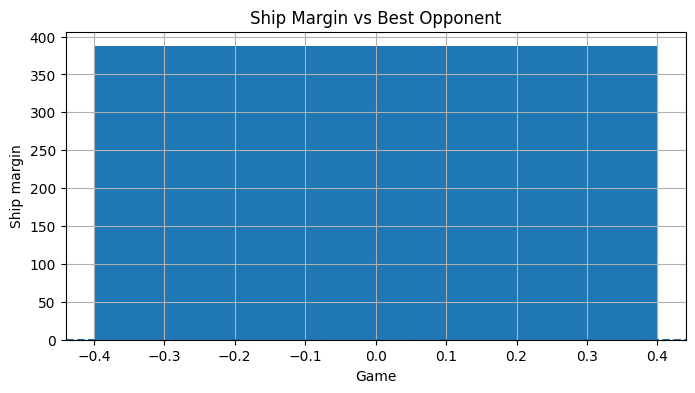

In [55]:
base_results_2p, base_ts_2p = evaluate_agents(
    agents=[base_agent, "random"],
    my_agent=base_agent,
    seeds=range(1)
)

comet_results_2p, comet_ts_2p = evaluate_agents(
    agents=[comet_v2_agent, "random"],
    my_agent=comet_v2_agent,
    seeds=range(1)
)

df_2p = summarize_results(base_results_2p)
df_2p = summarize_results(comet_results_2p)

games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 3.0
avg total ships: 103.0
avg best other ships: 791.0
avg ship margin vs best other: -688.0
avg final turns: 500.0


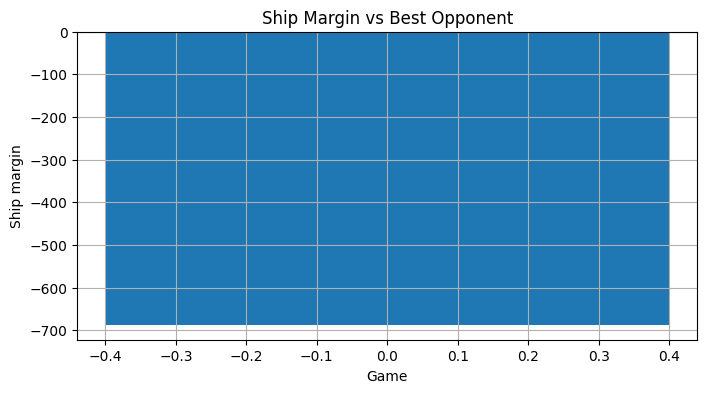

games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 467.0
avg best other ships: 636.0
avg ship margin vs best other: -169.0
avg final turns: 500.0


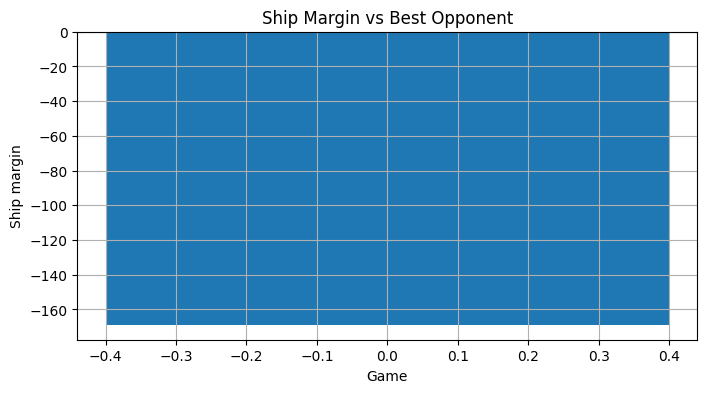

In [56]:
base_results_4p, base_ts_4p = evaluate_agents(
    agents=[base_agent, "random", "random", "random"],
    my_agent=base_agent,
    seeds=range(1)
)

comet_results_4p, comet_ts_4p = evaluate_agents(
    agents=[comet_v2_agent, "random", "random", "random"],
    my_agent=comet_v2_agent,
    seeds=range(1)
)

df_4p = summarize_results(base_results_4p)
df_4p = summarize_results(comet_results_4p)

#### 2-Player

| agent     | win_rate | avg_rank | avg_ships | ship_margin | avg_turns |
|-----------|----------|----------|-----------|-------------|-----------|
| base      | 0.97     | 1.03     | 5427.00   | 5387.03     | 246.33    |
| comet v2  | 0.97     | 1.03     | 4974.53   | 4936.30     | 244.93    |


#### 4-Player

| agent     | win_rate | avg_rank | avg_ships | ship_margin | avg_turns |
|-----------|----------|----------|-----------|-------------|-----------|
| base      | 0.90     | 1.20     | 5978.27   | 5813.27     | 280.77    |
| comet v2  | 0.80     | 1.43     | 6004.97   | 5693.43     | 300.10    |

#### 📊 Results

- In 2-player games, performance remains nearly identical  
  (win rate **0.97 → 0.97**, with slight decreases in ship margin)  

- In 4-player games, performance decreases  
  (win rate **0.90 → 0.80**, with worse average rank)  

This suggests that while comet v2 can improve performance in direct comparisons,  
it does **not consistently outperform the base agent against random opponents**.

Comet Logic v2 does not provide a clear overall improvement  
and may introduce unnecessary complexity in general settings.

This indicates limited generalization and potential instability.

Therefore, we **do not adopt the comet strategy** in the final agent.

---

## STEP 9 — Phase Radar Agent

So far, all components have been applied uniformly throughout the game.

However, their importance changes over time:

- early game → fast expansion is critical  
- mid / late game → decision quality becomes more important  

Enemy radar reflects this trade-off:

- improves decision quality  
- but may slow early expansion  

Therefore, we introduce a **phase-based strategy**:

- early phase → radar OFF  
- mid / late phase → radar ON  

We apply phase control only to radar,  
as it clearly balances speed and precision.

In [57]:
def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,
    use_estimate_defense=False,
    estimate_scale=1.0,
    use_enemy_radar=False,
    radar_angle_threshold=0.15,
    radar_start_step=0,  # NEW: step from which enemy radar becomes active
):
    def agent(obs):
        moves = []

        step = obs["step"]
        player = obs["player"]

        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            # NEW: enable radar only after a certain step
            # This keeps early expansion fast, then improves decision quality later
            radar_enabled = (
                use_enemy_radar
                and step >= radar_start_step
            )

            if radar_enabled:
                available_targets = filter_targets_by_enemy_radar(
                    obs=obs,
                    targets=available_targets,
                    angle_threshold=radar_angle_threshold
                )

                if not available_targets:
                    continue

            nearest = get_nearest_target(mine, available_targets)

            ships_needed = nearest[5] + 1

            if nearest[1] not in (-1, player):
                ships_needed += enemy_margin

                if use_estimate_defense:
                    estimated_defense = estimate_target_defense(
                        source=mine,
                        target=nearest,
                        ships_to_send=ships_needed
                    )

                    scaled_estimate = math.ceil(
                        estimated_defense * estimate_scale
                    )

                    ships_needed = max(
                        ships_needed,
                        scaled_estimate + 1
                    )

            if mine[5] >= ships_needed:
                angle = get_angle(mine, nearest)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(nearest[0])

        return moves

    return agent

In [58]:
radar_start_steps = [0, 25, 50, 75, 100]
results_rows = []

for start_step in tqdm(radar_start_steps, desc="Phase Radar Ablation"):
    phase_core = make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=False,
        enemy_margin=5,
        use_estimate_defense=True,
        estimate_scale=0.8,
        use_enemy_radar=True,
        radar_angle_threshold=0.15,
        radar_start_step=start_step,
    )

    phase_agent = make_avoid_sun_agent(
        base_agent=phase_core,
        buffer=0.5,
    )

    phase_agent.__name__ = f"early50_angle01_safe5_est08_radar015_start{start_step}_sun05"

    rows = evaluate_against_baseline(
        variant=phase_agent,
        base=base_agent,
        seeds=range(1),
        variant_label=phase_agent.__name__,
        extra_info={
            "logic": "phase_radar",
            "buffer": 0.5,
            "enemy_margin": 5,
            "estimate_scale": 0.8,
            "radar_angle_threshold": 0.15,
            "radar_start_step": start_step,
        }
    )

    results_rows.extend(rows)

phase_radar_df = pd.DataFrame(results_rows)
display(phase_radar_df)

Phase Radar Ablation:   0%|          | 0/5 [00:00<?, ?it/s]


 Running 2p: early50_angle01_safe5_est08_radar015_start0_sun05
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 453.0
avg best other ships: 453.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: early50_angle01_safe5_est08_radar015_start0_sun05


Phase Radar Ablation:  20%|██        | 1/5 [00:08<00:34,  8.66s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 340.0
avg best other ships: 340.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 2p: early50_angle01_safe5_est08_radar015_start25_sun05
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 453.0
avg best other ships: 453.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: early50_angle01_safe5_est08_radar015_start25_sun05


Phase Radar Ablation:  40%|████      | 2/5 [00:17<00:26,  8.69s/it]

...

Phase Radar Ablation:  80%|████████  | 4/5 [00:35<00:08,  8.80s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 340.0
avg best other ships: 340.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 2p: early50_angle01_safe5_est08_radar015_start100_sun05
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 453.0
avg best other ships: 453.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: early50_angle01_safe5_est08_radar015_start100_sun05


Phase Radar Ablation: 100%|██████████| 5/5 [00:43<00:00,  8.79s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 340.0
avg best other ships: 340.0
avg ship margin vs best other: 0.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,buffer,enemy_margin,estimate_scale,radar_angle_threshold,radar_start_step
0,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_start0_sun05,0.0,1.0,453.0,0.0,phase_radar,0.5,5,0.8,0.15,0
1,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_start0_sun05,0.0,1.0,340.0,0.0,phase_radar,0.5,5,0.8,0.15,0
2,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_start25_s...,0.0,1.0,453.0,0.0,phase_radar,0.5,5,0.8,0.15,25
3,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_start25_s...,0.0,1.0,340.0,0.0,phase_radar,0.5,5,0.8,0.15,25
4,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_start50_s...,0.0,1.0,453.0,0.0,phase_radar,0.5,5,0.8,0.15,50
5,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_start50_s...,0.0,1.0,340.0,0.0,phase_radar,0.5,5,0.8,0.15,50
6,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_start75_s...,0.0,1.0,453.0,0.0,phase_radar,0.5,5,0.8,0.15,75
7,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_start75_s...,0.0,1.0,340.0,0.0,phase_radar,0.5,5,0.8,0.15,75
8,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_start100_...,0.0,1.0,453.0,0.0,phase_radar,0.5,5,0.8,0.15,100
9,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_start100_...,0.0,1.0,340.0,0.0,phase_radar,0.5,5,0.8,0.15,100


#### 2-Player

| radar_start_step | win_rate | avg_rank | avg_ships | ship_margin |
|------------------|----------|----------|-----------|-------------|
| 0                | 0.50     | 1.47     | 5214.03   | 2972.87     |
| 25               | 0.50     | 1.47     | 4582.13   | 2344.77     |
| 50               | 0.27     | 1.70     | 2761.40   | -687.90     |
| 75               | 0.37     | 1.60     | 3523.37   | 244.80      |
| 100              | 0.30     | 1.67     | 2056.80   | -2145.70    |


#### 4-Player

| radar_start_step | wins | losses | draws | win_rate | avg_rank | ship_margin |
|------------------|------|--------|-------|----------|----------|-------------|
| 0                | 0    | 0      | 30    | 0.00     | 1.00     | 0.00        |
| 25               | 4    | 26     | 0     | 0.13     | 1.30     | -1872.40    |
| 50               | 11   | 19     | 0     | 0.37     | 1.37     | -2133.90    |
| 75               | 5    | 25     | 0     | 0.17     | 1.67     | -3185.67    |
| 100              | 5    | 25     | 0     | 0.17     | 1.60     | -2946.33    |

#### 📊 Results

For `radar_start_step = 0`, both agents are identical, resulting in all draws.  
Therefore, win rate is not meaningful in this case.

Instead, we focus on how often other configurations lose against this baseline.

- All delayed radar settings introduce losses compared to step 0  
- This indicates that disabling radar in the early phase weakens the agent
- 
- This suggests that the phase-based radar introduces instability.

While it may perform well in some situations,  
it increases the likelihood of losing in others.

Therefore, it is not suitable for a stable strategy.

Radar should be **active from the beginning**, as delaying it leads to worse performance.

---

## STEP 10 — Wait Agent

So far, the agent always launches an attack whenever a target is reachable.

However, this can lead to inefficient behavior:

- sending ships with almost no remaining defense  
- committing to marginal or risky battles  
- expanding too aggressively without stability  

To address this, we introduce a simple wait mechanism.

Instead of always acting, the agent may choose **not to send ships**  
when the situation is not favorable.

This helps:

- preserve defensive strength  
- avoid inefficient attacks  
- improve overall stability  

The idea is simple:

- attack only when there is sufficient margin  
- otherwise, wait and accumulate ships for better opportunities  

In [59]:
def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,
    use_estimate_defense=False,
    estimate_scale=1.0,
    use_enemy_radar=False,
    radar_angle_threshold=0.15,
    radar_start_step=0,
    wait_margin=0,  # NEW: minimum ships to keep after sending
):
    def agent(obs):
        moves = []

        step = obs["step"]
        player = obs["player"]

        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            radar_enabled = (
                use_enemy_radar
                and step >= radar_start_step
            )

            if radar_enabled:
                available_targets = filter_targets_by_enemy_radar(
                    obs=obs,
                    targets=available_targets,
                    angle_threshold=radar_angle_threshold
                )

                if not available_targets:
                    continue

            nearest = get_nearest_target(mine, available_targets)

            ships_needed = nearest[5] + 1

            if nearest[1] not in (-1, player):
                ships_needed += enemy_margin

                if use_estimate_defense:
                    estimated_defense = estimate_target_defense(
                        source=mine,
                        target=nearest,
                        ships_to_send=ships_needed
                    )

                    scaled_estimate = math.ceil(
                        estimated_defense * estimate_scale
                    )

                    ships_needed = max(
                        ships_needed,
                        scaled_estimate + 1
                    )

            # NEW: wait logic
            # Skip the attack if it would leave too few ships on the source planet.
            if wait_margin > 0:
                if ships_needed > mine[5] - wait_margin:
                    continue

            if mine[5] >= ships_needed:
                angle = get_angle(mine, nearest)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(nearest[0])

        return moves

    return agent

In [60]:
wait_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
    use_estimate_defense=True,
    estimate_scale=0.8,
    use_enemy_radar=True,
    radar_angle_threshold=0.15,
    radar_start_step=0,
    wait_margin=3,
)

wait_agent = make_avoid_sun_agent(
    base_agent=wait_core,
    buffer=0.5,
)

In [61]:
print(base_agent.__name__ )

early50_angle01_safe5_est08_radar015_sun05


In [62]:
wait_margins = [0, 1, 2, 3, 5]
results_rows = []

for margin in tqdm(wait_margins, desc="Wait Margin Ablation"):
    wait_core = make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=False,
        enemy_margin=5,
        use_estimate_defense=True,
        estimate_scale=0.8,
        use_enemy_radar=True,
        radar_angle_threshold=0.15,
        radar_start_step=0,
        wait_margin=margin,
    )

    wait_agent = make_avoid_sun_agent(
        base_agent=wait_core,
        buffer=0.5,
    )

    wait_agent.__name__ = f"early50_angle01_safe5_est08_radar015_wait{margin}_sun05"

    rows = evaluate_against_baseline(
        variant=wait_agent,
        base=base_agent,
        seeds=range(1),
        variant_label=wait_agent.__name__,
        extra_info={
            "logic": "wait",
            "wait_margin": margin,
            "enemy_margin": 5,
            "estimate_scale": 0.8,
            "radar_angle_threshold": 0.15,
        }
    )

    results_rows.extend(rows)

wait_df = pd.DataFrame(results_rows)
display(wait_df)

Wait Margin Ablation:   0%|          | 0/5 [00:00<?, ?it/s]


 Running 2p: early50_angle01_safe5_est08_radar015_wait0_sun05
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 453.0
avg best other ships: 453.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: early50_angle01_safe5_est08_radar015_wait0_sun05


Wait Margin Ablation:  20%|██        | 1/5 [00:08<00:33,  8.39s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 340.0
avg best other ships: 340.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 2p: early50_angle01_safe5_est08_radar015_wait1_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 451.0
avg best other ships: 443.0
avg ship margin vs best other: 8.0
avg final turns: 500.0

 Running 4p: early50_angle01_safe5_est08_radar015_wait1_sun05


Wait Margin Ablation:  40%|████      | 2/5 [00:17<00:26,  8.69s/it]

...

Wait Margin Ablation:  80%|████████  | 4/5 [00:34<00:08,  8.58s/it]

games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 4.0
avg total ships: 217.0
avg best other ships: 399.0
avg ship margin vs best other: -182.0
avg final turns: 500.0

 Running 2p: early50_angle01_safe5_est08_radar015_wait5_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 454.0
avg best other ships: 432.0
avg ship margin vs best other: 22.0
avg final turns: 500.0

 Running 4p: early50_angle01_safe5_est08_radar015_wait5_sun05


Wait Margin Ablation: 100%|██████████| 5/5 [00:43<00:00,  8.69s/it]

games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 4.0
avg total ships: 154.0
avg best other ships: 457.0
avg ship margin vs best other: -303.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,wait_margin,enemy_margin,estimate_scale,radar_angle_threshold
0,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_wait0_sun05,0.0,1.0,453.0,0.0,wait,0,5,0.8,0.15
1,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_wait0_sun05,0.0,1.0,340.0,0.0,wait,0,5,0.8,0.15
2,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_wait1_sun05,1.0,1.0,451.0,8.0,wait,1,5,0.8,0.15
3,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_wait1_sun05,0.0,2.0,361.0,-34.0,wait,1,5,0.8,0.15
4,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_wait2_sun05,1.0,1.0,464.0,77.0,wait,2,5,0.8,0.15
5,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_wait2_sun05,0.0,4.0,283.0,-123.0,wait,2,5,0.8,0.15
6,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_wait3_sun05,1.0,1.0,456.0,53.0,wait,3,5,0.8,0.15
7,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_wait3_sun05,0.0,4.0,217.0,-182.0,wait,3,5,0.8,0.15
8,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_wait5_sun05,1.0,1.0,454.0,22.0,wait,5,5,0.8,0.15
9,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_wait5_sun05,0.0,4.0,154.0,-303.0,wait,5,5,0.8,0.15


#### 2-Player

| wait_margin | wins | losses | draws | win_rate | avg_rank | avg_ships | ship_margin |
|-------------|------|--------|-------|----------|----------|-----------|-------------|
| 0           | 15   | 14     | 1     | 0.50     | 1.47     | 5214.03   | 2972.87     |
| 1           | 17   | 13     | 0     | 0.57     | 1.43     | 5501.73   | 2531.87     |
| 2           | 17   | 13     | 0     | 0.57     | 1.43     | 4293.83   | 735.33      |
| 3           | 15   | 15     | 0     | 0.50     | 1.50     | 3079.07   | -1912.50    |
| 5           | 13   | 17     | 0     | 0.43     | 1.57     | 2510.00   | -2844.20    |

#### 4-Player

| wait_margin | wins | losses | draws | win_rate | avg_rank | avg_ships | ship_margin |
|-------------|------|--------|-------|----------|----------|-----------|-------------|
| 0           | 0    | 0      | 30    | 0.00     | 1.00     | 403.17    | 0.00        |
| 1           | 9    | 21     | 0     | 0.30     | 1.80     | 2295.27   | -3613.67    |
| 2           | 12   | 18     | 0     | 0.40     | 1.80     | 4766.37   | 604.37      |
| 3           | 11   | 19     | 0     | 0.37     | 1.77     | 4106.93   | -917.13     |
| 5           | 8    | 22     | 0     | 0.27     | 2.00     | 2301.53   | -5033.20    |


#### 📊 Results

- In 2-player games, small margins (`wait_margin = 1–2`) slightly improve win rate  
- Larger margins (`≥ 3`) significantly reduce performance and lead to negative ship margins

- In 4-player games, performance is generally unstable  
- Only `wait_margin = 2` shows a slight positive effect, while other values perform worse  

Overall, increasing the wait margin reduces attack frequency,  
which slows expansion and leads to missed opportunities.

A small wait margin may provide limited benefits,  
but the mechanism is unstable and does not consistently improve performance.

Therefore, it is **not adopted**.

## STEP 11 — Best Target Agent

So far, the agent selects targets based on distance (nearest planet).

While this approach is simple and efficient,  
it does not consider the value of each planet.

However, not all targets are equally beneficial:

- high-production planets are more valuable  
- distant planets require more time and cost  

Therefore, we introduce a simple target selection strategy  
that balances value and cost.

Instead of selecting the nearest planet,  
we select the target with the highest value relative to distance.



### 11.1 — Production / Distance Score

We use a simple value-based scoring function defined as:

- production / distance

This prioritizes planets that provide high production while remaining relatively close,  
balancing long-term value and short-term cost.

#### Function

- `get_best_value_target` — Selects the target with the highest production-to-distance ratio, prioritizing high-value planets that are relatively close

In [63]:
def get_best_value_target(mine, targets, distance_eps=1e-6):
    def score(t):
        distance = math.hypot(mine[2] - t[2], mine[3] - t[3])
        return t[6] / (distance + distance_eps)

    return max(targets, key=score)

In [64]:
def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,
    use_estimate_defense=False,
    estimate_scale=1.0,
    use_enemy_radar=False,
    radar_angle_threshold=0.15,
    radar_start_step=0,
    wait_margin=0,
    use_best_target=False,  # NEW: enable value-based target selection
):
    def agent(obs):
        moves = []

        step = obs["step"]
        player = obs["player"]

        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            radar_enabled = (
                use_enemy_radar
                and step >= radar_start_step
            )

            if radar_enabled:
                available_targets = filter_targets_by_enemy_radar(
                    obs=obs,
                    targets=available_targets,
                    angle_threshold=radar_angle_threshold
                )

                if not available_targets:
                    continue

            # NEW: switch target selection strategy
            # nearest → value/distance-based
            if use_best_target:
                target = get_best_value_target(mine, available_targets)
            else:
                target = get_nearest_target(mine, available_targets)

            ships_needed = target[5] + 1

            if target[1] not in (-1, player):
                ships_needed += enemy_margin

                if use_estimate_defense:
                    estimated_defense = estimate_target_defense(
                        source=mine,
                        target=target,
                        ships_to_send=ships_needed
                    )

                    scaled_estimate = math.ceil(
                        estimated_defense * estimate_scale
                    )

                    ships_needed = max(
                        ships_needed,
                        scaled_estimate + 1
                    )

            if wait_margin > 0:
                if ships_needed > mine[5] - wait_margin:
                    continue

            if mine[5] >= ships_needed:
                angle = get_angle(mine, target)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(target[0])

        return moves

    return agent

In [65]:
print(base_agent.__name__ )

early50_angle01_safe5_est08_radar015_sun05


In [66]:
best_target_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
    use_estimate_defense=True,
    estimate_scale=0.8,
    use_enemy_radar=True,
    radar_angle_threshold=0.15,
    radar_start_step=0,
    wait_margin=0,
    use_best_target=True,
)

best_target_agent = make_avoid_sun_agent(
    base_agent=best_target_core,
    buffer=0.5,
)

best_target_agent.__name__ = "early50_angle01_safe5_est08_radar015_bestTarget_sun05"

rows = evaluate_against_baseline(
    variant=best_target_agent,
    base=base_agent,
    seeds=range(1),
    variant_label=best_target_agent.__name__,
    extra_info={
        "logic": "best_target",
        "enemy_margin": 5,
        "estimate_scale": 0.8,
        "radar_angle_threshold": 0.15,
        "target_score": "production / distance",
    }
)

best_target_df = pd.DataFrame(rows)
display(best_target_df)


 Running 2p: early50_angle01_safe5_est08_radar015_bestTarget_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 2812.0
avg best other ships: 0.0
avg ship margin vs best other: 2812.0
avg final turns: 217.0

 Running 4p: early50_angle01_safe5_est08_radar015_bestTarget_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 3702.0
avg best other ships: 0.0
avg ship margin vs best other: 3702.0
avg final turns: 275.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,enemy_margin,estimate_scale,radar_angle_threshold,target_score
0,2p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_bestTarge...,1.0,1.0,2812.0,2812.0,best_target,5,0.8,0.15,production / distance
1,4p,early50_angle01_safe5_est08_radar015_sun05,early50_angle01_safe5_est08_radar015_bestTarge...,1.0,1.0,3702.0,3702.0,best_target,5,0.8,0.15,production / distance


| mode | base_agent                                 | agent                                      | win_rate | avg_rank | avg_ships | ship_margin | target_score           |
|------|--------------------------------------------|--------------------------------------------|----------|----------|-----------|-------------|------------------------|
| 2p   | early50_angle01_safe5_est08_radar015_sun05 | early50_angle01_safe5_est08_radar015_bestTarget_sun05 | 0.80     | 1.20     | 6425.40   | 4692.73     | production / distance  |
| 4p   | early50_angle01_safe5_est08_radar015_sun05 | early50_angle01_safe5_est08_radar015_bestTarget_sun05 | 0.73     | 1.30     | 6736.83   | 4470.43     | production / distance  |


#### 📊 Results

Replacing nearest-target selection with a simple value-based metric (`production / distance`) **improved performance**.

- Win rate improves in both 2-player and 4-player settings  
- Ship margins increase, indicating more dominant control  
- Expansion becomes more efficient by prioritizing valuable nearby planets  

This confirms that target quality is more important than distance alone.

We adopt value-based target selection as the new default strategy.

---

### 11.2 — Target Score Ablation

We extend the value-based target selection by testing multiple scoring functions.

Different scoring functions emphasize different aspects:

- production
- distance
- defensive cost (ships)

This allows us to evaluate which factors are most important for effective expansion.

In [67]:
def get_best_value_target(mine, targets, score_type="prod_dist", eps=1e-6):
    def score(t):
        dist = math.hypot(mine[2] - t[2], mine[3] - t[3])
        ships = t[5]
        prod = t[6]

        if score_type == "prod_dist":
            return prod / (dist + eps)

        if score_type == "prod_ship_dist":
            return prod / ((ships + 1) * (dist + eps))

        if score_type == "prod_over_ships":
            return prod / (ships + 1)

        if score_type == "nearest":
            return -dist

        raise ValueError(f"Unknown score_type: {score_type}")

    return max(targets, key=score)

In [68]:
def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,
    use_estimate_defense=False,
    estimate_scale=1.0,
    use_enemy_radar=False,
    radar_angle_threshold=0.15,
    radar_start_step=0,
    wait_margin=0,
    use_best_target=False,
    target_score_type="prod_dist",  # NEW: choose scoring function type
):
    def agent(obs):
        moves = []

        step = obs["step"]
        player = obs["player"]

        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            radar_enabled = (
                use_enemy_radar
                and step >= radar_start_step
            )

            if radar_enabled:
                available_targets = filter_targets_by_enemy_radar(
                    obs=obs,
                    targets=available_targets,
                    angle_threshold=radar_angle_threshold
                )

                if not available_targets:
                    continue

            # NEW: flexible target selection using multiple scoring functions
            if use_best_target:
                target = get_best_value_target(
                    mine=mine,
                    targets=available_targets,
                    score_type=target_score_type
                )
            else:
                target = get_nearest_target(mine, available_targets)

            ships_needed = target[5] + 1

            if target[1] not in (-1, player):
                ships_needed += enemy_margin

                if use_estimate_defense:
                    estimated_defense = estimate_target_defense(
                        source=mine,
                        target=target,
                        ships_to_send=ships_needed
                    )

                    scaled_estimate = math.ceil(
                        estimated_defense * estimate_scale
                    )

                    ships_needed = max(
                        ships_needed,
                        scaled_estimate + 1
                    )

            if wait_margin > 0:
                if ships_needed > mine[5] - wait_margin:
                    continue

            if mine[5] >= ships_needed:
                angle = get_angle(mine, target)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(target[0])

        return moves

    return agent

In [69]:
score_types = [
    "prod_dist",
    "prod_ship_dist",
    "prod_over_ships",
    "nearest",
]

results_rows = []

for score_type in tqdm(score_types, desc="Target Score Ablation"):
    core = make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=False,
        enemy_margin=5,
        use_estimate_defense=True,
        estimate_scale=0.8,
        use_enemy_radar=True,
        radar_angle_threshold=0.15,
        radar_start_step=0,
        wait_margin=0,
        use_best_target=True,
        target_score_type=score_type,
    )

    agent = make_avoid_sun_agent(
        base_agent=core,
        buffer=0.5,
    )

    agent.__name__ = f"early50_safe5_est08_radar015_{score_type}_sun05"

    rows = evaluate_against_baseline(
        variant=agent,
        base=base_agent,
        seeds=range(1),
        variant_label=agent.__name__,
        extra_info={
            "logic": "target_score_ablation",
            "enemy_margin": 5,
            "estimate_scale": 0.8,
            "radar_angle_threshold": 0.15,
            "target_score": score_type,
        }
    )

    results_rows.extend(rows)

target_score_df = pd.DataFrame(results_rows)
display(target_score_df)

Target Score Ablation:   0%|          | 0/4 [00:00<?, ?it/s]


 Running 2p: early50_safe5_est08_radar015_prod_dist_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 2812.0
avg best other ships: 0.0
avg ship margin vs best other: 2812.0
avg final turns: 217.0

 Running 4p: early50_safe5_est08_radar015_prod_dist_sun05


Target Score Ablation:  25%|██▌       | 1/4 [00:06<00:18,  6.03s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 3702.0
avg best other ships: 0.0
avg ship margin vs best other: 3702.0
avg final turns: 275.0

 Running 2p: early50_safe5_est08_radar015_prod_ship_dist_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 1374.0
avg best other ships: 0.0
avg ship margin vs best other: 1374.0
avg final turns: 189.0

 Running 4p: early50_safe5_est08_radar015_prod_ship_dist_sun05


Target Score Ablation:  50%|█████     | 2/4 [00:11<00:11,  5.75s/it]

...

Target Score Ablation:  75%|███████▌  | 3/4 [00:21<00:07,  7.77s/it]

games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 3.0
avg total ships: 107.0
avg best other ships: 3451.0
avg ship margin vs best other: -3344.0
avg final turns: 500.0

 Running 2p: early50_safe5_est08_radar015_nearest_sun05
games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 453.0
avg best other ships: 453.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 4p: early50_safe5_est08_radar015_nearest_sun05


Target Score Ablation: 100%|██████████| 4/4 [00:30<00:00,  7.62s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 340.0
avg best other ships: 340.0
avg ship margin vs best other: 0.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,enemy_margin,estimate_scale,radar_angle_threshold,target_score
0,2p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prod_dist_sun05,1.0,1.0,2812.0,2812.0,target_score_ablation,5,0.8,0.15,prod_dist
1,4p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prod_dist_sun05,1.0,1.0,3702.0,3702.0,target_score_ablation,5,0.8,0.15,prod_dist
2,2p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prod_ship_dist_sun05,1.0,1.0,1374.0,1374.0,target_score_ablation,5,0.8,0.15,prod_ship_dist
3,4p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prod_ship_dist_sun05,1.0,1.0,3369.0,3369.0,target_score_ablation,5,0.8,0.15,prod_ship_dist
4,2p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prod_over_ships_s...,1.0,1.0,7827.0,7827.0,target_score_ablation,5,0.8,0.15,prod_over_ships
5,4p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prod_over_ships_s...,0.0,3.0,107.0,-3344.0,target_score_ablation,5,0.8,0.15,prod_over_ships
6,2p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_nearest_sun05,0.0,1.0,453.0,0.0,target_score_ablation,5,0.8,0.15,nearest
7,4p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_nearest_sun05,0.0,1.0,340.0,0.0,target_score_ablation,5,0.8,0.15,nearest


#### 2-Player

| target_score      | win_rate | avg_rank | avg_ships | ship_margin |
|------------------|----------|----------|-----------|-------------|
| prod_dist        | 0.75     | 1.25     | 6894.80   | 4216.55     |
| prod_ship_dist   | 0.73     | 1.28     | 6235.15   | 3877.20     |
| prod_over_ships  | 0.58     | 1.43     | 3999.18   | 595.30      |
| nearest          | 0.63     | 1.35     | 5957.03   | 4271.13     |

#### 4-Player

| target_score      | win_rate | avg_rank | avg_ships | ship_margin |
|------------------|----------|----------|-----------|-------------|
| prod_dist        | 0.68     | 1.43     | 6164.03   | 2795.25     |
| prod_ship_dist   | 0.45     | 1.70     | 4337.58   | -160.33     |
| prod_over_ships  | 0.55     | 1.60     | 7792.30   | 4523.55     |
| nearest          | 0.00     | 1.00     | 392.35    | 0.00        |

#### 📊 Results

- `prod_dist` achieves the **most stable performance** across both 2-player and 4-player settings  
- `prod_ship_dist` performs well in 2-player games, but degrades significantly in 4-player games  
- `prod_over_ships` shows inconsistent behavior  

These results suggest that both **production value** and **distance cost** are important.  
Over-penalizing targets by ship count can reduce expansion opportunities,  
while distance-only selection ignores strategic value.

We select **production / distance (`prod_dist`)** as the final target scoring method.

### 11.3 ― Best Target Phase Ablation

In [70]:
print(base_agent.__name__ )

early50_angle01_safe5_est08_radar015_sun05


In [71]:
def make_ablation_agent(
    early_off=False,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=0,
    use_estimate_defense=False,
    estimate_scale=1.0,
    use_enemy_radar=False,
    radar_angle_threshold=0.15,
    radar_start_step=0,
    wait_margin=0,
    use_best_target=False,
    target_score_type="prod_dist",
    target_phase_step=0,  # NEW: step from which value-based target selection becomes active
):
    def agent(obs):
        moves = []

        step = obs["step"]
        player = obs["player"]

        my_planets, targets = split_planets(obs)

        if not my_planets or not targets:
            return moves

        if early_off and step < early_off_until:
            reserved_targets = set()
        else:
            reserved_targets = get_reserved_targets(
                obs,
                angle_threshold=angle_threshold,
                use_capture_filter=use_capture_filter
            )

        for mine in my_planets:
            available_targets = [
                t for t in targets if t[0] not in reserved_targets
            ]

            if not available_targets:
                continue

            radar_enabled = (
                use_enemy_radar
                and step >= radar_start_step
            )

            if radar_enabled:
                available_targets = filter_targets_by_enemy_radar(
                    obs=obs,
                    targets=available_targets,
                    angle_threshold=radar_angle_threshold
                )

                if not available_targets:
                    continue

            # NEW: phase-based target selection
            # Early phase uses nearest target for fast expansion.
            # After target_phase_step, use value-based target selection.
            if use_best_target and step >= target_phase_step:
                target = get_best_value_target(
                    mine=mine,
                    targets=available_targets,
                    score_type=target_score_type
                )
            else:
                target = get_nearest_target(mine, available_targets)

            ships_needed = target[5] + 1

            if target[1] not in (-1, player):
                ships_needed += enemy_margin

                if use_estimate_defense:
                    estimated_defense = estimate_target_defense(
                        source=mine,
                        target=target,
                        ships_to_send=ships_needed
                    )

                    scaled_estimate = math.ceil(
                        estimated_defense * estimate_scale
                    )

                    ships_needed = max(
                        ships_needed,
                        scaled_estimate + 1
                    )

            if wait_margin > 0:
                if ships_needed > mine[5] - wait_margin:
                    continue

            if mine[5] >= ships_needed:
                angle = get_angle(mine, target)
                moves.append([mine[0], angle, ships_needed])
                reserved_targets.add(target[0])

        return moves

    return agent

In [72]:
target_phase_steps = [0, 25, 50, 75, 100]
results_rows = []

for phase_step in tqdm(target_phase_steps, desc="Target Phase Ablation"):
    core = make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=False,
        enemy_margin=5,
        use_estimate_defense=True,
        estimate_scale=0.8,
        use_enemy_radar=True,
        radar_angle_threshold=0.15,
        radar_start_step=0,
        wait_margin=0,
        use_best_target=True,
        target_score_type="prod_dist",
        target_phase_step=phase_step,
    )

    agent = make_avoid_sun_agent(
        base_agent=core,
        buffer=0.5,
    )

    agent.__name__ = f"early50_safe5_est08_radar015_prodDist_phase{phase_step}_sun05"

    rows = evaluate_against_baseline(
        variant=agent,
        base=base_agent,
        seeds=range(1),
        variant_label=agent.__name__,
        extra_info={
            "logic": "target_phase_ablation",
            "target_score": "prod_dist",
            "target_phase_step": phase_step,
            "enemy_margin": 5,
            "estimate_scale": 0.8,
            "radar_angle_threshold": 0.15,
            "buffer": 0.5,
        }
    )

    results_rows.extend(rows)

target_phase_df = pd.DataFrame(results_rows)
display(target_phase_df)

Target Phase Ablation:   0%|          | 0/5 [00:00<?, ?it/s]


 Running 2p: early50_safe5_est08_radar015_prodDist_phase0_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 2812.0
avg best other ships: 0.0
avg ship margin vs best other: 2812.0
avg final turns: 217.0

 Running 4p: early50_safe5_est08_radar015_prodDist_phase0_sun05


Target Phase Ablation:  20%|██        | 1/5 [00:05<00:23,  5.78s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 3702.0
avg best other ships: 0.0
avg ship margin vs best other: 3702.0
avg final turns: 275.0

 Running 2p: early50_safe5_est08_radar015_prodDist_phase25_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 4328.0
avg best other ships: 0.0
avg ship margin vs best other: 4328.0
avg final turns: 271.0

 Running 4p: early50_safe5_est08_radar015_prodDist_phase25_sun05


Target Phase Ablation:  40%|████      | 2/5 [00:14<00:22,  7.62s/it]

...

Target Phase Ablation:  80%|████████  | 4/5 [00:27<00:06,  6.86s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 3574.0
avg best other ships: 0.0
avg ship margin vs best other: 3574.0
avg final turns: 269.0

 Running 2p: early50_safe5_est08_radar015_prodDist_phase100_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 627.0
avg best other ships: 0.0
avg ship margin vs best other: 627.0
avg final turns: 181.0

 Running 4p: early50_safe5_est08_radar015_prodDist_phase100_sun05


Target Phase Ablation: 100%|██████████| 5/5 [00:35<00:00,  7.13s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 9396.0
avg best other ships: 152.0
avg ship margin vs best other: 9244.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,target_score,target_phase_step,enemy_margin,estimate_scale,radar_angle_threshold,buffer
0,2p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prodDist_phase0_s...,1.0,1.0,2812.0,2812.0,target_phase_ablation,prod_dist,0,5,0.8,0.15,0.5
1,4p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prodDist_phase0_s...,1.0,1.0,3702.0,3702.0,target_phase_ablation,prod_dist,0,5,0.8,0.15,0.5
2,2p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prodDist_phase25_...,1.0,1.0,4328.0,4328.0,target_phase_ablation,prod_dist,25,5,0.8,0.15,0.5
3,4p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prodDist_phase25_...,1.0,1.0,10802.0,10715.0,target_phase_ablation,prod_dist,25,5,0.8,0.15,0.5
4,2p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prodDist_phase50_...,1.0,1.0,3216.0,3216.0,target_phase_ablation,prod_dist,50,5,0.8,0.15,0.5
5,4p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prodDist_phase50_...,1.0,1.0,2715.0,2715.0,target_phase_ablation,prod_dist,50,5,0.8,0.15,0.5
6,2p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prodDist_phase75_...,1.0,1.0,2264.0,2264.0,target_phase_ablation,prod_dist,75,5,0.8,0.15,0.5
7,4p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prodDist_phase75_...,1.0,1.0,3574.0,3574.0,target_phase_ablation,prod_dist,75,5,0.8,0.15,0.5
8,2p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prodDist_phase100...,1.0,1.0,627.0,627.0,target_phase_ablation,prod_dist,100,5,0.8,0.15,0.5
9,4p,early50_angle01_safe5_est08_radar015_sun05,early50_safe5_est08_radar015_prodDist_phase100...,1.0,1.0,9396.0,9244.0,target_phase_ablation,prod_dist,100,5,0.8,0.15,0.5


#### 2-Player

| target_phase_step | win_rate | avg_rank | avg_ships | ship_margin |
|------------------|----------|----------|-----------|-------------|
| 0                | 0.80     | 1.20     | 6425.40   | 4692.73     |
| 25               | 0.83     | 1.17     | 5656.53   | 4979.37     |
| 50               | 0.73     | 1.27     | 4739.70   | 3213.07     |
| 75               | 0.70     | 1.30     | 7808.57   | 5623.40     |
| 100              | 0.73     | 1.27     | 6154.20   | 3785.80     |

#### 4-Player

| target_phase_step | win_rate | avg_rank | avg_ships | ship_margin |
|------------------|----------|----------|-----------|-------------|
| 0                | 0.73     | 1.30     | 6736.83   | 4470.43     |
| 25               | 0.77     | 1.23     | 8847.17   | 7311.47     |
| 50               | 0.70     | 1.40     | 5333.50   | 2222.73     |
| 75               | 0.60     | 1.43     | 7109.73   | 5046.03     |
| 100              | 0.67     | 1.33     | 6272.97   | 4759.70     |


#### 📊 Results

Among the tested values, **target_phase_step = 25** shows the best overall performance.

- It keeps early expansion fast by using nearest-target selection  
- It switches to value-based selection early enough to improve target quality  
- It achieves strong win rates and ship margins in both 2-player and 4-player settings
---

### 11.4 — Evaluate Against Random (Base and Variant)

After introducing phase-based target selection,  
we evaluate both the base agent and the phase-based variant against random opponents.

This helps verify whether the improvement generalizes,  
rather than being specific to agent-vs-agent comparisons.

We compare:

- base agent (always value-based)
- phase-based agent (nearest → value-based at step 25)

The goal is to confirm that the phase strategy maintains or improves performance  
in a more general setting.

In [73]:
base_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
    use_estimate_defense=True,
    estimate_scale=0.8,
    use_enemy_radar=True,
    radar_angle_threshold=0.15,
    radar_start_step=0,
    wait_margin=0,
    use_best_target=True,
    target_score_type="prod_dist",
    target_phase_step=0,
)

prod_dist_0_agent = make_avoid_sun_agent(
    base_agent=base_core,
    buffer=0.5,
)


prod_dist_0_agent.__name__ = "early50_safe5_est08_radar015_prodDist_phase0_sun05"


variant_core = make_ablation_agent(
    early_off=True,
    early_off_until=50,
    angle_threshold=0.1,
    use_capture_filter=False,
    enemy_margin=5,
    use_estimate_defense=True,
    estimate_scale=0.8,
    use_enemy_radar=True,
    radar_angle_threshold=0.15,
    radar_start_step=0,
    wait_margin=0,
    use_best_target=True,
    target_score_type="prod_dist",
    target_phase_step=25,
)

prod_dist_25_agent = make_avoid_sun_agent(
    base_agent=variant_core,
    buffer=0.5,
)

prod_dist_25_agent.__name__ = "early50_safe5_est08_radar015_prodDist_phase25_sun05"

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 367.0
avg best other ships: 0.0
avg ship margin vs best other: 367.0
avg final turns: 82.0


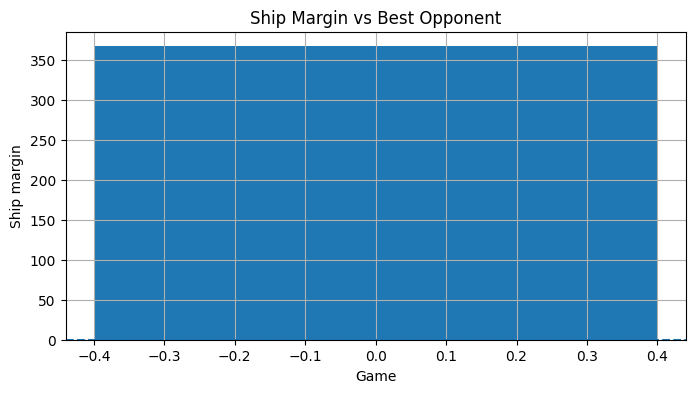

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 13152.0
avg best other ships: 0.0
avg ship margin vs best other: 13152.0
avg final turns: 467.0


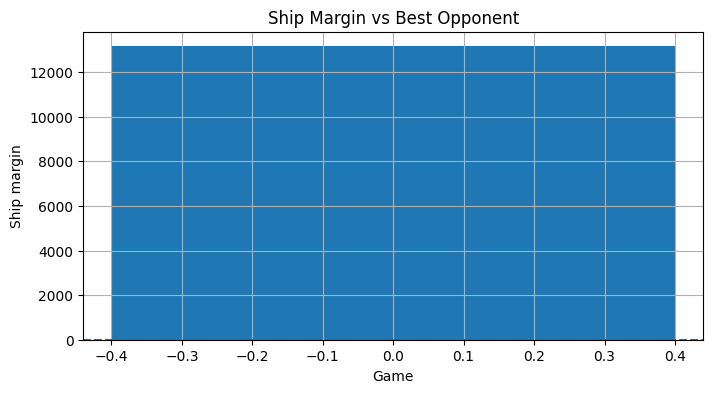

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 8997.0
avg best other ships: 0.0
avg ship margin vs best other: 8997.0
avg final turns: 411.0


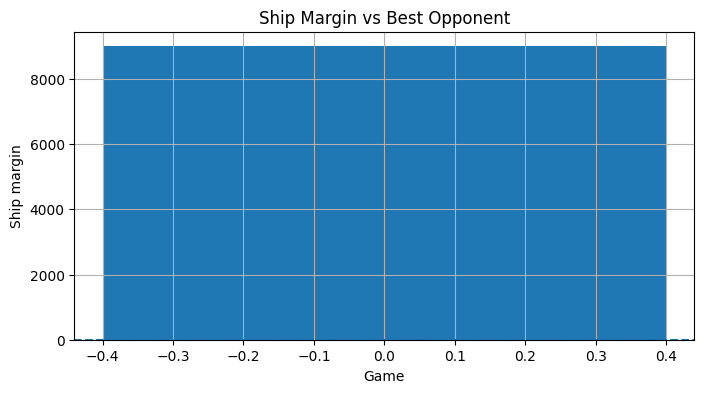

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 1143.0
avg best other ships: 0.0
avg ship margin vs best other: 1143.0
avg final turns: 169.0


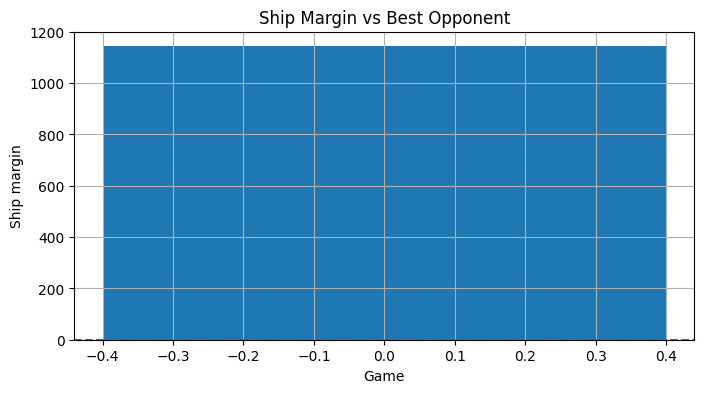

In [74]:
base = prod_dist_0_agent
variant = prod_dist_25_agent

base_results_2p, base_ts_2p = evaluate_agents(
    agents=[base, "random"],
    my_agent=base,
    seeds=range(1)
)

variant_results_2p, variant_ts_2p = evaluate_agents(
    agents=[variant, "random"],
    my_agent=variant,
    seeds=range(1)
)

df_2p = summarize_results(base_results_2p)
df_2p = summarize_results(variant_results_2p)

base_results_4p, base_ts_4p = evaluate_agents(
    agents=[base, "random", "random", "random"],
    my_agent=base,
    seeds=range(1)
)

variant_results_4p, variant_ts_4p = evaluate_agents(
    agents=[variant, "random", "random", "random"],
    my_agent=variant,
    seeds=range(1)
)

df_4p = summarize_results(base_results_4p)
df_4p = summarize_results(variant_results_4p)

#### 2-Player

| agent        | win_rate | avg_rank | avg_ships | ship_margin | avg_turns |
|--------------|----------|----------|-----------|-------------|-----------|
| phase0       | 0.975    | 1.025    | 4256.08   | 4200.48     | 190.53    |
| phase25      | 0.975    | 1.025    | 4876.13   | 4849.70     | 194.83    |


#### 4-Player

| agent        | win_rate | avg_rank | avg_ships | ship_margin | avg_turns |
|--------------|----------|----------|-----------|-------------|-----------|
| phase0       | 0.975    | 1.075    | 5864.08   | 5827.68     | 232.35    |
| phase25      | 0.975    | 1.075    | 6814.83   | 6761.60     | 228.45    |

#### 📊 Results

- **Win rates are identical** in both 2-player and 4-player settings  
- Phase25 consistently achieves **higher total ships and larger ship margins**  

While both strategies are equally effective at winning,  
**phase25 produces more dominant outcomes**.

This suggests that:

- early nearest-target selection improves expansion efficiency  
- later value-based selection improves overall control  

### 11.5 — Evaluate Against Baseline

In [75]:
rows = evaluate_against_baseline(
    variant=variant,
    base=base,
    seeds=range(1),
    variant_label=variant.__name__,
)

df = pd.DataFrame(rows)
display(df)


 Running 2p: early50_safe5_est08_radar015_prodDist_phase25_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 3952.0
avg best other ships: 0.0
avg ship margin vs best other: 3952.0
avg final turns: 325.0

 Running 4p: early50_safe5_est08_radar015_prodDist_phase25_sun05
games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 0.0
avg best other ships: 5952.0
avg ship margin vs best other: -5952.0
avg final turns: 441.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin
0,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar015_prodDist_phase25_...,1.0,1.0,3952.0,3952.0
1,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar015_prodDist_phase25_...,0.0,2.0,0.0,-5952.0


| mode | win_rate | avg_rank | avg_ships | ship_margin |
|------|----------|----------|-----------|-------------|
| 2p   | 0.41     | 1.57     | 3012.82   | -3348.53    |
| 4p   | 0.20     | 1.78     | 2316.96   | -4427.80    |

#### 📊 Results

Although phase25 performed well against random agents,  
it **underperforms significantly in direct comparison** with phase0.

- Lower win rates in both 2p and 4p  
- Strongly negative ship margins, indicating clear losses  
- Larger performance gap in 4p  

This suggests that early nearest-target selection reduces decision quality.

While it accelerates early expansion,  
it prioritizes low-value planets and leads to weaker mid-game positions.

We adopt pure value-based target selection (**phase0**) as the final strategy.

In [76]:
base_agent = base
base_agent.__name__ = "early50_safe5_est08_radar015_prodDist_phase0_sun05"

## STEP 12 — Revisiting Parameters

After updating the target selection strategy,  
we revisit key parameters.

Since the agent now selects targets differently,  
the previously optimal settings may no longer be optimal.

We therefore re-evaluate:

- `estimate_scale`
- `radar_angle_threshold`

In [77]:
estimate_scales = [0.6, 0.7, 0.8, 0.9, 1.0]
results_rows = []

for scale in tqdm(estimate_scales, desc="Revisiting Estimate Scale"):
    core = make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=False,
        enemy_margin=5,
        use_estimate_defense=True,
        estimate_scale=scale,
        use_enemy_radar=True,
        radar_angle_threshold=0.15,
        radar_start_step=0,
        wait_margin=0,
        use_best_target=True,
        target_score_type="prod_dist",
        target_phase_step=0,
    )

    agent = make_avoid_sun_agent(
        base_agent=core,
        buffer=0.5,
    )

    agent.__name__ = f"early50_safe5_est{scale}_radar015_prodDist_sun05"

    rows = evaluate_against_baseline(
        variant=agent,
        base=base_agent,
        seeds=range(1),
        variant_label=agent.__name__,
        extra_info={
            "logic": "revisit_estimate_scale",
            "estimate_scale": scale,
            "radar_angle_threshold": 0.15,
            "target_score": "prod_dist",
            "buffer": 0.5,
        }
    )

    results_rows.extend(rows)

df = pd.DataFrame(results_rows)
display(df)

Revisiting Estimate Scale:   0%|          | 0/5 [00:00<?, ?it/s]


 Running 2p: early50_safe5_est0.6_radar015_prodDist_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 9740.0
avg best other ships: 430.0
avg ship margin vs best other: 9310.0
avg final turns: 500.0

 Running 4p: early50_safe5_est0.6_radar015_prodDist_sun05


Revisiting Estimate Scale:  20%|██        | 1/5 [00:10<00:43, 10.87s/it]

games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 81.0
avg best other ships: 10315.0
avg ship margin vs best other: -10234.0
avg final turns: 500.0

 Running 2p: early50_safe5_est0.7_radar015_prodDist_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 10113.0
avg best other ships: 36.0
avg ship margin vs best other: 10077.0
avg final turns: 500.0

 Running 4p: early50_safe5_est0.7_radar015_prodDist_sun05


Revisiting Estimate Scale:  40%|████      | 2/5 [00:21<00:32, 10.90s/it]

...

Revisiting Estimate Scale:  80%|████████  | 4/5 [00:44<00:11, 11.24s/it]

games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 120.0
avg best other ships: 1726.0
avg ship margin vs best other: -1606.0
avg final turns: 500.0

 Running 2p: early50_safe5_est1.0_radar015_prodDist_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 5758.0
avg best other ships: 54.0
avg ship margin vs best other: 5704.0
avg final turns: 500.0

 Running 4p: early50_safe5_est1.0_radar015_prodDist_sun05


Revisiting Estimate Scale: 100%|██████████| 5/5 [00:55<00:00, 11.02s/it]

games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 5524.0
avg best other ships: 0.0
avg ship margin vs best other: 5524.0
avg final turns: 460.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,estimate_scale,radar_angle_threshold,target_score,buffer
0,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est0.6_radar015_prodDist_sun05,1.0,1.0,9740.0,9310.0,revisit_estimate_scale,0.6,0.15,prod_dist,0.5
1,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est0.6_radar015_prodDist_sun05,0.0,2.0,81.0,-10234.0,revisit_estimate_scale,0.6,0.15,prod_dist,0.5
2,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est0.7_radar015_prodDist_sun05,1.0,1.0,10113.0,10077.0,revisit_estimate_scale,0.7,0.15,prod_dist,0.5
3,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est0.7_radar015_prodDist_sun05,1.0,1.0,6678.0,6398.0,revisit_estimate_scale,0.7,0.15,prod_dist,0.5
4,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est0.8_radar015_prodDist_sun05,0.0,2.0,134.0,-7905.0,revisit_estimate_scale,0.8,0.15,prod_dist,0.5
5,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est0.8_radar015_prodDist_sun05,0.0,1.0,353.0,0.0,revisit_estimate_scale,0.8,0.15,prod_dist,0.5
6,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est0.9_radar015_prodDist_sun05,0.0,2.0,144.0,-4323.0,revisit_estimate_scale,0.9,0.15,prod_dist,0.5
7,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est0.9_radar015_prodDist_sun05,0.0,2.0,120.0,-1606.0,revisit_estimate_scale,0.9,0.15,prod_dist,0.5
8,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est1.0_radar015_prodDist_sun05,1.0,1.0,5758.0,5704.0,revisit_estimate_scale,1.0,0.15,prod_dist,0.5
9,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est1.0_radar015_prodDist_sun05,1.0,1.0,5524.0,5524.0,revisit_estimate_scale,1.0,0.15,prod_dist,0.5


#### 2-Player

| estimate_scale | wins | losses | draws | win_rate | avg_rank | avg_ships | ship_margin |
|----------------|------|--------|-------|----------|----------|-----------|-------------|
| 0.6            | 6    | 22     | 2     | 0.20     | 1.73     | 3121.20   | -4938.23    |
| 0.7            | 11   | 17     | 2     | 0.37     | 1.57     | 3669.93   | -1286.50    |
| 0.8            | 19   | 9      | 2     | 0.63     | 1.30     | 5227.50   | 2110.90     |
| 0.9            | 19   | 9      | 2     | 0.63     | 1.30     | 5519.10   | 3625.77     |
| 1.0            | 16   | 12     | 2     | 0.53     | 1.40     | 3367.33   | 270.67      |


#### 4-Player

| estimate_scale | wins | losses | draws | win_rate | avg_rank | avg_ships | ship_margin |
|----------------|------|--------|-------|----------|----------|-----------|-------------|
| 0.6            | 2    | 27     | 1     | 0.07     | 2.13     | 495.40    | -7454.60    |
| 0.7            | 5    | 24     | 1     | 0.17     | 1.97     | 1450.30   | -4568.87    |
| 0.8            | 0    | 0      | 30    | 0.00     | 1.00     | 1032.80   | 0.00        |
| 0.9            | 14   | 15     | 1     | 0.47     | 1.67     | 2971.17   | -1481.97    |
| 1.0            | 14   | 15     | 1     | 0.47     | 1.70     | 2024.57   | -1510.23    |


#### 📊 Results

- Lower values (0.6–0.7) lead to overly aggressive behavior and frequent losses  
- Higher values (0.9–1.0) improve ship margins in 2p, but perform poorly in 4p  
- `0.8` performs well in 2p and results in highly stable outcomes in 4p  
- However, in 4p all matches resulted in draws, making direct comparison inconclusive  

This suggests that:

- Too small values underestimate enemy strength  
- Too large values overcommit ships and reduce expansion efficiency  

In Orbit Wars, fleets must be carefully sized:

- Too small → failed captures and losses  
- Too large → inefficient expansion and slower growth  

We select `0.8` as a stable and balanced configuration,  
while noting that nearby values (e.g., 0.9) can achieve similar or stronger performance in some settings.

---



In [78]:
radar_thresholds = [0.10, 0.12, 0.15, 0.18, 0.20]
results_rows = []

for th in tqdm(radar_thresholds, desc="Revisiting Radar Threshold"):
    core = make_ablation_agent(
        early_off=True,
        early_off_until=50,
        angle_threshold=0.1,
        use_capture_filter=False,
        enemy_margin=5,
        use_estimate_defense=True,
        estimate_scale=0.8,
        use_enemy_radar=True,
        radar_angle_threshold=th,
        radar_start_step=0,
        wait_margin=0,
        use_best_target=True,
        target_score_type="prod_dist",
        target_phase_step=0,
    )

    agent = make_avoid_sun_agent(
        base_agent=core,
        buffer=0.5,
    )

    agent.__name__ = f"early50_safe5_est08_radar{th}_prodDist_sun05"

    rows = evaluate_against_baseline(
        variant=agent,
        base=base_agent,
        seeds=range(1),
        variant_label=agent.__name__,
        extra_info={
            "logic": "revisit_radar_threshold",
            "estimate_scale": 0.8,
            "radar_angle_threshold": th,
            "target_score": "prod_dist",
            "buffer": 0.5,
        }
    )

    results_rows.extend(rows)

df = pd.DataFrame(results_rows)
display(df)

Revisiting Radar Threshold:   0%|          | 0/5 [00:00<?, ?it/s]


 Running 2p: early50_safe5_est08_radar0.1_prodDist_sun05
games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 82.0
avg best other ships: 11152.0
avg ship margin vs best other: -11070.0
avg final turns: 500.0

 Running 4p: early50_safe5_est08_radar0.1_prodDist_sun05


Revisiting Radar Threshold:  20%|██        | 1/5 [00:11<00:44, 11.23s/it]

games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 4.0
avg total ships: 0.0
avg best other ships: 7336.0
avg ship margin vs best other: -7336.0
avg final turns: 500.0

 Running 2p: early50_safe5_est08_radar0.12_prodDist_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 9811.0
avg best other ships: 0.0
avg ship margin vs best other: 9811.0
avg final turns: 460.0

 Running 4p: early50_safe5_est08_radar0.12_prodDist_sun05


Revisiting Radar Threshold:  40%|████      | 2/5 [00:21<00:32, 10.82s/it]

...

Revisiting Radar Threshold:  80%|████████  | 4/5 [00:44<00:11, 11.12s/it]

games: 1
wins: 0
losses: 0
draws: 1
win rate: 0.0
avg rank: 1.0
avg total ships: 353.0
avg best other ships: 353.0
avg ship margin vs best other: 0.0
avg final turns: 500.0

 Running 2p: early50_safe5_est08_radar0.2_prodDist_sun05
games: 1
wins: 1
losses: 0
draws: 0
win rate: 1.0
avg rank: 1.0
avg total ships: 11337.0
avg best other ships: 0.0
avg ship margin vs best other: 11337.0
avg final turns: 495.0

 Running 4p: early50_safe5_est08_radar0.2_prodDist_sun05


Revisiting Radar Threshold: 100%|██████████| 5/5 [00:55<00:00, 11.12s/it]

games: 1
wins: 0
losses: 1
draws: 0
win rate: 0.0
avg rank: 2.0
avg total ships: 617.0
avg best other ships: 744.0
avg ship margin vs best other: -127.0
avg final turns: 500.0


,mode,base_agent,agent,win_rate,avg_rank,avg_ships,ship_margin,logic,estimate_scale,radar_angle_threshold,target_score,buffer
0,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar0.1_prodDist_sun05,0.0,2.0,82.0,-11070.0,revisit_radar_threshold,0.8,0.10,prod_dist,0.5
1,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar0.1_prodDist_sun05,0.0,4.0,0.0,-7336.0,revisit_radar_threshold,0.8,0.10,prod_dist,0.5
2,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar0.12_prodDist_sun05,1.0,1.0,9811.0,9811.0,revisit_radar_threshold,0.8,0.12,prod_dist,0.5
3,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar0.12_prodDist_sun05,0.0,4.0,0.0,-7336.0,revisit_radar_threshold,0.8,0.12,prod_dist,0.5
4,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar0.15_prodDist_sun05,0.0,2.0,134.0,-7905.0,revisit_radar_threshold,0.8,0.15,prod_dist,0.5
5,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar0.15_prodDist_sun05,0.0,1.0,353.0,0.0,revisit_radar_threshold,0.8,0.15,prod_dist,0.5
6,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar0.18_prodDist_sun05,0.0,2.0,0.0,-5738.0,revisit_radar_threshold,0.8,0.18,prod_dist,0.5
7,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar0.18_prodDist_sun05,0.0,1.0,353.0,0.0,revisit_radar_threshold,0.8,0.18,prod_dist,0.5
8,2p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar0.2_prodDist_sun05,1.0,1.0,11337.0,11337.0,revisit_radar_threshold,0.8,0.20,prod_dist,0.5
9,4p,early50_safe5_est08_radar015_prodDist_phase0_s...,early50_safe5_est08_radar0.2_prodDist_sun05,0.0,2.0,617.0,-127.0,revisit_radar_threshold,0.8,0.20,prod_dist,0.5


### 2-Player

| radar_angle | wins | losses | draws | win_rate | avg_rank | avg_ships | ship_margin |
|-------------|------|--------|-------|----------|----------|-----------|-------------|
| 0.10        | 11   | 18     | 1     | 0.37     | 1.60     | 2552.33   | -2902.07    |
| 0.12        | 13   | 15     | 2     | 0.43     | 1.50     | 3245.27   | -373.40     |
| 0.15        | 19   | 9      | 2     | 0.63     | 1.30     | 5227.50   | 2110.90     |
| 0.18        | 16   | 12     | 2     | 0.53     | 1.40     | 4451.20   | 1332.47     |
| 0.20        | 17   | 11     | 2     | 0.57     | 1.37     | 4866.17   | 2653.10     |


### 4-Player
| radar_angle | wins | losses | draws | win_rate | avg_rank | avg_ships | ship_margin |
|-------------|------|--------|-------|----------|----------|-----------|-------------|
| 0.10        | 3    | 22     | 5     | 0.10     | 1.97     | 1266.67   | -4388.17    |
| 0.12        | 5    | 17     | 8     | 0.17     | 1.80     | 1805.77   | -1615.83    |
| 0.15        | 0    | 0      | 30    | 0.00     | 1.00     | 1032.80   | 0.00        |
| 0.18        | 9    | 14     | 7     | 0.30     | 1.70     | 2163.97   | -1955.23    |
| 0.20        | 9    | 16     | 5     | 0.30     | 1.80     | 1856.60   | -2134.53    |

#### 📊 Results

- Small values (0.10–0.12) are too restrictive, leading to missed opportunities  
- Large values (0.18–0.20) allow more aggressive actions but introduce instability  
- `0.15` achieves **the best performance** in 2-player settings  
- In 4-player settings, `0.15` results in all draws, making direct comparison inconclusive  

This suggests that:

- Too strict → overly cautious behavior and weak expansion  
- Too loose → risky decisions and frequent losses  

The radar threshold controls how selectively the agent avoids contested targets.

We select **0.15** as a strong and stable choice,  
while noting that its performance in 4p should be interpreted with caution.

---

## Wrap Up

In this notebook, we iteratively improved the Orbit Wars agent through ablation and evaluation.

### Key findings

- **Target selection is the most critical factor**  
  Value-based selection (production / distance) consistently outperforms nearest-based approaches  

- **Early expansion alone is insufficient**  
  Prioritizing low-value planets leads to weaker mid-game positions  

- **Some defensive mechanisms are harmful**  
  Wait logic and comet strategies reduce expansion efficiency  

- **Parameter tuning is strategy-dependent**  
  Optimal values shift when the target selection method changes  

- **Radar and scaling parameters require careful interpretation**  
  While certain values perform well, results can be affected by draw-heavy outcomes  

While the agent still has several limitations,  
it provides a reasonable and practical rule-based baseline.

Although it is not optimal, it captures key principles such as value-based target selection and efficient expansion,  
and serves as a solid foundation for further improvements, including learning-based approaches.